In [2]:
#!/usr/bin/env python
"""
OH radical (7e,NORB)/cc-pVDZ PES scan — STATE-RESOLVED AMPLITUDE VERSION

Stores α/β marginals for EACH target state (D0, D1, D2, Q1) for:
  - Reference (FCI)
  - Ext-SQD
  - CIPSI

States: D0, D1, D2, Q1 (3 doublets + 1 quartet)

New wf_amps structure:
    wf_amps[state_label] = {
        "ref_a": [n_alpha floats],   # α-string marginals on full space
        "ref_b": [n_beta floats],    # β-string marginals
        "ext_a": [n_alpha floats],   # (0-padded where subspace missing)
        "ext_b": [n_beta floats],
        "cipsi_a": [n_alpha floats],
        "cipsi_b": [n_beta floats],
    }
    wf_amps_meta = {
        "n_alpha_full": int,
        "n_beta_full": int,
        "states_stored": [...],
    }
"""

# %% Cell 1: Imports
import os, time, json, numpy as np

from pyscf import gto, scf, cc, mcscf, ao2mo, fci, lib
from pyscf.fci import selected_ci, cistring
from qiskit.circuit import QuantumCircuit
from qiskit_addon_sqd.fermion import (
    enlarge_batch_from_transitions,
    bitstring_matrix_to_ci_strs,
    recover_configurations,
    subsample,
    postselect_by_hamming_right_and_left,
    solve_fermion,
)
import ffsim
import warnings
warnings.filterwarnings("ignore")

# ====== MULTICORE SETTING ======
N_THREADS = int(os.environ.get("OMP_NUM_THREADS", 24))
lib.num_threads(N_THREADS)
print(f"PySCF threads: {N_THREADS}")
# ================================

# %% Cell 2: Core functions

NORB = 18
NELEC = (4, 3)  # open-shell doublet
NCORE = 1

TARGET_STATES = ["D0", "D1", "D2", "Q1"]
MAX_DOUBLET = 3
MAX_QUARTET = 1

def safe_array(x):
    return np.nan_to_num(np.asarray(x, float))


def det_strings(norb, nelec):
    na, nb = nelec
    return (np.array(cistring.make_strings(range(norb), na), np.int64),
            np.array(cistring.make_strings(range(norb), nb), np.int64))

def reverse_bits(s, norb):
    """Reverse bit order within norb bits (fix BSM↔cistring convention)."""
    result = 0
    for i in range(norb):
        if (s >> i) & 1:
            result |= (1 << (norb - 1 - i))
    return result

def fix_ci_strs(strs, norb):
    """Fix CI strings from bitstring_matrix_to_ci_strs to match PySCF convention."""
    return np.array(sorted(set(reverse_bits(int(s), norb) for s in strs)), dtype=np.int64)

def classify_spin(s2):
    if abs(s2 - 0.75) < 0.4: return "doublet"
    if abs(s2 - 3.75) < 0.5: return "quartet"
    return "other"

def kernel_safe(myci, h1, eri, norb, nelec, ci_strs, nroots, loose=False):
    try:
        if loose:
            myci.conv_tol = GROW_CONV_TOL; myci.max_cycle = GROW_MAX_CYCLE
        else:
            myci.conv_tol = 1e-10; myci.max_cycle = 200
        e, c = selected_ci.kernel_fixed_space(
            myci, h1, eri, norb, nelec, ci_strs=ci_strs, nroots=nroots)
        if np.isscalar(e): return [float(e)], [c]
        return [float(x) for x in e], list(c)
    except:
        return [], []

def get_alpha_coeffs(c_full, strsa, basis, ci_strs):
    c = np.asarray(c_full)
    coeffs = np.zeros(len(basis))
    if c.ndim == 2:
        sm = {int(s): i for i, s in enumerate(ci_strs[0])}
        for bi, bs in enumerate(basis):
            ia = sm.get(int(bs))
            if ia is not None and ia < c.shape[0]:
                coeffs[bi] = np.max(np.abs(c[ia, :]))
    return coeffs

def get_beta_coeffs(c_full, strsb, basis_b, ci_strs):
    c = np.asarray(c_full)
    coeffs = np.zeros(len(basis_b))
    if c.ndim == 2:
        sm = {int(s): i for i, s in enumerate(ci_strs[1])}
        for bi, bs in enumerate(basis_b):
            ib = sm.get(int(bs))
            if ib is not None and ib < c.shape[1]:
                coeffs[bi] = np.max(np.abs(c[:, ib]))
    return coeffs

def _compute_diag(s, norb, h1, eri):
    """Diagonal Hamiltonian matrix element H_II for config s (Slater-Condon)."""
    occ = [i for i in range(norb) if (s >> i) & 1]
    e = 0.0
    for i in occ:
        e += h1[i, i]
    for ii, i in enumerate(occ):
        for j in occ[ii+1:]:
            e += eri[i, i, j, j] - eri[i, j, j, i]
    return e


def cipsi_extend(basis, ci_coeffs, norb, ne, acut, maxd, h1, eri, eps,
              use_coeffs=True, broad_frac=0.01, en_mode=False, e0=0.0):
    """Heat-bath extension with Epstein-Nesbet perturbative selection."""
    bs = set(int(x) for x in basis)

    if use_coeffs:
        if isinstance(ci_coeffs, list):
            # multi-root: use first root for imp selection fallback
            imp_ref = np.abs(ci_coeffs[0]) >= acut
            if imp_ref.sum() < 5:
                imp_ref[np.argsort(-np.abs(ci_coeffs[0]))[:5]] = True
        else:
            imp = np.abs(ci_coeffs) >= acut
            if imp.sum() < 5:
                imp[np.argsort(-np.abs(ci_coeffs))[:5]] = True
    else:
        cmax = np.max(np.abs(ci_coeffs)) if len(ci_coeffs) > 0 else 0
        threshold = cmax * broad_frac
        imp = np.abs(ci_coeffs) >= threshold
        if imp.sum() < 5:
            imp[np.argsort(-np.abs(ci_coeffs))[:min(5, len(basis))]] = True

    # === BROAD MODE ===
    if not use_coeffs:
        imp_idx = np.where(imp)[0]
        cands = set()
        for k in imp_idx:
            s = int(basis[k])
            occ = [i for i in range(norb) if (s >> i) & 1]
            vir = [i for i in range(norb) if not ((s >> i) & 1)]
            for i in occ:
                for a in vir:
                    ns = s ^ (1 << i) ^ (1 << a)
                    if ns not in bs: cands.add(ns)
            for ii, i in enumerate(occ):
                for j in occ[ii+1:]:
                    for aa, a in enumerate(vir):
                        for b in vir[aa+1:]:
                            ns = s ^ (1<<i) ^ (1<<j) ^ (1<<a) ^ (1<<b)
                            if ns in bs: continue
                            if eps > 0:
                                v = abs(eri[a,i,b,j] - eri[a,j,b,i])
                                if v < eps: continue
                            cands.add(ns)
        r = np.array(sorted(bs | cands), np.int64)
        return r[:maxd] if maxd and len(r) > maxd else r

    # === EN MODE ===
    if en_mode:
        from collections import defaultdict
        if isinstance(e0, (list, np.ndarray)):
            e0_list = list(e0)
            coeffs_list = list(ci_coeffs)
        else:
            e0_list = [e0]
            coeffs_list = [ci_coeffs]

        all_couplings = []
        for ri, (e0_r, coeffs_r) in enumerate(zip(e0_list, coeffs_list)):
            imp_r = np.abs(coeffs_r) >= acut
            if imp_r.sum() < 5:
                imp_r[np.argsort(-np.abs(coeffs_r))[:5]] = True
            imp_idx_r = np.where(imp_r)[0]

            coupling = defaultdict(float)
            for k in imp_idx_r:
                s = int(basis[k])
                ck = float(coeffs_r[k])
                occ = [i for i in range(norb) if (s >> i) & 1]
                vir = [i for i in range(norb) if not ((s >> i) & 1)]

                for i in occ:
                    for a in vir:
                        ns = s ^ (1 << i) ^ (1 << a)
                        if ns in bs: continue
                        v = h1[a, i]
                        for j_occ in occ:
                            v += eri[a, j_occ, i, j_occ] - eri[a, j_occ, j_occ, i]
                        coupling[ns] += v * ck

                for ii, i in enumerate(occ):
                    for j in occ[ii+1:]:
                        for aa, a in enumerate(vir):
                            for b in vir[aa+1:]:
                                ns = s ^ (1<<i) ^ (1<<j) ^ (1<<a) ^ (1<<b)
                                if ns in bs: continue
                                v = eri[a,i,b,j] - eri[a,j,b,i]
                                coupling[ns] += v * ck
            all_couplings.append((coupling, e0_r))

        all_candidates = set()
        for coupling, _ in all_couplings:
            all_candidates |= set(coupling.keys())

        cands = set()
        for ns in all_candidates:
            h_ii = _compute_diag(ns, norb, h1, eri)
            for coupling, e0_r in all_couplings:
                coup = coupling.get(ns, 0.0)
                if abs(coup) < 1e-15: continue
                denom = abs(e0_r - h_ii)
                if denom < 1e-12: denom = 1e-12
                delta_e = coup * coup / denom
                if delta_e > eps:
                    cands.add(ns)
                    break

        r = np.array(sorted(bs | cands), np.int64)
        return r[:maxd] if maxd and len(r) > maxd else r

    # === STANDARD PAIR-WISE MODE ===
    imp_idx = np.where(imp)[0]
    cands = []
    for k in imp_idx:
        s = int(basis[k])
        ck = abs(ci_coeffs[k])
        occ = [i for i in range(norb) if (s >> i) & 1]
        vir = [i for i in range(norb) if not ((s >> i) & 1)]
        for i in occ:
            for a in vir:
                ns = s ^ (1 << i) ^ (1 << a)
                if ns in bs: continue
                v = h1[a, i]
                for j in occ:
                    v += eri[a, j, i, j] - eri[a, j, j, i]
                if abs(v) * ck < eps: continue
                cands.append(ns)
        for ii, i in enumerate(occ):
            for j in occ[ii+1:]:
                for aa, a in enumerate(vir):
                    for b in vir[aa+1:]:
                        ns = s ^ (1<<i) ^ (1<<j) ^ (1<<a) ^ (1<<b)
                        if ns in bs: continue
                        v = abs(eri[a,i,b,j] - eri[a,j,b,i])
                        if v * ck < eps: continue
                        cands.append(ns)
    r = np.array(sorted(bs | set(cands)), np.int64)
    return r[:maxd] if maxd and len(r) > maxd else r



def build_sd_transitions(norb, nelec):
    """Build all single+double excitation operators for addon."""
    na, nb = nelec
    ops = []
    for i in range(na):
        for a in range(na, norb):
            op = np.full(2 * norb, 'I', dtype='U1')
            op[norb + a] = '+'; op[norb + i] = '-'
            ops.append(op)
    for i in range(na):
        for j in range(i + 1, na):
            for a in range(na, norb):
                for b in range(a + 1, norb):
                    op = np.full(2 * norb, 'I', dtype='U1')
                    op[norb + a] = '+'; op[norb + b] = '+'
                    op[norb + i] = '-'; op[norb + j] = '-'
                    ops.append(op)
    for i in range(nb):
        for a in range(nb, norb):
            op = np.full(2 * norb, 'I', dtype='U1')
            op[a] = '+'; op[i] = '-'
            ops.append(op)
    for i in range(nb):
        for j in range(i + 1, nb):
            for a in range(nb, norb):
                for b in range(a + 1, norb):
                    op = np.full(2 * norb, 'I', dtype='U1')
                    op[a] = '+'; op[b] = '+'
                    op[i] = '-'; op[j] = '-'
                    ops.append(op)
    return np.array(ops)

def sample_ucj_bsm(norb, nelec, t1, t2, n_shots, noise_level=0.1, seed=42):
    """Simulate QPU sampling: UCJ + depolarizing noise -> bitstring_matrix."""
    rng = np.random.default_rng(seed)
    na, nb = nelec
    t2a, t1a = safe_array(t2), safe_array(t1)
    strsa, strsb = det_strings(norb, nelec)
    n_b = len(strsb)

    probs_merged = None
    n_merged = 0
    for ts in [0.5, 1.0, 1.5, 2.0]:
        try:
            qc = QuantumCircuit(2 * norb)
            qc.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec),
                      list(range(2 * norb)))
            qc.barrier()
            ucj = ffsim.UCJOpSpinUnbalanced.from_t_amplitudes(
                t2=(t2a*ts, t2a*ts, t2a*ts),
                t1=(t1a*ts, t1a*ts), n_reps=(8, 8))
            qc.append(ffsim.qiskit.UCJOpSpinUnbalancedJW(ucj),
                      list(range(2 * norb)))
            vec = ffsim.qiskit.final_state_vector(qc, norb=norb, nelec=nelec)
            p = np.abs(np.asarray(vec, np.complex128))**2
            if probs_merged is None:
                probs_merged = p.copy()
            else:
                probs_merged += p
            n_merged += 1
        except:
            pass
    if probs_merged is not None and n_merged > 0:
        probs_best = probs_merged / n_merged
    else:
        probs_best = np.zeros(len(strsa) * n_b); probs_best[0] = 1.0

    probs_noisy = (1 - noise_level) * probs_best + noise_level / len(probs_best)
    probs_noisy /= probs_noisy.sum()

    indices = rng.choice(len(probs_noisy), size=n_shots, p=probs_noisy)
    bsm = np.zeros((n_shots, 2 * norb), dtype=bool)
    shot_probs = np.zeros(n_shots)
    for k, idx in enumerate(indices):
        ia, ib = idx // n_b, idx % n_b
        a, b = int(strsa[ia]), int(strsb[ib])
        for i in range(norb):
            if (b >> i) & 1: bsm[k, i] = True
            if (a >> i) & 1: bsm[k, norb + i] = True
        shot_probs[k] = probs_noisy[idx]
    shot_probs /= shot_probs.sum()
    return bsm, shot_probs


# ====== SQD PIPELINE PARAMETERS ======
N_SHOTS = 100000
N_SEEDS = 1
NOISE_LEVEL = 0.1
S_CORE_ITER = 5
N_BATCHES = 10
SAMPLES_PER_BATCH = 500
MERGE_TOP_K = 1
NROOTS_INT = 20
# ======================================

# ====== CIPSI PARAMETERS ======
CIPSI_ACUT = 3e-3
CIPSI_BROAD_EPS = 5e-4
CIPSI_EN_EPS = 1e-6
CIPSI_MAX_ITER = 10
CIPSI_EXT_ROOTS = 10
CIPSI_BROAD_ITER = 2
CIPSI_BROAD_MULT = 10
CIPSI_BROAD_FRAC = 0.01
NROOTS_GROW = 20
GROW_CONV_TOL = 1e-4
GROW_MAX_CYCLE = 30
# ==================================



def label_states_fci(solver, e_list, c_list, norb, nelec, e_core):
    """Label FCI states and return (labeled_dict, s2_dict, idx_map).

    idx_map: label → index in c_list (for amplitude extraction later).
    """
    labeled, s2_dict, idx_map = {}, {}, {}
    d_cnt, q_cnt = 0, 0
    for k in range(len(e_list)):
        s2, _ = solver.spin_square(c_list[k], norb, nelec)
        s2 = float(s2)
        tag = classify_spin(s2)
        if tag == "doublet" and d_cnt < MAX_DOUBLET:
            lb = f"D{d_cnt}"; d_cnt += 1
        elif tag == "quartet" and q_cnt < MAX_QUARTET:
            lb = f"Q{q_cnt+1}"; q_cnt += 1
        else:
            continue
        labeled[lb] = float(e_core + e_list[k])
        s2_dict[lb] = s2
        idx_map[lb] = k
        if d_cnt >= MAX_DOUBLET and q_cnt >= MAX_QUARTET:
            break
    return labeled, s2_dict, idx_map


def label_states_sci(myci, e_list, c_list, norb, nelec, e_core):
    """Label SCI states and return (labeled_dict, s2_dict, idx_map)."""
    labeled, s2_dict, idx_map = {}, {}, {}
    d_cnt, q_cnt = 0, 0
    for k in range(len(e_list)):
        try:
            s2 = float(selected_ci.spin_square(c_list[k], norb, nelec)[0])
        except:
            s2 = -1.0
        tag = classify_spin(s2)
        if tag == "doublet" and d_cnt < MAX_DOUBLET:
            lb = f"D{d_cnt}"; d_cnt += 1
        elif tag == "quartet" and q_cnt < MAX_QUARTET:
            lb = f"Q{q_cnt+1}"; q_cnt += 1
        else:
            continue
        labeled[lb] = float(e_core + e_list[k])
        s2_dict[lb] = s2
        idx_map[lb] = k
        if d_cnt >= MAX_DOUBLET and q_cnt >= MAX_QUARTET:
            break
    return labeled, s2_dict, idx_map


# %% Cell 3: Build OH at given R

def build_oh(R):
    mol = gto.M(atom=f"O 0 0 0; H 0 0 {R}", basis="cc-pvdz",
                charge=0, spin=1, unit="Angstrom", verbose=0, max_memory=8000)
    mf = scf.ROHF(mol).run(conv_tol=1e-12)
    na, nb = NELEC
    mc = mcscf.CASCI(mf, ncas=NORB, nelecas=NELEC)
    mc.ncore = NCORE; mc.mo_coeff = mf.mo_coeff
    h1, e_core = mc.get_h1eff()
    eri = ao2mo.restore(1, mc.get_h2eff(), NORB)

    nocc_min, nvir = min(na, nb), NORB - max(na, nb)
    try:
        mycc = cc.CCSD(mf, frozen=NCORE)
        mycc.conv_tol = 1e-10; mycc.max_cycle = 100; mycc.kernel()
        t1_raw = mycc.t1
        t2_raw = mycc.t2
        if isinstance(t1_raw, (tuple, list)):
            t1 = safe_array(t1_raw[0][:nocc_min, :nvir])
        else:
            t1 = safe_array(t1_raw[:nocc_min, :nvir])
        if isinstance(t2_raw, (tuple, list)):
            t2 = safe_array(t2_raw[0][:nocc_min, :nocc_min, :nvir, :nvir])
        else:
            t2 = safe_array(t2_raw[:nocc_min, :nocc_min, :nvir, :nvir])
    except Exception as e:
        print(f"  CCSD fallback: {e}")
        rng = np.random.default_rng(42)
        t1 = rng.normal(0, 0.03, (nocc_min, nvir))
        t2 = rng.normal(0, 0.01, (nocc_min, nocc_min, nvir, nvir))
        t2 = t2 - t2.transpose(1, 0, 2, 3)

    return h1, eri, float(e_core), t1, t2


# %% Cell 4: Helper — compute state-resolved α/β marginals
def compute_state_marginals(ci_vec, sub_a, sub_b, full_a_map, full_b_map,
                             n_alpha_full, n_beta_full):
    """Given a CI vector on subspace (sub_a × sub_b), return α/β marginals
    mapped onto full space (0-padded where subspace missing).

    Returns:
        (p_alpha_full, p_beta_full) — numpy arrays of shape
        (n_alpha_full,), (n_beta_full,), or (None, None) on failure.
    """
    c = np.asarray(ci_vec, float)
    if c.ndim != 2:
        return None, None
    # Subspace marginals
    pa_sub = np.sum(c**2, axis=1)  # (|sub_a|,)
    pb_sub = np.sum(c**2, axis=0)  # (|sub_b|,)
    # Allocate full space
    pa_full = np.zeros(n_alpha_full)
    pb_full = np.zeros(n_beta_full)
    # Map α
    for i_sub in range(min(len(sub_a), len(pa_sub))):
        i_full = full_a_map.get(int(sub_a[i_sub]))
        if i_full is not None:
            pa_full[i_full] = pa_sub[i_sub]
    # Map β
    for i_sub in range(min(len(sub_b), len(pb_sub))):
        i_full = full_b_map.get(int(sub_b[i_sub]))
        if i_full is not None:
            pb_full[i_full] = pb_sub[i_sub]
    return pa_full, pb_full


# %% Cell 5: Compute single geometry

def compute_point(R, REF_NROOTS=15):
    print(f"\n  R = {R:.2f} A", end="", flush=True)
    t0_all = time.time()
    na, nb = NELEC

    h1, eri, e_core, t1, t2 = build_oh(R)
    strsa, strsb = det_strings(NORB, NELEC)
    n_alpha_full = len(strsa)
    n_beta_full = len(strsb)

    # Full-space string → index maps (for marginal padding)
    full_a_map = {int(s): i for i, s in enumerate(strsa)}
    full_b_map = {int(s): i for i, s in enumerate(strsb)}

    # --- Reference ---
    t0 = time.time()
    if REF_METHOD == "casci":
        mol = gto.M(atom=f"O 0 0 0; H 0 0 {R}", basis="cc-pvdz",
                    charge=0, spin=1, unit="Angstrom", verbose=0, max_memory=8000)
        mf = scf.ROHF(mol).run(conv_tol=1e-12)
        mc = mcscf.CASCI(mf, ncas=NORB, nelecas=NELEC)
        mc.ncore = NCORE; mc.mo_coeff = mf.mo_coeff
        mc.fcisolver.nroots = REF_NROOTS
        mc.fcisolver.conv_tol = 1e-10
        mc.fcisolver.max_memory = 8000
        mc.kernel()
        e_raw = mc.e_tot if hasattr(mc.e_tot, '__len__') else [mc.e_tot]
        e_fci = [float(e - e_core) for e in e_raw]
        c_raw = mc.ci if isinstance(mc.ci, (list, tuple)) else [mc.ci]
        c_fci = list(c_raw)
        fci_labeled, fci_s2, fci_idx_map = label_states_fci(
            mc.fcisolver, e_fci, c_fci, NORB, NELEC, e_core)
    else:
        solver = fci.direct_spin1.FCI()
        solver.conv_tol = 1e-10; solver.max_cycle = 200; solver.max_memory = 8000
        e_fci, c_fci = solver.kernel(h1, eri, NORB, NELEC, nroots=REF_NROOTS)
        if np.isscalar(e_fci):
            e_fci, c_fci = [float(e_fci)], [c_fci]
        fci_labeled, fci_s2, fci_idx_map = label_states_fci(
            solver, e_fci, c_fci, NORB, NELEC, e_core)
    dt_fci = time.time() - t0

    # === SQD Pipeline ===
    t0 = time.time()
    bsm_parts, probs_parts = [], []
    for s_idx in range(N_SEEDS):
        bsm_s, probs_s = sample_ucj_bsm(
            NORB, NELEC, t1, t2, N_SHOTS, NOISE_LEVEL, seed=42 + s_idx * 1000)
        bsm_parts.append(bsm_s)
        probs_parts.append(probs_s)
    bsm_raw = np.vstack(bsm_parts)
    probs_raw = np.concatenate(probs_parts)
    probs_raw /= probs_raw.sum()

    bsm_ps, probs_ps = postselect_by_hamming_right_and_left(
        bsm_raw, probs_raw, hamming_right=na, hamming_left=nb)

    for it in range(S_CORE_ITER):
        energy_sqd, sci_state, avg_occs, spin_sq = solve_fermion(
            bsm_ps, hcore=h1, eri=eri, open_shell=True)
        bsm_ps, probs_ps = recover_configurations(
            bsm_ps, probs_ps, avg_occs, na, nb, rand_seed=42 + it)

    spb = min(SAMPLES_PER_BATCH, len(bsm_ps))
    batches = subsample(bsm_ps, probs_ps, spb, N_BATCHES, rand_seed=42)
    batch_energies = []
    for i, batch in enumerate(batches):
        e_b, _, _, _ = solve_fermion(batch, hcore=h1, eri=eri, open_shell=True)
        batch_energies.append((e_b, i))
    batch_energies.sort()
    merged_rows = []
    for _, idx in batch_energies[:MERGE_TOP_K]:
        merged_rows.append(batches[idx])
    merged_batch = np.vstack(merged_rows)
    _, unique_idx = np.unique(merged_batch, axis=0, return_index=True)
    merged_batch = merged_batch[np.sort(unique_idx)]

    sqd_a, sqd_b = bitstring_matrix_to_ci_strs(merged_batch, open_shell=True)
    sqd_a = fix_ci_strs(sqd_a, NORB)
    sqd_b = fix_ci_strs(sqd_b, NORB)
    dt_sqd = time.time() - t0

    # === Ext-SQD ===
    t0 = time.time()
    t_step = time.time()
    ops = build_sd_transitions(NORB, NELEC)
    ext_bsm = enlarge_batch_from_transitions(merged_batch, ops)
    ext_a, ext_b = bitstring_matrix_to_ci_strs(ext_bsm, open_shell=True)
    ext_a = fix_ci_strs(ext_a, NORB)
    ext_b = fix_ci_strs(ext_b, NORB)
    dt_ext_enlarge = time.time() - t_step

    myci = selected_ci.SelectedCI()
    myci.conv_tol = 1e-10; myci.max_cycle = 200; myci.max_memory = 8000
    ci_ext = (ext_a, ext_b)
    nr_ext = min(NROOTS_INT, len(ext_a) * len(ext_b))
    t_step = time.time()
    el_ext, cl_ext = kernel_safe(myci, h1, eri, NORB, NELEC, ci_ext, nr_ext)
    dt_ext_diag = time.time() - t_step
    ext_labeled, ext_s2, ext_idx_map = label_states_sci(
        myci, el_ext, cl_ext, NORB, NELEC, e_core)
    dt_ext = time.time() - t0
    print(f"\n    [EXT-TIMING] enlarge={dt_ext_enlarge:.1f}s diag={dt_ext_diag:.1f}s total={dt_ext:.1f}s")

    # === CIPSI with seed diag + broad/EN selective ===
    t0 = time.time()
    seed_a = np.array(sorted(set(int(x) for x in sqd_a)), np.int64)
    seed_b = np.array(sorted(set(int(x) for x in sqd_b)), np.int64)
    basis_a = seed_a.copy()
    basis_b = seed_b.copy()
    cipsi_convergence = []
    cipsi_timings = []

    ci_seed = (seed_a, seed_b)
    t_step = time.time()
    e_seed, c_seed = kernel_safe(myci, h1, eri, NORB, NELEC, ci_seed,
                                  min(NROOTS_GROW, len(seed_a) * len(seed_b)),
                                  loose=True)
    dt_seed_diag = time.time() - t_step

    all_a = set(int(x) for x in seed_a)
    all_b = set(int(x) for x in seed_b)
    t_step = time.time()
    if e_seed:
        for cv in c_seed[:min(CIPSI_EXT_ROOTS, len(c_seed))]:
            sca = get_alpha_coeffs(cv, strsa, seed_a, ci_seed)
            ext2_a = cipsi_extend(seed_a, sca, NORB, na, CIPSI_ACUT,
                               0, h1, eri, CIPSI_BROAD_EPS * CIPSI_BROAD_MULT,
                               use_coeffs=False, broad_frac=CIPSI_BROAD_FRAC)
            all_a |= set(int(x) for x in ext2_a)
            scb = get_beta_coeffs(cv, strsb, seed_b, ci_seed)
            ext2_b = cipsi_extend(seed_b, scb, NORB, nb, CIPSI_ACUT,
                               0, h1, eri, CIPSI_BROAD_EPS * CIPSI_BROAD_MULT,
                               use_coeffs=False, broad_frac=CIPSI_BROAD_FRAC)
            all_b |= set(int(x) for x in ext2_b)
    dt_seed_broad = time.time() - t_step
    basis_a = np.array(sorted(all_a), np.int64)
    basis_b = np.array(sorted(all_b), np.int64)
    cipsi_timings.append(f"iter0: diag={dt_seed_diag:.1f}s broad={dt_seed_broad:.1f}s D=({len(basis_a)},{len(basis_b)})")
    cipsi_convergence.append({
        "iter": 0, "D_a": len(basis_a), "D_b": len(basis_b),
        "mode": "seed-broad", "energies": {}, "s2": {},
    })

    d_broad_a, d_broad_b = len(basis_a), len(basis_b)
    ci_broad = (basis_a, basis_b)
    t_step = time.time()
    nr_broad = min(NROOTS_INT, len(basis_a) * len(basis_b))
    el_broad, cl_broad = kernel_safe(myci, h1, eri, NORB, NELEC, ci_broad, nr_broad)
    broad_labeled, broad_s2, _ = label_states_sci(
        myci, el_broad, cl_broad, NORB, NELEC, e_core)
    dt_broad_diag = time.time() - t_step
    cipsi_timings.append(f"broad_diag: {dt_broad_diag:.1f}s D=({len(basis_a)},{len(basis_b)})")
    print(f"\n    [BROAD-ONLY] D=({len(basis_a)},{len(basis_b)}), precise diag: {dt_broad_diag:.1f}s")
    for lb in TARGET_STATES:
        eb = broad_labeled.get(lb)
        er = fci_labeled.get(lb)
        if eb is not None and er is not None:
            print(f"      {lb}: {eb:.10f}  ΔE(ref)={((eb-er)*1000):+.4f} mHa")

    for it in range(1, CIPSI_MAX_ITER):
        ci_s2 = (basis_a, basis_b)
        nr2 = min(NROOTS_GROW, len(basis_a) * len(basis_b))
        t_step = time.time()
        e2, c2 = kernel_safe(myci, h1, eri, NORB, NELEC, ci_s2, nr2, loose=True)
        dt_diag = time.time() - t_step
        if not e2: break

        iter_labeled, iter_s2, _ = label_states_sci(
            myci, e2, c2, NORB, NELEC, e_core)
        cipsi_convergence.append({
            "iter": it, "D_a": len(basis_a), "D_b": len(basis_b),
            "mode": "EN+broad", "energies": iter_labeled, "s2": iter_s2,
        })

        old_a, old_b = len(basis_a), len(basis_b)
        all_a = set(int(x) for x in basis_a)
        all_b = set(int(x) for x in basis_b)

        n_roots_use = min(CIPSI_EXT_ROOTS, len(c2))
        e0_list = [float(e2[ri]) for ri in range(n_roots_use)]

        t_step = time.time()
        ac_list = [get_alpha_coeffs(c2[ri], strsa, basis_a, ci_s2)
                   for ri in range(n_roots_use)]
        ext2_a = cipsi_extend(basis_a, ac_list, NORB, na, CIPSI_ACUT,
                           0, h1, eri, CIPSI_EN_EPS, use_coeffs=True,
                           broad_frac=CIPSI_BROAD_FRAC, en_mode=True, e0=e0_list)
        all_a |= set(int(x) for x in ext2_a)

        bc_list = [get_beta_coeffs(c2[ri], strsb, basis_b, ci_s2)
                   for ri in range(n_roots_use)]
        ext2_b = cipsi_extend(basis_b, bc_list, NORB, nb, CIPSI_ACUT,
                           0, h1, eri, CIPSI_EN_EPS, use_coeffs=True,
                           broad_frac=CIPSI_BROAD_FRAC, en_mode=True, e0=e0_list)
        all_b |= set(int(x) for x in ext2_b)
        dt_en = time.time() - t_step

        t_step = time.time()
        max_coeff_a = np.zeros(len(basis_a))
        max_coeff_b = np.zeros(len(basis_b))
        for ri in range(n_roots_use):
            ac = get_alpha_coeffs(c2[ri], strsa, basis_a, ci_s2)
            max_coeff_a = np.maximum(max_coeff_a, np.abs(ac))
            bc = get_beta_coeffs(c2[ri], strsb, basis_b, ci_s2)
            max_coeff_b = np.maximum(max_coeff_b, np.abs(bc))

        broad_top_n = max(10, int(len(basis_a) * CIPSI_BROAD_FRAC))
        top_a_idx = np.argsort(-max_coeff_a)[:broad_top_n]
        top_a = basis_a[top_a_idx]
        for s in top_a:
            s_int = int(s)
            occ = [i for i in range(NORB) if (s_int >> i) & 1]
            vir = [i for i in range(NORB) if not ((s_int >> i) & 1)]
            for i in occ:
                for a in vir:
                    all_a.add(s_int ^ (1 << i) ^ (1 << a))

        broad_top_n_b = max(10, int(len(basis_b) * CIPSI_BROAD_FRAC))
        top_b_idx = np.argsort(-max_coeff_b)[:broad_top_n_b]
        top_b = basis_b[top_b_idx]
        for s in top_b:
            s_int = int(s)
            occ = [i for i in range(NORB) if (s_int >> i) & 1]
            vir = [i for i in range(NORB) if not ((s_int >> i) & 1)]
            for i in occ:
                for a in vir:
                    all_b.add(s_int ^ (1 << i) ^ (1 << a))
        dt_broad = time.time() - t_step

        n_add_a = len(all_a) - old_a
        n_add_b = len(all_b) - old_b
        basis_a = np.array(sorted(all_a), np.int64)
        basis_b = np.array(sorted(all_b), np.int64)
        cipsi_timings.append(f"iter{it}: diag={dt_diag:.1f}s EN={dt_en:.1f}s broad={dt_broad:.1f}s +({n_add_a},{n_add_b}) D=({len(basis_a)},{len(basis_b)})")
        if len(basis_a) == old_a and len(basis_b) == old_b: break

    ci_cipsi = (basis_a, basis_b)
    nr_cipsi = min(NROOTS_INT, len(basis_a) * len(basis_b))
    t_step = time.time()
    el_cipsi, cl_cipsi = kernel_safe(myci, h1, eri, NORB, NELEC, ci_cipsi, nr_cipsi)
    dt_final = time.time() - t_step
    cipsi_labeled, cipsi_s2, cipsi_idx_map = label_states_sci(
        myci, el_cipsi, cl_cipsi, NORB, NELEC, e_core)
    dt_cipsi = time.time() - t0

    cipsi_timings.append(f"final: diag={dt_final:.1f}s D=({len(basis_a)},{len(basis_b)})")
    print(f"\n    [CIPSI-TIMING] " + " | ".join(cipsi_timings))

    print(f"    [EN-IMPROVE] Broad D=({d_broad_a},{d_broad_b}) → Final D=({len(basis_a)},{len(basis_b)})")
    for lb in TARGET_STATES:
        eb = broad_labeled.get(lb)
        ef = cipsi_labeled.get(lb)
        er = fci_labeled.get(lb)
        if eb is not None and ef is not None and er is not None:
            de_broad = (eb - er) * 1000
            de_final = (ef - er) * 1000
            improve = de_broad - de_final
            print(f"      {lb}: broad={de_broad:+.4f} → final={de_final:+.4f} mHa "
                  f"(EN improved {improve:.4f} mHa)")

    cipsi_convergence.append({
        "iter": "final", "D_a": len(basis_a), "D_b": len(basis_b),
        "mode": "final", "energies": cipsi_labeled, "s2": cipsi_s2,
    })

    # === Natural orbital occupation analysis (GS only, as before) ===
    nat_occ = {}
    try:
        if len(c_fci) > 0:
            rdm1_ref = fci.direct_spin1.make_rdm1(c_fci[0], NORB, NELEC)
            occ_ref = np.sort(np.linalg.eigvalsh(rdm1_ref))[::-1]
            nat_occ["ref"] = occ_ref.tolist()

        if len(cl_ext) > 0:
            myci._strs = ci_ext
            rdm1_ext = myci.make_rdm1(cl_ext[0], NORB, NELEC)
            occ_ext = np.sort(np.linalg.eigvalsh(rdm1_ext))[::-1]
            nat_occ["ext"] = occ_ext.tolist()

        if len(cl_cipsi) > 0:
            myci._strs = ci_cipsi
            rdm1_cipsi = myci.make_rdm1(cl_cipsi[0], NORB, NELEC)
            occ_cipsi = np.sort(np.linalg.eigvalsh(rdm1_cipsi))[::-1]
            nat_occ["cipsi"] = occ_cipsi.tolist()

        if nat_occ.get("ref"):
            occ_str = " ".join(f"{o:.4f}" for o in nat_occ["ref"])
            print(f"\n    [NO] Ref:  {occ_str}")
        if nat_occ.get("ext") and nat_occ.get("ref"):
            diff = np.max(np.abs(np.array(nat_occ["ext"]) - np.array(nat_occ["ref"])))
            print(f"    [NO] Ext:  max|Δn|={diff:.6f}")
        if nat_occ.get("cipsi") and nat_occ.get("ref"):
            diff = np.max(np.abs(np.array(nat_occ["cipsi"]) - np.array(nat_occ["ref"])))
            print(f"    [NO] CIPSI:   max|Δn|={diff:.6f}")
    except Exception as e:
        print(f"\n    [NO] Failed: {e}")

    # === Diagnostics ===
    ext_set_a = set(int(x) for x in ext_a)
    cipsi_set_a = set(int(x) for x in basis_a)
    missing_a = sorted(ext_set_a - cipsi_set_a)

    diag = {
        "n_missing_a": len(missing_a),
        "n_ext_a": len(ext_set_a), "n_cipsi_a": len(cipsi_set_a),
        "n_ext_b": len(ext_b), "n_cipsi_b": len(basis_b),
    }

    # WF analysis using Ext-SQD CI vector (unchanged)
    wf_analysis = {}
    if len(cl_ext) > 0:
        cr_ext = np.asarray(cl_ext[0], float)
        if cr_ext.ndim == 2:
            ext_str_map_a = {int(s): i for i, s in enumerate(ext_a)}
            alpha_weights = {}
            for ia, s in enumerate(ext_a):
                if ia < cr_ext.shape[0]:
                    alpha_weights[int(s)] = float(np.sum(cr_ext[ia, :]**2))
            total_weight = sum(alpha_weights.values())
            cipsi_weight = sum(alpha_weights.get(s, 0) for s in cipsi_set_a)
            ext_only_s = ext_set_a - cipsi_set_a
            ext_only_w = sum(alpha_weights.get(s, 0) for s in ext_only_s)
            ext_only_max = max((alpha_weights.get(s, 0) for s in ext_only_s), default=0)

            wf_analysis = {
                "ext_recovery_pct": 100.0 * total_weight / max(total_weight, 1e-20),
                "cipsi_recovery_pct": 100.0 * cipsi_weight / max(total_weight, 1e-20),
                "ext_per_config": total_weight / max(len(ext_set_a), 1),
                "cipsi_per_config": cipsi_weight / max(len(cipsi_set_a), 1),
                "categories": {
                    "ext_only": {"n": len(ext_only_s),
                                 "pct": 100.0 * ext_only_w / max(total_weight, 1e-20),
                                 "max": ext_only_max},
                },
            }
            if wf_analysis["ext_per_config"] > 0:
                wf_analysis["efficiency_ratio"] = (
                    wf_analysis["cipsi_per_config"] / wf_analysis["ext_per_config"])
            avg_ext_only = ext_only_w / max(len(ext_only_s), 1)
            if avg_ext_only > 0:
                wf_analysis["selectivity_ratio"] = (
                    wf_analysis["cipsi_per_config"] / avg_ext_only)

            def cum_curve(config_set, weights, max_pts=100):
                ws = sorted([weights.get(s, 0) for s in config_set], reverse=True)
                cum = np.cumsum(ws)
                if len(cum) == 0: return [], []
                cum_pct = (cum / max(total_weight, 1e-20) * 100).tolist()
                if len(cum_pct) <= max_pts:
                    return list(range(1, len(cum_pct) + 1)), cum_pct
                step = max(1, len(cum_pct) // max_pts)
                idx = list(range(0, len(cum_pct), step))
                if idx[-1] != len(cum_pct) - 1:
                    idx.append(len(cum_pct) - 1)
                return [i + 1 for i in idx], [cum_pct[i] for i in idx]

            full_set_a = set(int(s) for s in strsa)
            opt_x, opt_y = cum_curve(full_set_a, alpha_weights)
            ext_x, ext_y = cum_curve(ext_set_a, alpha_weights)
            cipsi_x, cipsi_y = cum_curve(cipsi_set_a, alpha_weights)
            wf_analysis["opt_curve"] = {"x": opt_x, "y": opt_y}
            wf_analysis["ext_curve"] = {"x": ext_x, "y": ext_y}
            wf_analysis["cipsi_curve"] = {"x": cipsi_x, "y": cipsi_y}

    # ================================================================
    # === STATE-RESOLVED α/β MARGINALS (new)                      ===
    # ================================================================
    # wf_amps[state_label] = {
    #   "ref_a": [n_alpha_full floats],  "ref_b": [n_beta_full floats],
    #   "ext_a": [...],                   "ext_b": [...],
    #   "cipsi_a": [...],                 "cipsi_b": [...],
    # }
    # All arrays are on the FULL space (0-padded where subspace missing),
    # so they can be directly compared across methods/states.
    wf_amps = {}
    try:
        for lb in TARGET_STATES:
            if lb not in fci_labeled:
                continue
            entry = {}

            # --- Reference (FCI): already on full space ---
            fi = fci_idx_map.get(lb)
            if fi is not None and fi < len(c_fci):
                c_r = np.asarray(c_fci[fi], float)
                if c_r.ndim == 2:
                    pa_r = np.sum(c_r**2, axis=1)
                    pb_r = np.sum(c_r**2, axis=0)
                    # FCI already on full space — verify shape
                    if len(pa_r) == n_alpha_full and len(pb_r) == n_beta_full:
                        entry["ref_a"] = pa_r.tolist()
                        entry["ref_b"] = pb_r.tolist()
                    else:
                        # Shape mismatch: pad manually if needed
                        pa_full = np.zeros(n_alpha_full)
                        pb_full = np.zeros(n_beta_full)
                        pa_full[:len(pa_r)] = pa_r
                        pb_full[:len(pb_r)] = pb_r
                        entry["ref_a"] = pa_full.tolist()
                        entry["ref_b"] = pb_full.tolist()

            # --- Ext-SQD: subspace (ext_a, ext_b) → pad to full ---
            ei = ext_idx_map.get(lb)
            if ei is not None and ei < len(cl_ext):
                pa_e, pb_e = compute_state_marginals(
                    cl_ext[ei], ext_a, ext_b,
                    full_a_map, full_b_map, n_alpha_full, n_beta_full)
                if pa_e is not None:
                    entry["ext_a"] = pa_e.tolist()
                    entry["ext_b"] = pb_e.tolist()

            # --- CIPSI: subspace (basis_a, basis_b) → pad to full ---
            ci_i = cipsi_idx_map.get(lb)
            if ci_i is not None and ci_i < len(cl_cipsi):
                pa_c, pb_c = compute_state_marginals(
                    cl_cipsi[ci_i], basis_a, basis_b,
                    full_a_map, full_b_map, n_alpha_full, n_beta_full)
                if pa_c is not None:
                    entry["cipsi_a"] = pa_c.tolist()
                    entry["cipsi_b"] = pb_c.tolist()

            if entry:
                wf_amps[lb] = entry

        if wf_amps:
            states_stored = list(wf_amps.keys())
            per_state_keys = {lb: list(wf_amps[lb].keys()) for lb in states_stored}
            print(f"\n    [AMP] States stored: {states_stored}")
            print(f"    [AMP] Full α-space: {n_alpha_full}, β-space: {n_beta_full}")
            print(f"    [AMP] Per-state keys: {per_state_keys}")
    except Exception as e:
        import traceback
        print(f"\n    [AMP] Failed: {e}")
        traceback.print_exc()

    wf_amps_meta = {
        "n_alpha_full": n_alpha_full,
        "n_beta_full": n_beta_full,
        "states_stored": list(wf_amps.keys()),
    }

    # Important missing analysis
    n_important = 0
    max_missing_w = 0.0
    if len(cl_ext) > 0 and cr_ext.ndim == 2:
        for s in missing_a:
            ia = ext_str_map_a.get(s)
            if ia is not None and ia < cr_ext.shape[0]:
                w = float(np.max(np.abs(cr_ext[ia, :])))
                max_missing_w = max(max_missing_w, w)
                if w > 0.01: n_important += 1
    diag["n_important_missing"] = n_important
    diag["max_missing_weight"] = max_missing_w

    dim_ext = max(len(ext_a), len(ext_b))
    dim_cipsi = max(len(basis_a), len(basis_b))
    if len(missing_a) > 0:
        print(f"\n    [DIAG] Missing alpha: {len(missing_a)}/{len(ext_set_a)} "
              f"(important: {n_important})")
    conv_str = " → ".join(f"({c['D_a']},{c['D_b']})" for c in cipsi_convergence)
    print(f"\n    [CONV] {conv_str}")
    if wf_analysis:
        eo = wf_analysis.get("categories", {}).get("ext_only", {})
        print(f"    [WF] Ext: {wf_analysis['ext_recovery_pct']:.2f}% | "
              f"CIPSI: {wf_analysis['cipsi_recovery_pct']:.2f}% | "
              f"eff: {wf_analysis.get('efficiency_ratio', 0):.1f}x | "
              f"ext-only: {eo.get('n', 0)} ({eo.get('pct', 0):.4f}%)")

    print(f"  Ref:{dt_fci:.0f}s  SQD({len(sqd_a)},{len(sqd_b)}):{dt_sqd:.0f}s  "
          f"Ext({len(ext_a)},{len(ext_b)}):{dt_ext:.0f}s  "
          f"CIPSI({len(basis_a)},{len(basis_b)}):{dt_cipsi:.0f}s  "
          f"[{time.time()-t0_all:.0f}s]", flush=True)

    return {
        "R": R,
        "fci": fci_labeled,
        "ext_sqd": ext_labeled,
        "cipsi": cipsi_labeled,
        "fci_s2": fci_s2,
        "ext_s2": ext_s2,
        "cipsi_s2": cipsi_s2,
        "dims": {"sqd_a": len(sqd_a), "sqd_b": len(sqd_b),
                 "ext_a": len(ext_a), "ext_b": len(ext_b),
                 "ext": dim_ext, "cipsi": dim_cipsi,
                 "cipsi_a": len(basis_a), "cipsi_b": len(basis_b),
                 "shots": N_SHOTS * N_SEEDS},
        "diag": diag,
        "cipsi_convergence": cipsi_convergence,
        "wf_analysis": wf_analysis,
        "nat_occ": nat_occ,
        "wf_amps": wf_amps,
        "wf_amps_meta": wf_amps_meta,
    }


# %% Cell 6: Run PES scan (incremental save + resume)


R_VALUES = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00, 1.03,
            1.10, 1.15, 1.20, 1.25, 1.30, 1.35, 1.40, 1.45,
            1.50, 1.55, 1.60, 1.65, 1.70, 1.75, 1.80, 1.90,
            2.00, 2.10, 2.20, 2.30, 2.40, 2.50, 2.60, 2.70,
            2.80, 2.90, 3.00]
REF_METHOD = "fci"
REF_NROOTS = 20

out_fname = f"oh_{NORB}o_pes.json"

print(f"OH radical (7e,{NORB}o)/cc-pVDZ PES scan — STATE-RESOLVED AMPLITUDE version")
print(f"R = {R_VALUES}  ({len(R_VALUES)} points)")
print(f"Ref = {REF_METHOD} ({REF_NROOTS} roots)")
print(f"Output: {out_fname}  (fresh run, will overwrite if exists)")

strsa_full, strsb_full = det_strings(NORB, NELEC)
print(f"Full space: {len(strsa_full)} alpha x {len(strsb_full)} beta "
      f"= {len(strsa_full)*len(strsb_full):,} det")

t_total = time.time()
all_data = []

for R in R_VALUES:
    pt = compute_point(R, REF_NROOTS)
    all_data.append(pt)

    # === incremental save after every R point (atomic write) ===
    try:
        tmp_fname = out_fname + ".tmp"
        with open(tmp_fname, "w") as f:
            json.dump(all_data, f, indent=2)
        os.replace(tmp_fname, out_fname)  # atomic swap
        print(f"    [SAVED] {out_fname}  ({len(all_data)}/{len(R_VALUES)} pts)",
              flush=True)
    except Exception as e:
        print(f"    [SAVE FAILED] {e}", flush=True)

print(f"\nTotal PES time: {time.time()-t_total:.0f}s")
print(f"[final saved] {out_fname}  ({len(all_data)} points)")


# %% Cell 7: Collect states & summary

all_labels = set()
for pt in all_data:
    all_labels |= set(pt["fci"].keys())
STATES = [lb for lb in TARGET_STATES if lb in all_labels]
print(f"States for plotting: {STATES}")

print(f"\n{'R':>5} |", end="")
for lb in STATES:
    print(f" {lb+' FCI':>12} {lb+' Ext':>10} {lb+' CIPSI':>10} |", end="")
print()
print("-" * (7 + len(STATES) * 35))

for pt in all_data:
    R = pt["R"]
    row = f"{R:5.2f} |"
    for lb in STATES:
        ef = pt["fci"].get(lb)
        ee = pt["ext_sqd"].get(lb)
        eh = pt["cipsi"].get(lb)
        row += f" {ef:12.6f}" if ef else f" {'':>12}"
        if ee and ef:
            row += f" {(ee-ef)*1000:+9.2f}"
        else:
            row += f" {'MISS':>10}"
        if eh and ef:
            row += f" {(eh-ef)*1000:+9.2f}"
        else:
            row += f" {'MISS':>10}"
        row += " |"
    print(row)

print("\nDone. State-resolved amplitudes stored in wf_amps[state_label].")
print("Use oh_figures.py (new version) to generate state-by-state plots.")

PySCF threads: 24
OH radical (7e,18o)/cc-pVDZ PES scan — STATE-RESOLVED AMPLITUDE version
R = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.03, 1.1, 1.15, 1.2, 1.25, 1.3, 1.35, 1.4, 1.45, 1.5, 1.55, 1.6, 1.65, 1.7, 1.75, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0]  (35 points)
Ref = fci (20 roots)
Output: oh_18o_pes.json  (fresh run, will overwrite if exists)
Full space: 3060 alpha x 816 beta = 2,496,960 det

  R = 0.70 A
    [EXT-TIMING] enlarge=1.7s diag=358.8s total=360.9s

    [BROAD-ONLY] D=(1400,806), precise diag: 157.2s
      D0: -75.4158912562  ΔE(ref)=+0.3813 mHa
      D1: -75.4158652737  ΔE(ref)=+0.3939 mHa
      D2: -75.2430797912  ΔE(ref)=+0.3877 mHa
      Q1: -74.3952984912  ΔE(ref)=+658.5400 mHa

    [CIPSI-TIMING] iter0: diag=4.6s broad=0.1s D=(1400,806) | broad_diag: 157.2s D=(1400,806) | iter1: diag=64.4s EN=0.3s broad=0.1s +(228,4) D=(1628,810) | iter2: diag=82.1s EN=0.4s broad=0.1s +(53,0) D=(1681,810) | iter3: diag=85.7s EN=0.3s broad=0.1s +(0,0) D=

Loaded oh_18o_pes.json: 35 pts, states=['D0', 'D1', 'D2', 'Q1']
[auto] Computing MAX-curves for 35/35 geometries...
[auto] Done: 35 geometries augmented


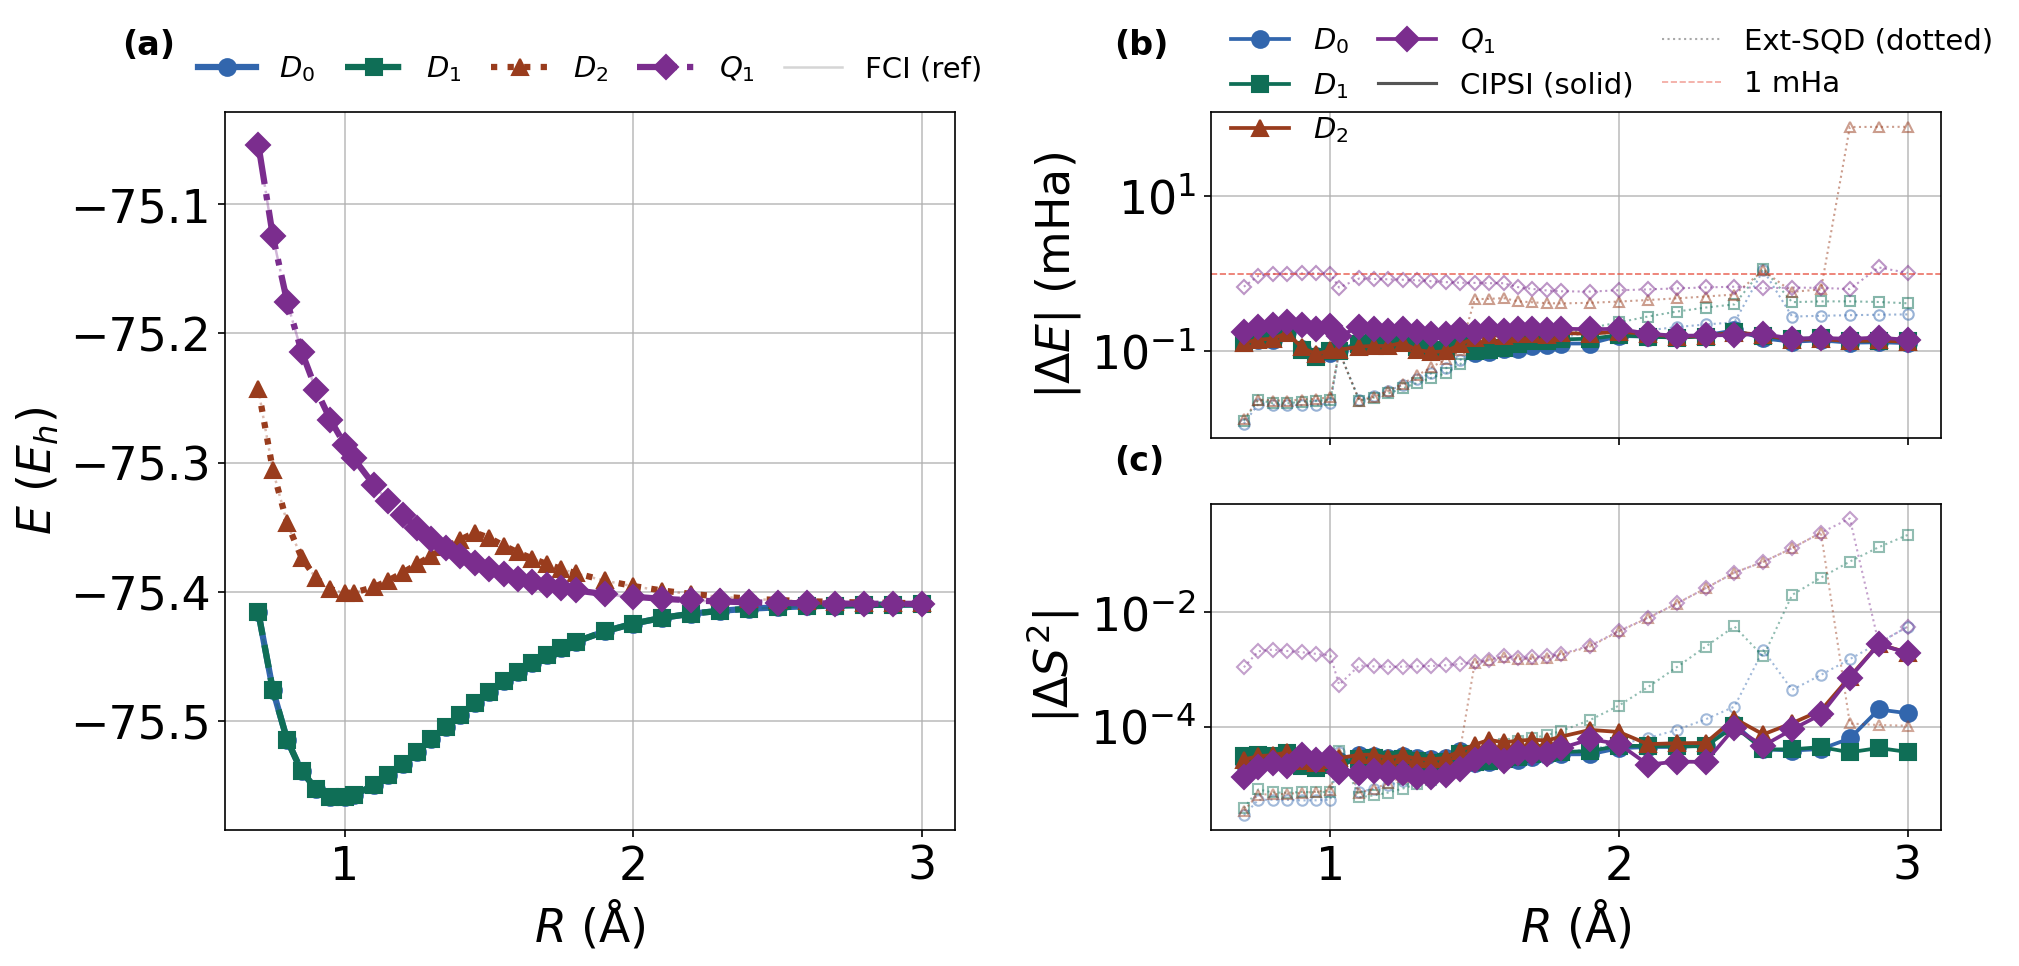

[saved] oh_18o_fig1_cipsi.png  (35.0×16.0 cm, 600 DPI)


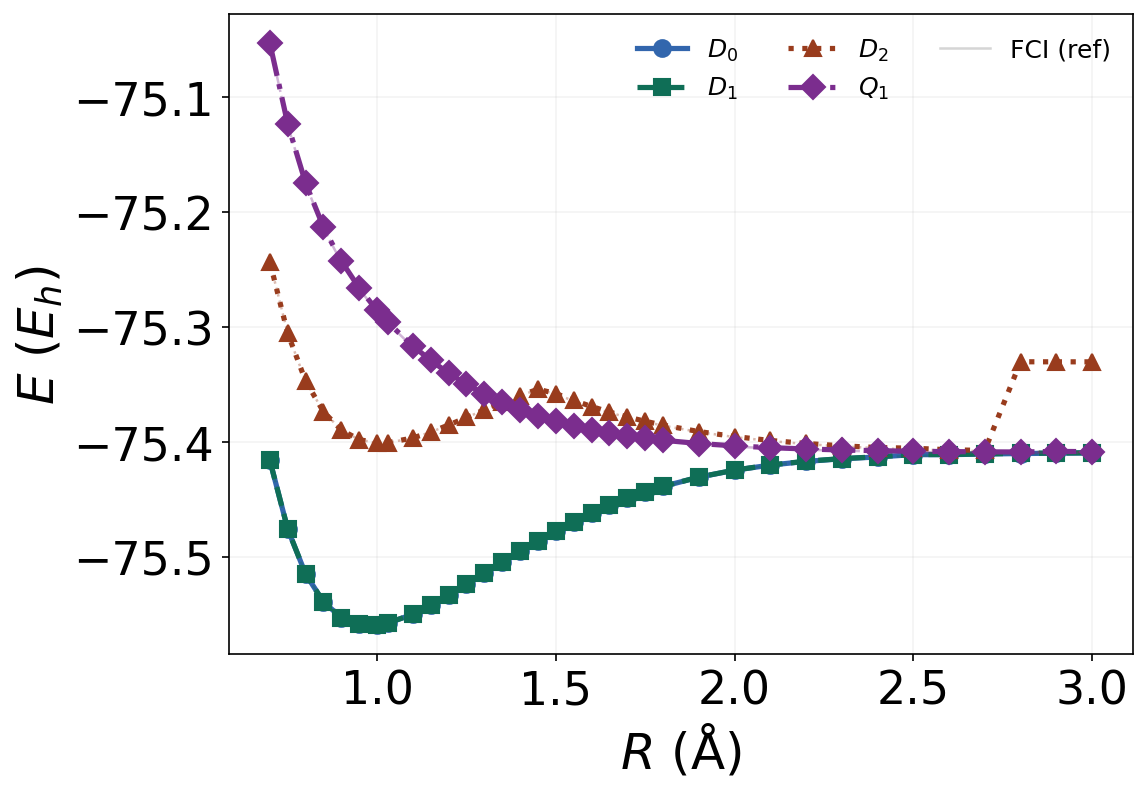

[saved] oh_18o_fig2_ext.png  (20.0×14.0 cm, 600 DPI)


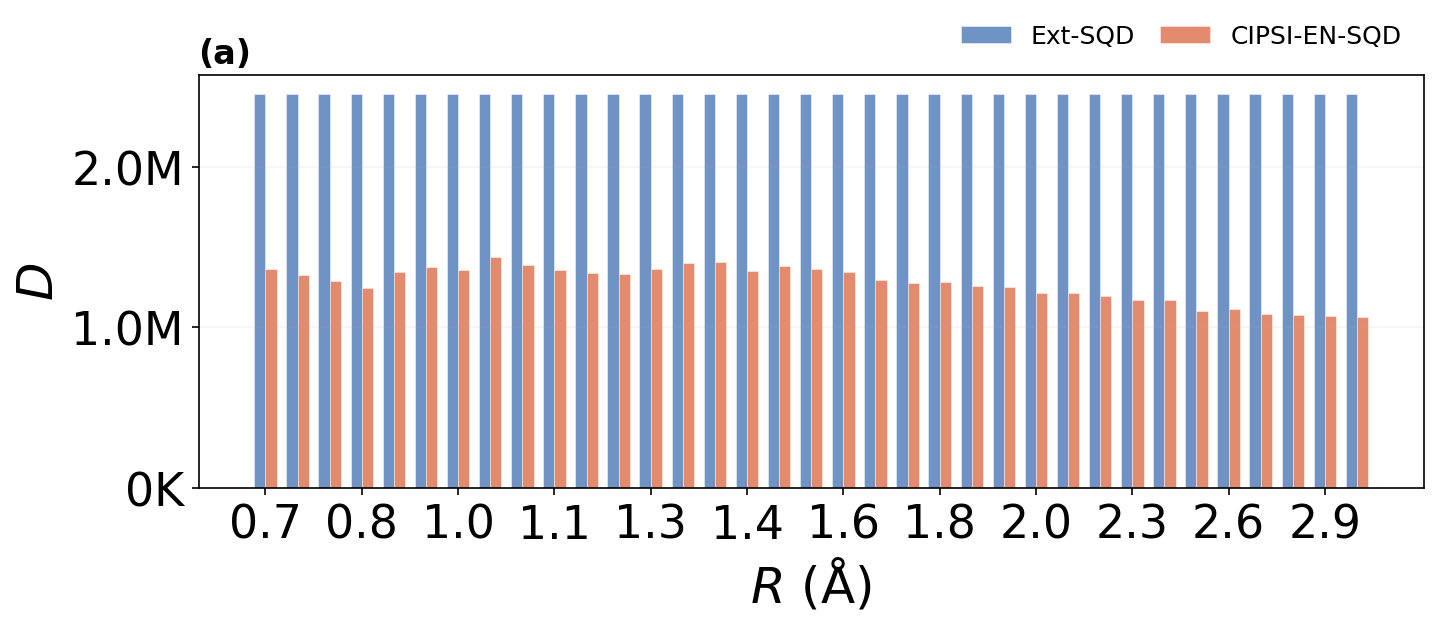

[saved] oh_18o_fig3_subspace.png  (25.0×10.0 cm, 600 DPI)


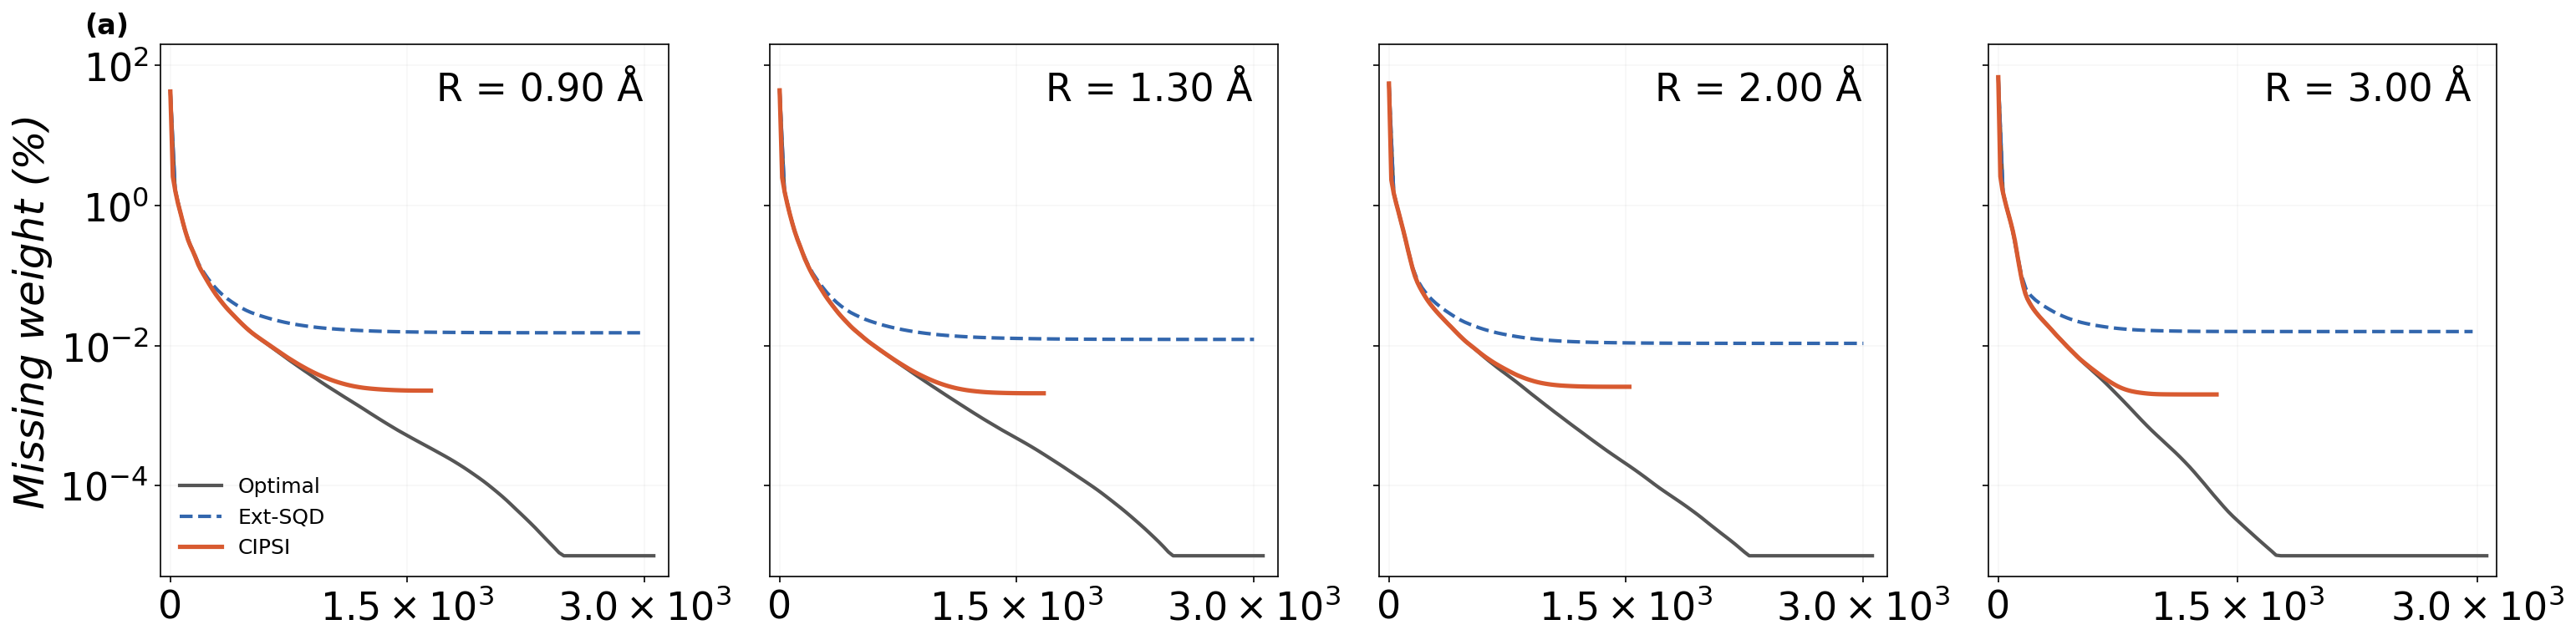

[saved] oh_18o_fig4_cumulative.png  (52.0×13.0 cm, 600 DPI)


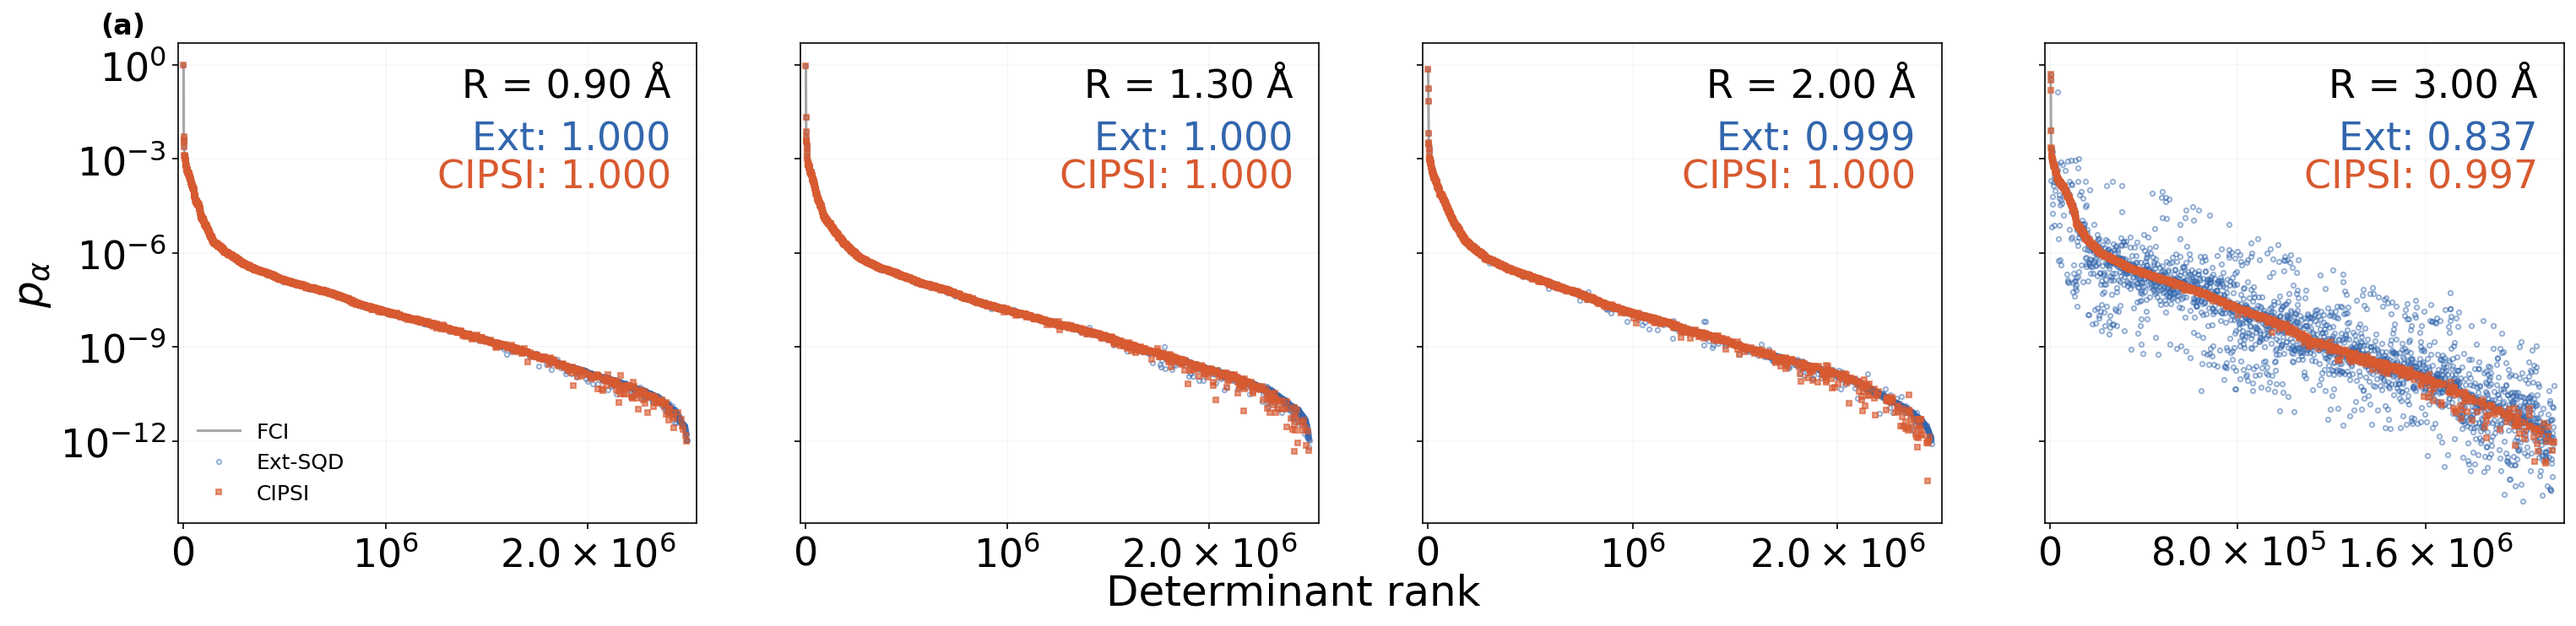

[saved] oh_18o_fig5_D0_amplitude.png  (52.0×13.0 cm, 600 DPI)


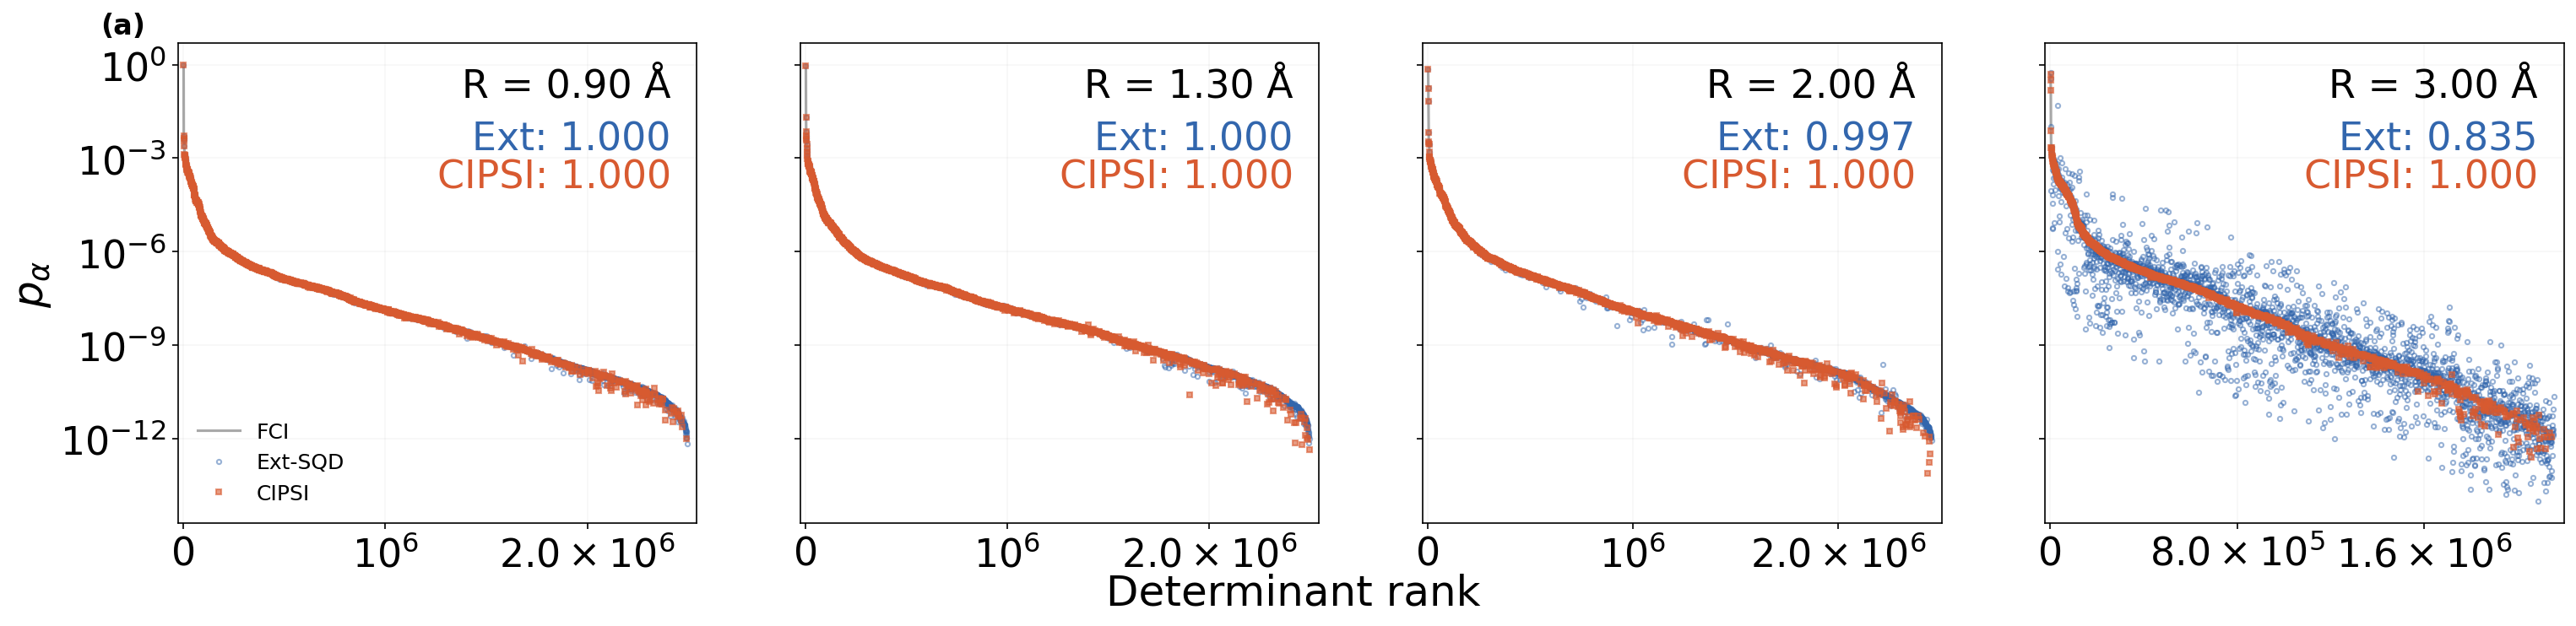

[saved] oh_18o_fig6_D1_amplitude.png  (52.0×13.0 cm, 600 DPI)


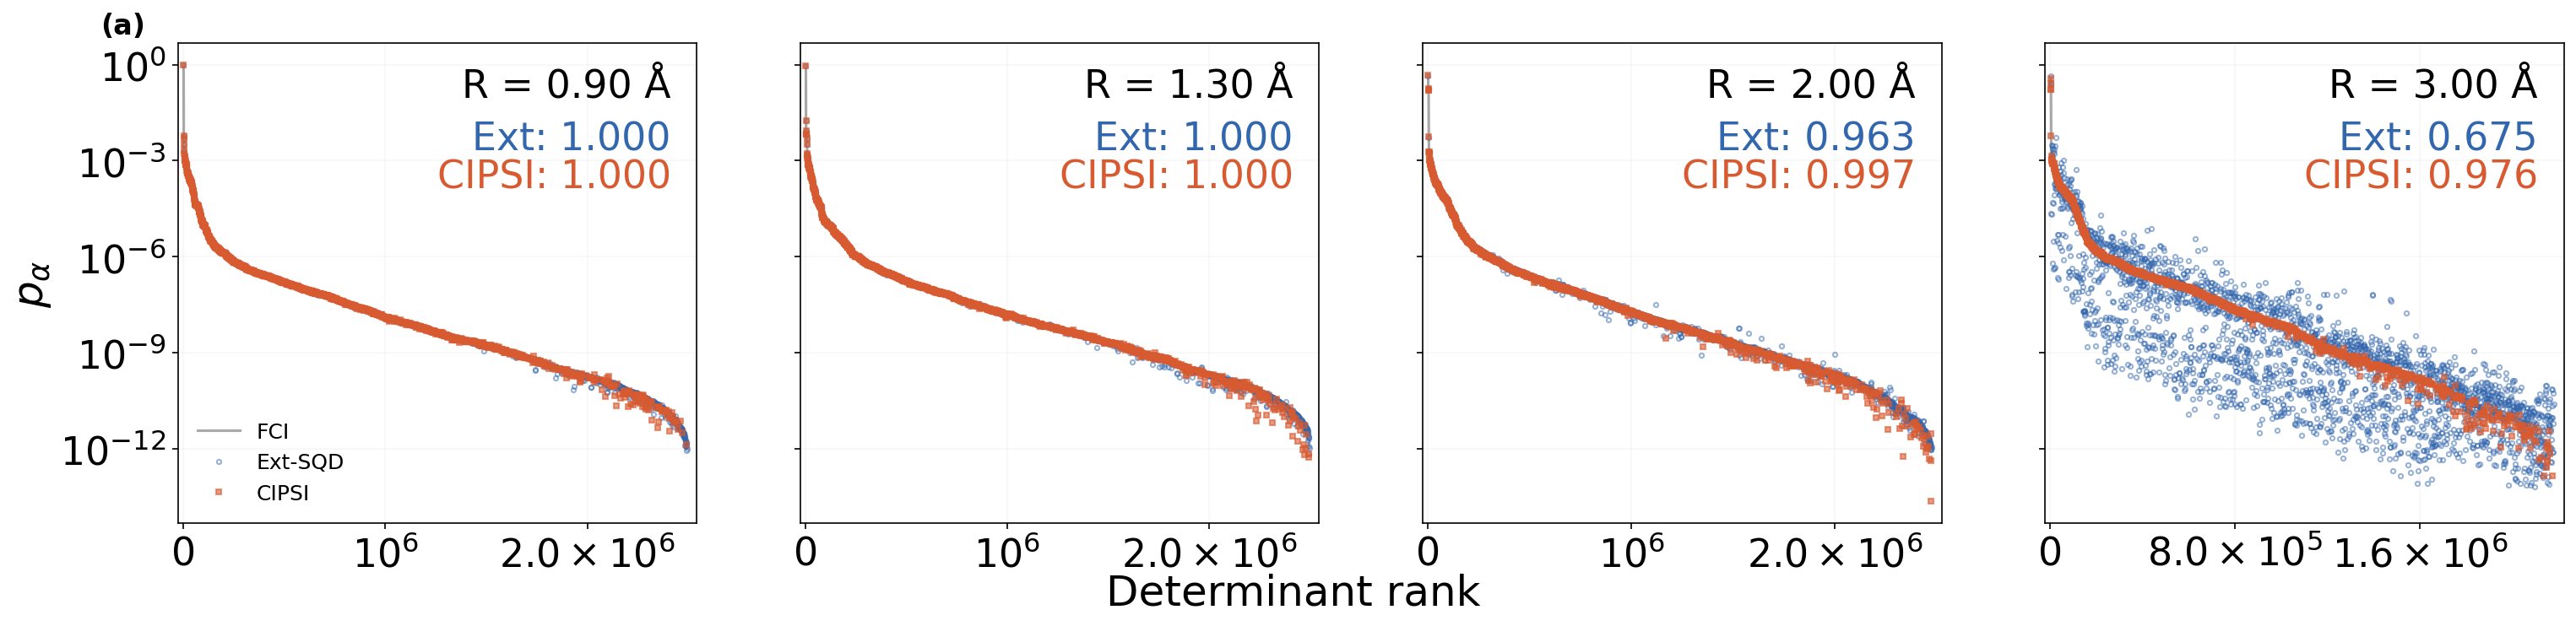

[saved] oh_18o_fig7_D2_amplitude.png  (52.0×13.0 cm, 600 DPI)


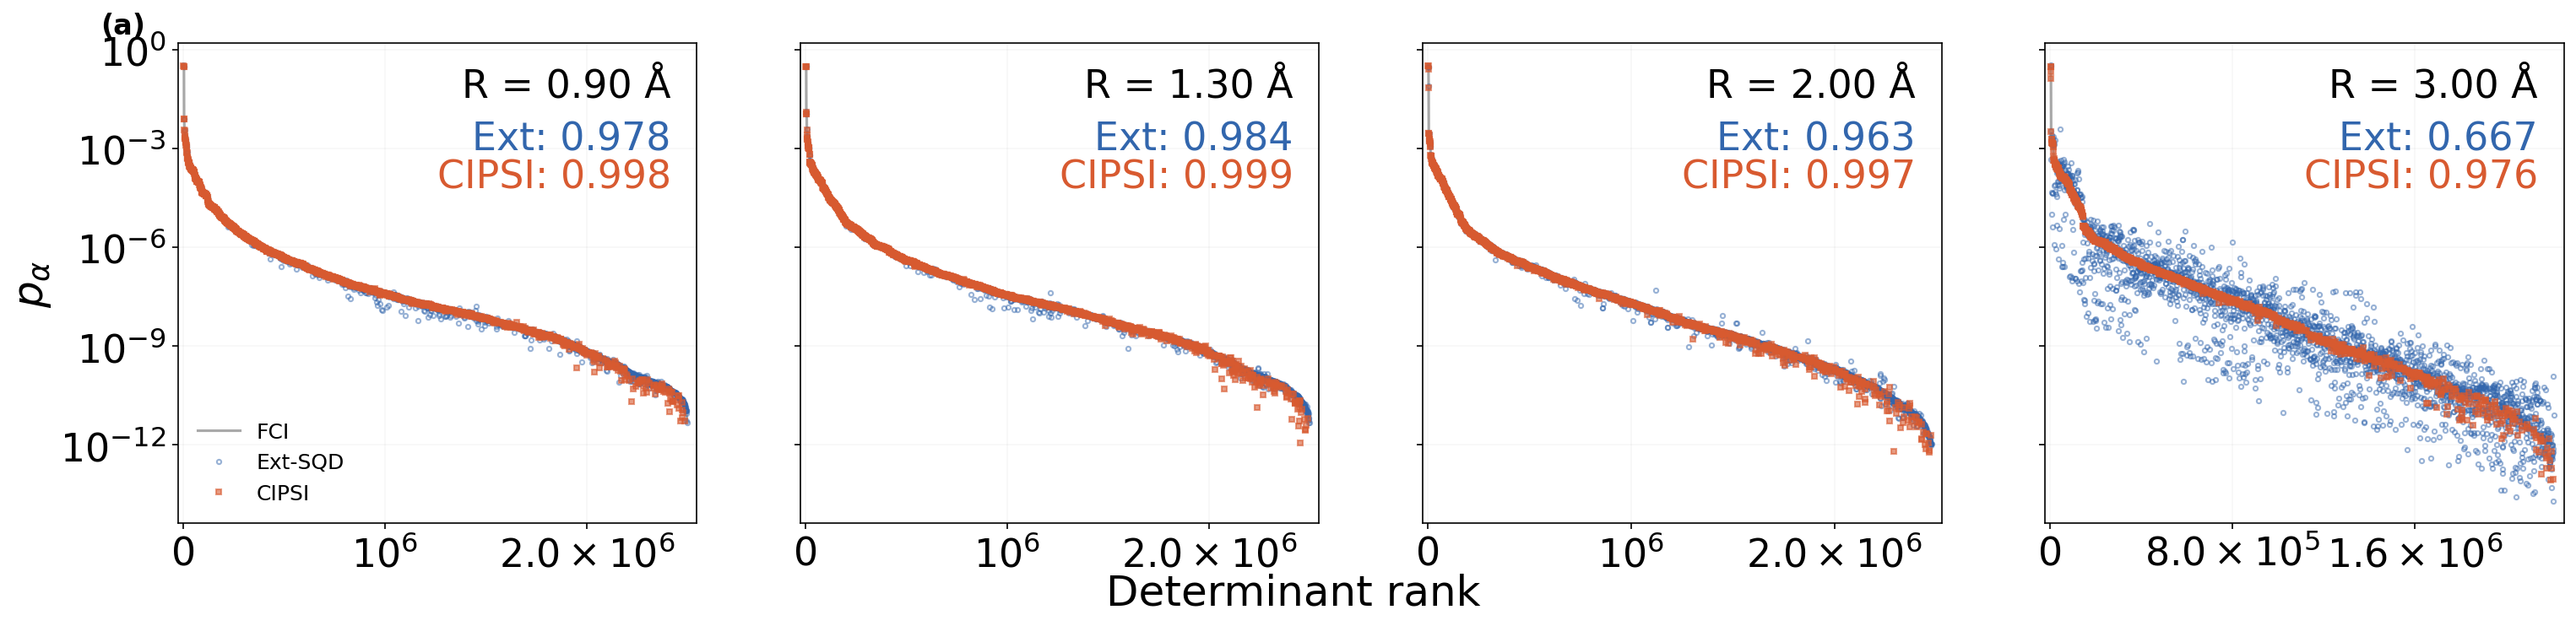

[saved] oh_18o_fig8_Q1_amplitude.png  (52.0×13.0 cm, 600 DPI)


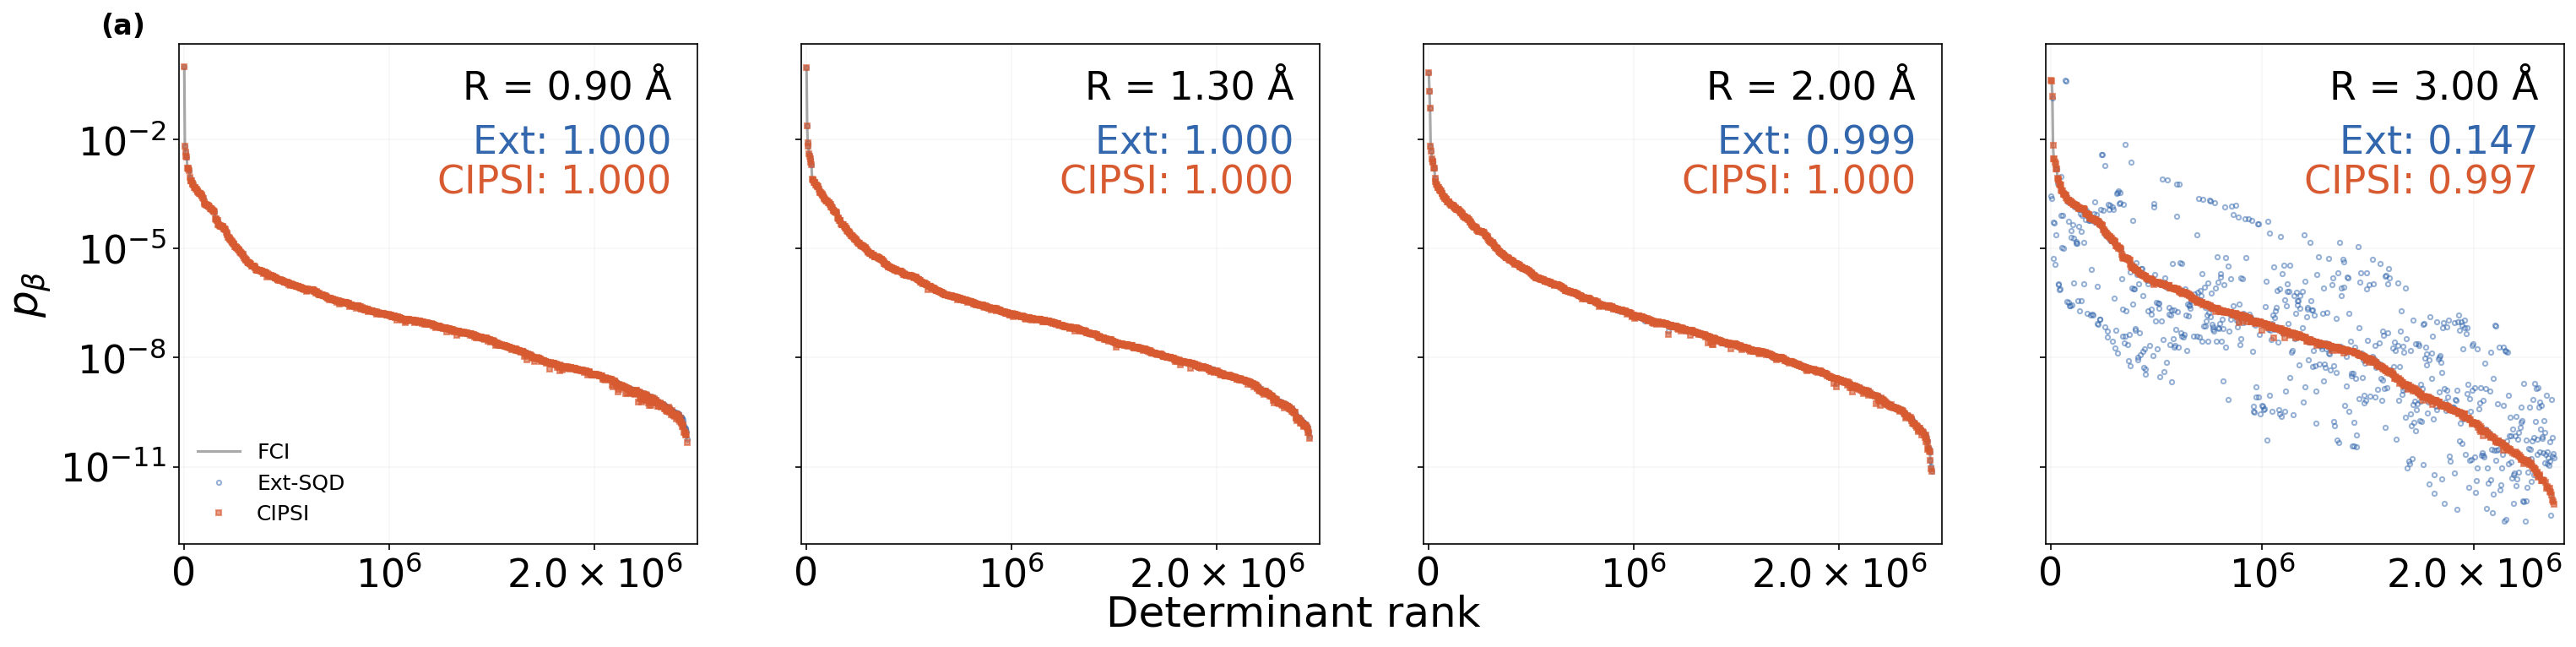

[saved] oh_18o_fig10_D0_beta_amplitude.png  (52.0×13.0 cm, 600 DPI)


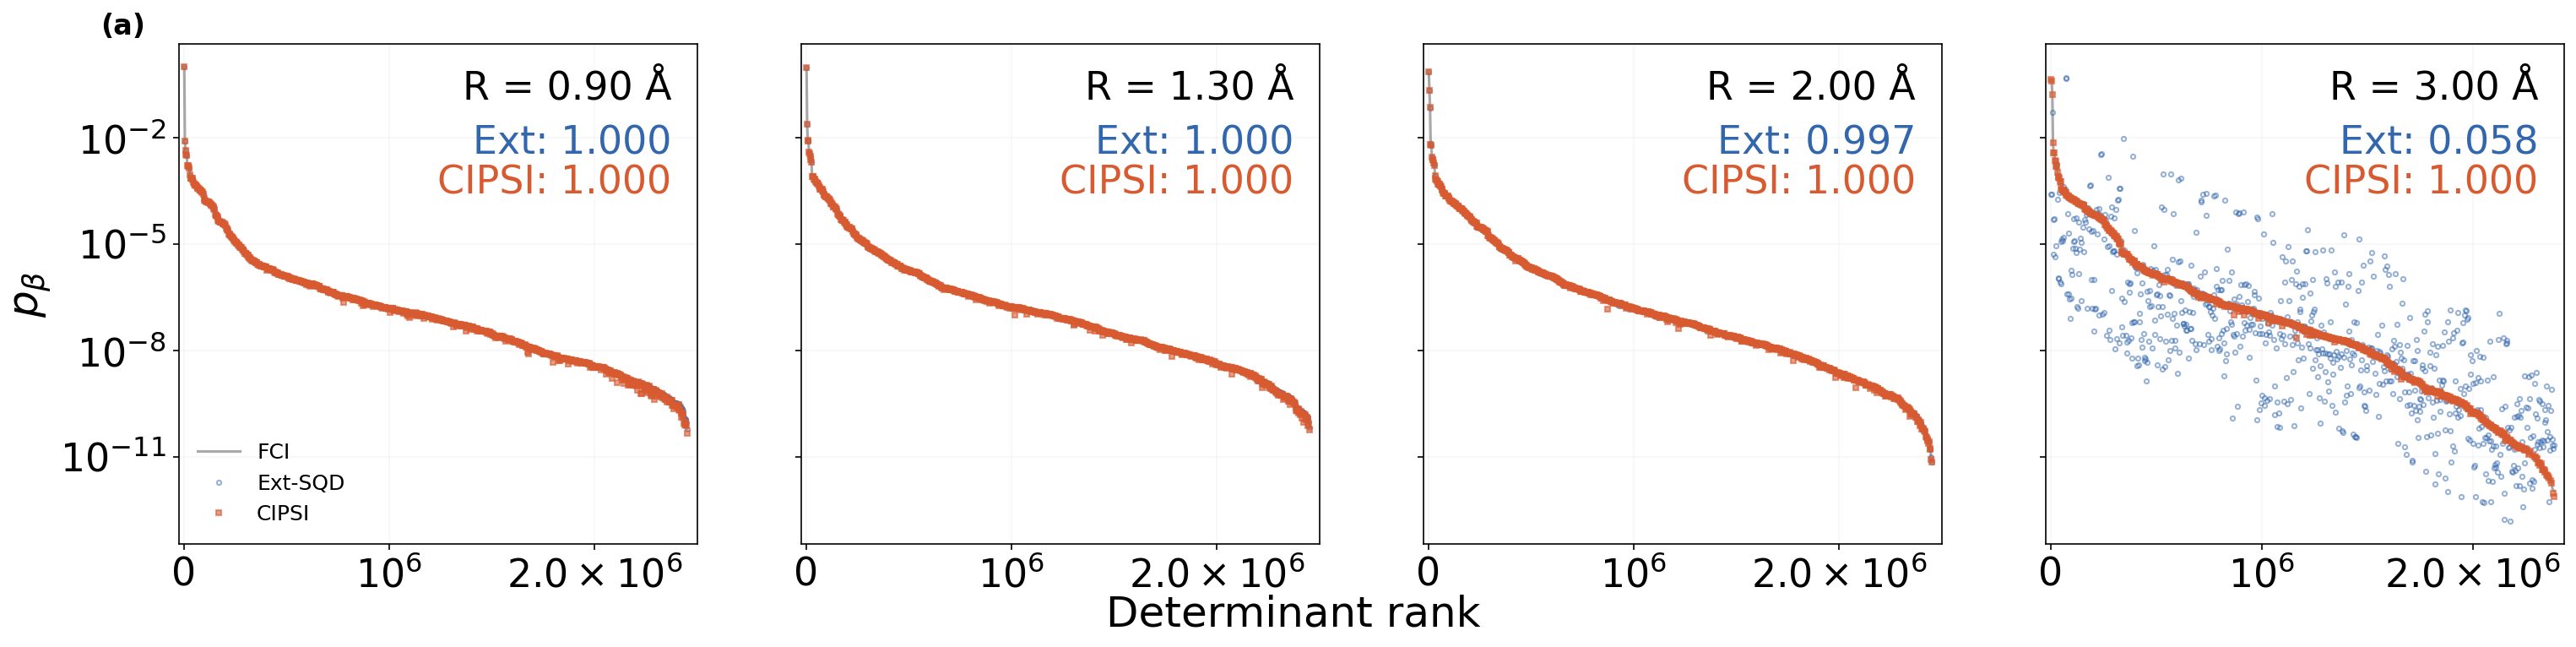

[saved] oh_18o_fig11_D1_beta_amplitude.png  (52.0×13.0 cm, 600 DPI)


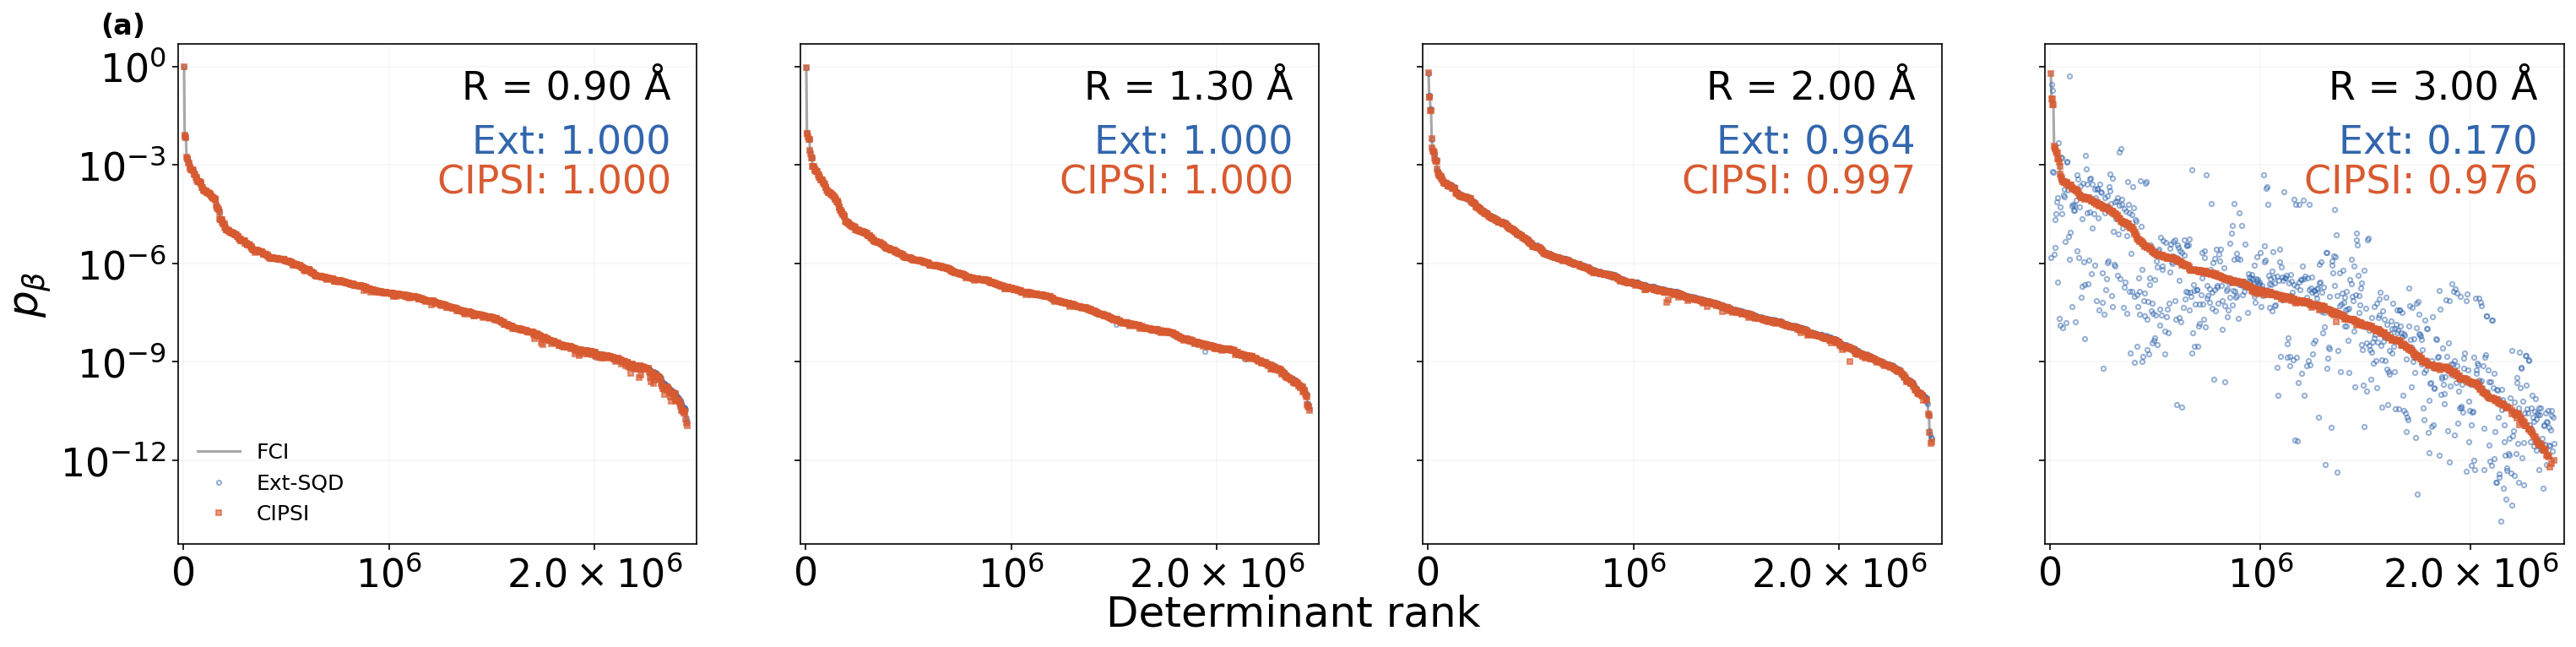

[saved] oh_18o_fig12_D2_beta_amplitude.png  (52.0×13.0 cm, 600 DPI)


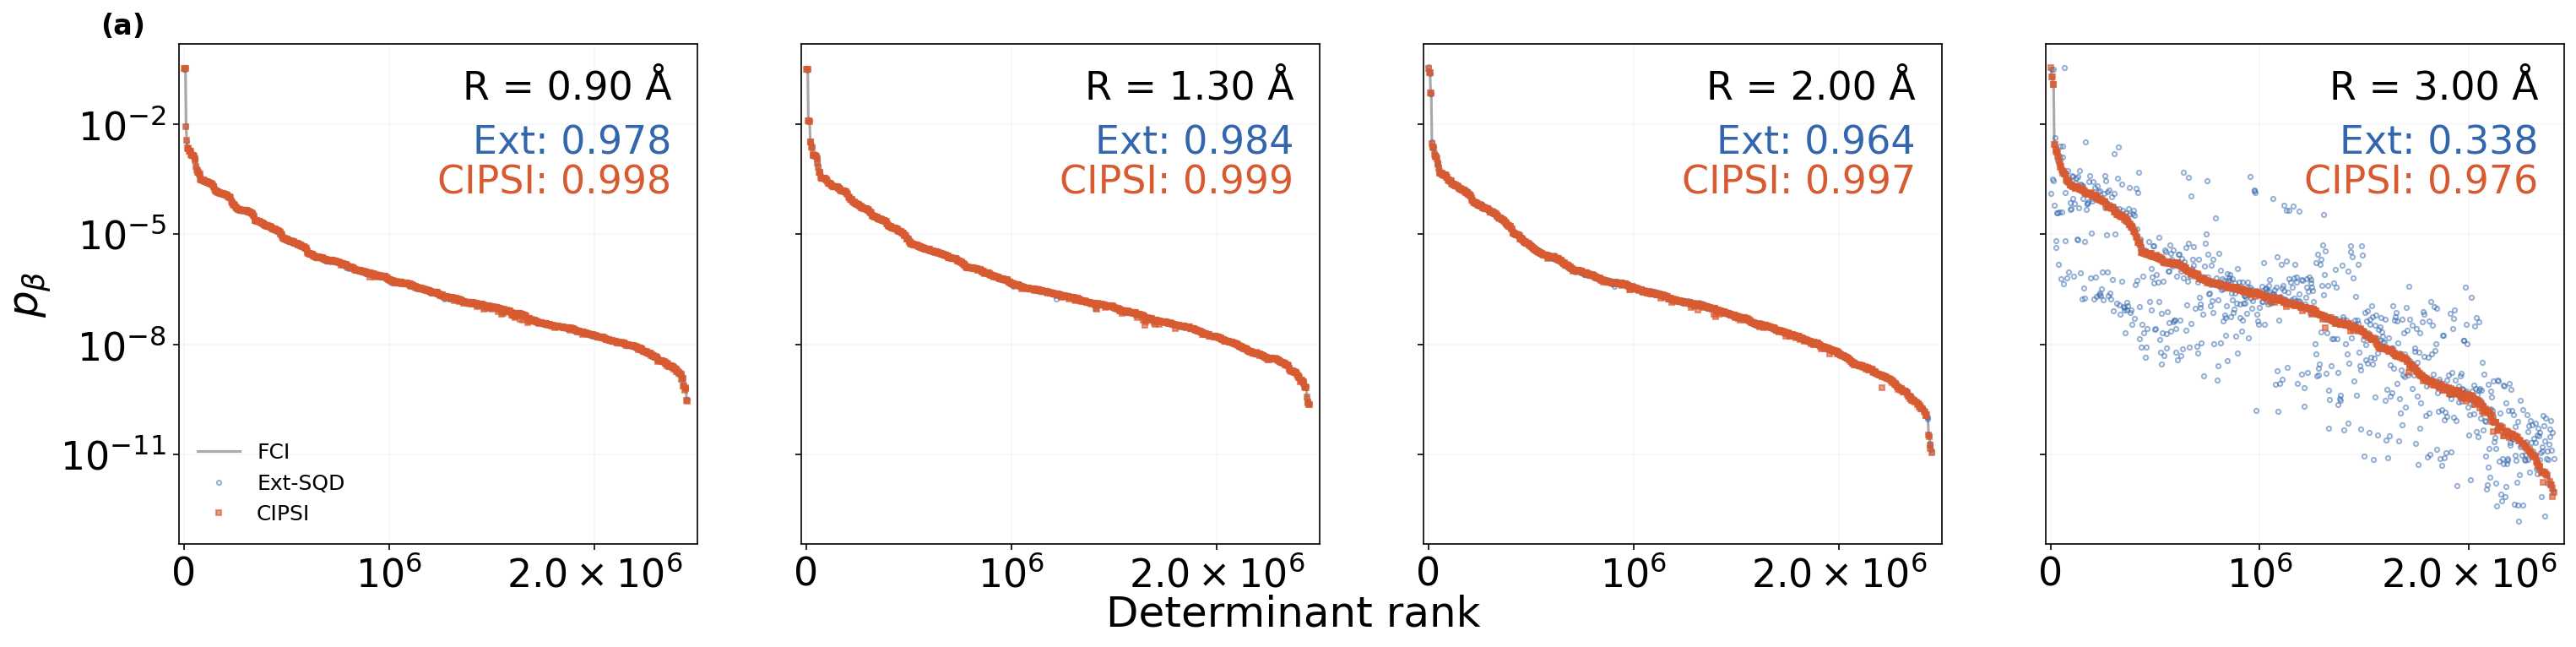

[saved] oh_18o_fig13_Q1_beta_amplitude.png  (52.0×13.0 cm, 600 DPI)


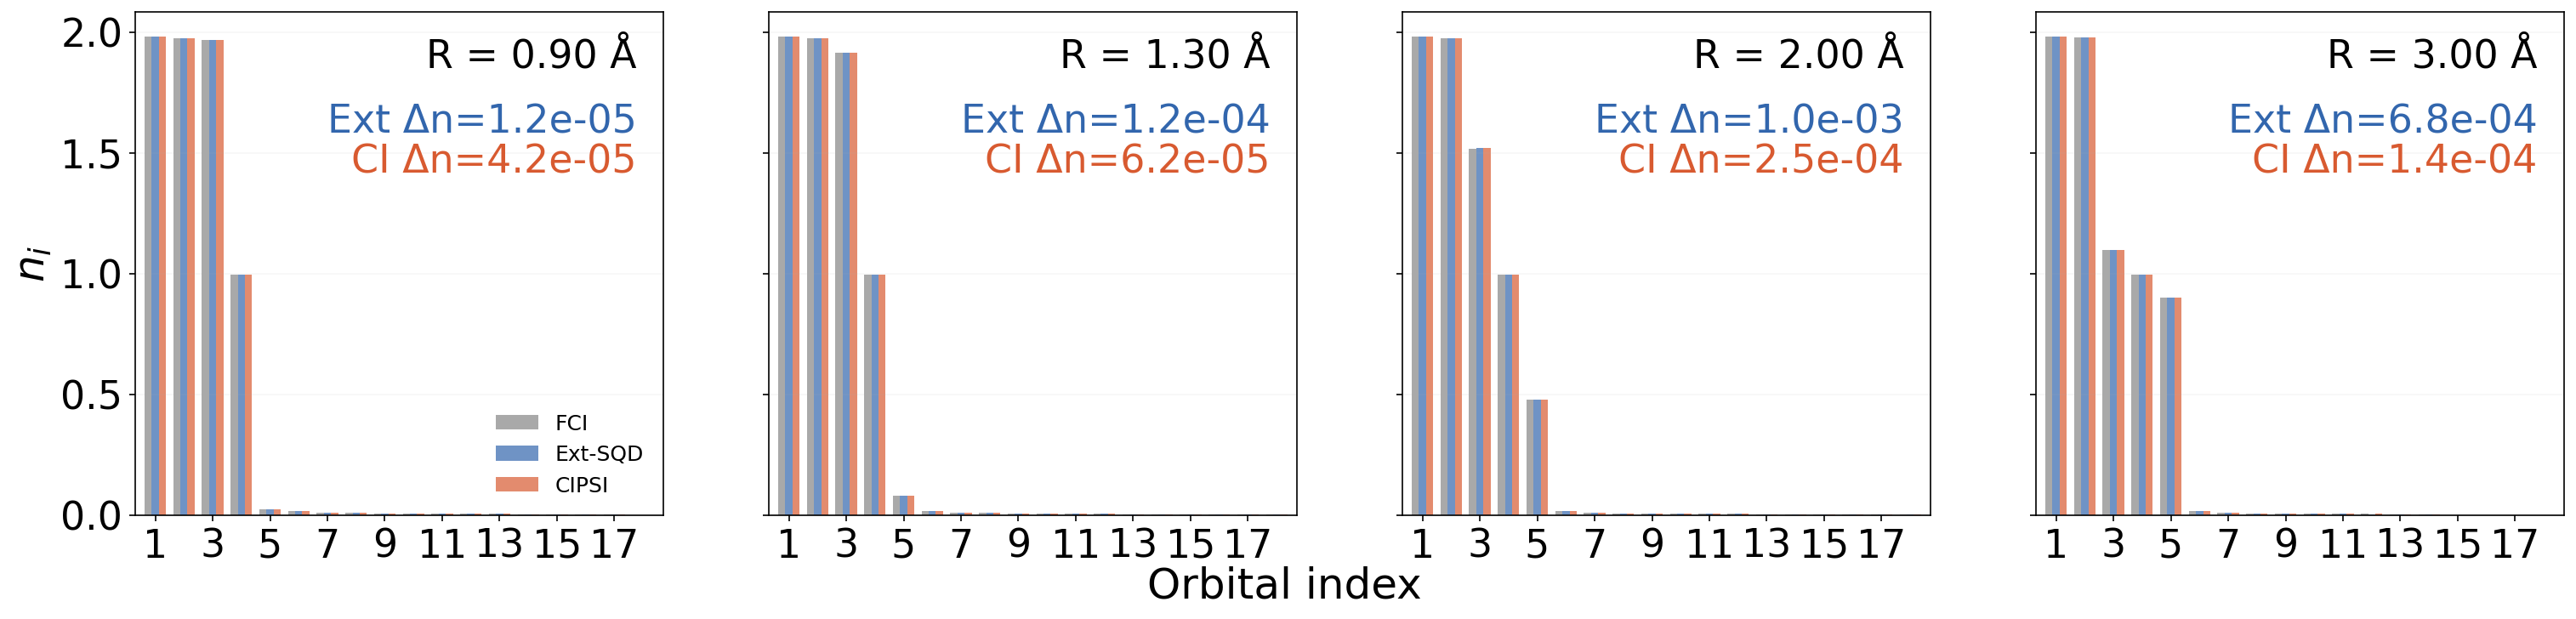

[saved] oh_18o_fig9_natorb.png  (52.0×13.0 cm, 600 DPI)


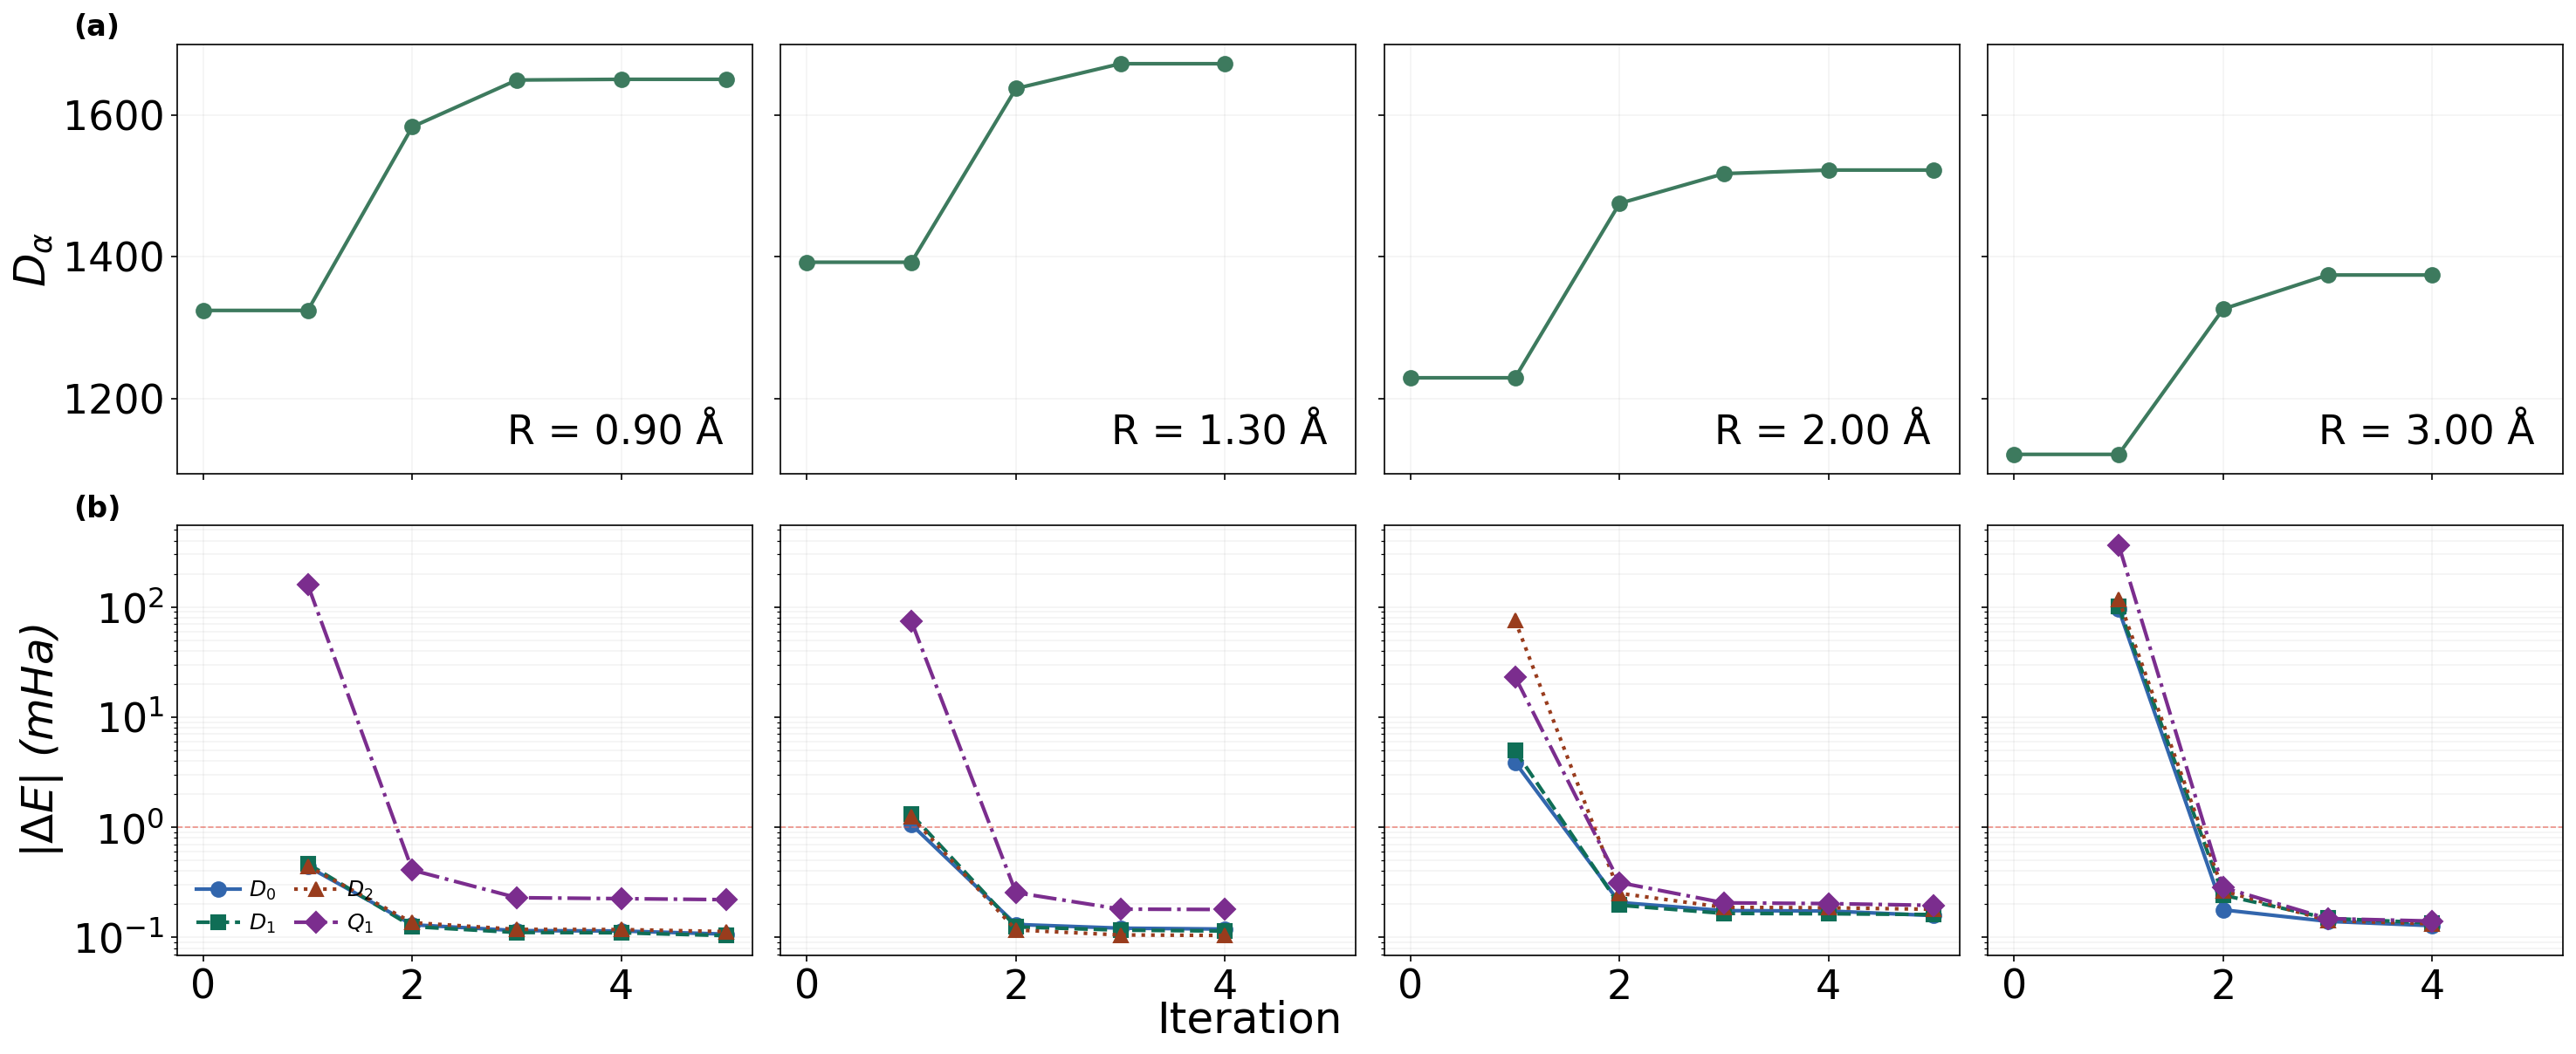

[saved] oh_18o_fig14_convergence.png  (52.0×20.8 cm, 600 DPI)

    R |    ext_D     ci_D     %   eff |    D0_ext    D0_ci |   D1_ext    D1_ci |   D2_ext    D2_ci |   Q1_ext    Q1_ci |
----------------------------------------------------------------------------------------------------------------------------------
 0.70 |  2450448  1361610   56%  1.8x |     +0.01    +0.14 |    +0.01    +0.13 |    +0.01    +0.13 |    +0.68    +0.18 |
 0.75 |  2450448  1324372   54%  1.8x |     +0.02    +0.14 |    +0.02    +0.16 |    +0.02    +0.14 |    +0.94    +0.20 |
 0.80 |  2450448  1290145   53%  1.9x |     +0.02    +0.14 |    +0.02    +0.15 |    +0.02    +0.15 |    +1.00    +0.22 |
 0.85 |  2450448  1248129   51%  2.0x |     +0.02    +0.18 |    +0.02    +0.19 |    +0.02    +0.17 |    +1.00    +0.24 |
 0.90 |  2450448  1343100   55%  1.8x |     +0.02    +0.11 |    +0.02    +0.10 |    +0.02    +0.11 |    +1.01    +0.22 |
 0.95 |  2450448  1376474   56%  1.8x |     +0.02    +0.09 |    +0.02    +0.08 |

In [147]:
#!/usr/bin/env python
"""OH radical (7e,18o) paper figures — updated layout.

Fig 1: CIPSI-EN-SQD  (PES + ΔE + ΔS²)    — 3 panels combined
Fig 2: Ext-SQD       (PES + ΔE + ΔS²)    — 3 panels combined
Fig 3: Subspace dimension                  — bar chart
Fig 4: Cumulative WF recovery              — 4 R panels [MAX over states]
Fig 5: D0 amplitude (state-resolved α)     — 4 R panels
Fig 6: D1 amplitude                        — 4 R panels
Fig 7: D2 amplitude                        — 4 R panels  ← PAPER KEY
Fig 8: Q1 amplitude                        — 4 R panels
Fig 9: Natural orbital occupation           — 4 R panels

PRE-REQUISITE: run make_recovery_curves.py on the JSON first to add
  wf_analysis.opt_curve_max / ext_curve_max / cipsi_curve_max
  wf_analysis.n_states_ref / n_states_ext / n_states_cipsi

All sizes in cm, DPI=600.
"""
import json, os, numpy as np, matplotlib, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib.lines import Line2D
try: get_ipython()
except: matplotlib.use("Agg")

# ============ Config ============
FNAME = "oh_18o_pes.json"
PREFIX = "oh_18o"
SAVE_DPI = 600
EXACT_SIZE = True    # True: 정확한 크기 유지, False: bbox_inches="tight"

def cm2in(w, h): return (w / 2.54, h / 2.54)

# ============ Fig 1 설정 ============
FIG1_SIZE  = (35, 16)       # cm
FIG1_FONT  = 22             # axis label
FIG1_TICK  = 22             # tick numbers
FIG1_LGD   = 14             # legend
FIG1_MS    = 8              # marker
FIG1_MS2   = 5              # Ext-SQD open marker (ΔE, ΔS²)
FIG1_PANEL = 16             # (a),(b),(c) label size
FIG1_PANEL_POS = {"(a)": (0.08, 0.94), "(b)": (0.56, 0.94), "(c)": (0.56, 0.50)}
FIG1_LAYOUT = dict(wratio=[1, 1], wspace=0.35, hspace=0.20,
                   left=0.13, right=0.96, top=0.88, bottom=0.12)

# ============ Fig 2-9 공통 설정 ============
FIG2_SIZE  = (20, 14)       # Ext-SQD PES (SI)
FIG3_SIZE  = (25, 10)       # Subspace
FIG_PNL    = (13, 13)       # Fig 4-9 per-panel cm (×4 panels)
FONT       = 24             # axis label
TICK       = 22             # tick numbers
LGD        = 12             # legend
ANNOT      = 22             # R=..Å annotation
ANNOT_S    = 22             # overlap, Δn annotation
PANEL      = 16             # (a),(b),(c)
MS         = 8              # marker
MS_SC      = 2.5            # scatter (amplitude dots)
# ===================================================

# Colors
C_REF   = "#555555"
C_EXT   = "#3266ad"
C_CIPSI = "#D85A30"

STATES = ["D0", "D1", "D2", "Q1"]
ST_DISP = {"D0": r"$D_0$", "D1": r"$D_1$", "D2": r"$D_2$", "Q1": r"$Q_1$"}
ST_COL  = {"D0": "#3266ad", "D1": "#0F6E56", "D2": "#993C1D", "Q1": "#7B2D8E"}
ST_MK   = {"D0": "o", "D1": "s", "D2": "^", "Q1": "D"}
ST_LS   = {"D0": "-", "D1": "--", "D2": ":", "Q1": "-."}
S2_EXACT = {"D0": 0.75, "D1": 0.75, "D2": 0.75, "Q1": 3.75}

REPR_R = [0.90, 1.30, 2.00, 3.00]

plt.rcParams.update({"font.size": 14, "figure.dpi": 150, "savefig.dpi": SAVE_DPI})

def sci_fmt(x, pos):
    if x == 0: return "0"
    exp = int(np.floor(np.log10(abs(x))))
    coeff = x / 10**exp
    if exp == 0: return f"{coeff:.0f}"
    if abs(coeff - 1.0) < 0.05: return rf"$10^{{{exp}}}$"
    return rf"${coeff:.1f}\times10^{{{exp}}}$"

# ============ Load data ============
with open(FNAME) as f: all_data = json.load(f)
all_data.sort(key=lambda d: d["R"])

STATES = [s for s in STATES if any(pt.get("fci",{}).get(s) is not None for pt in all_data)]
Rs = [pt["R"] for pt in all_data]
print(f"Loaded {FNAME}: {len(all_data)} pts, states={STATES}")
# ============================================================================
# Auto post-processing: add MAX-over-states recovery curves if missing
# ============================================================================
def _cum_curve(rho_full, mask, total, max_pts=100):
    """Cumulative curve: sort weights in mask descending, cumsum, normalize."""
    ws = rho_full[mask]
    ws_sorted = np.sort(ws)[::-1]
    cum = np.cumsum(ws_sorted)
    if len(cum) == 0:
        return [], []
    cum_pct = (cum / max(total, 1e-20) * 100).tolist()
    if len(cum_pct) <= max_pts:
        return list(range(1, len(cum_pct) + 1)), cum_pct
    step = max(1, len(cum_pct) // max_pts)
    idx = list(range(0, len(cum_pct), step))
    if idx[-1] != len(cum_pct) - 1:
        idx.append(len(cum_pct) - 1)
    return [i + 1 for i in idx], [cum_pct[i] for i in idx]


def _aggregate_states(wf_amps, channel, n_full):
    """Stack full-space alpha-marginals across states. Returns (n_states, n_full) or None."""
    arrs = []
    for state_lb, entry in wf_amps.items():
        key = f"{channel}_a"
        if key in entry:
            arr = np.array(entry[key], dtype=float)
            if len(arr) == n_full:
                arrs.append(arr)
    if not arrs:
        return None
    return np.stack(arrs, axis=0)


def _add_max_curves(pt, eps_zero=1e-15):
    """Add MAX/AVG-over-states recovery curves to wf_analysis (in-place)."""
    wfa = pt.get("wf_analysis", {})
    wf_amps = pt.get("wf_amps", {})
    meta = pt.get("wf_amps_meta", {})
    n_alpha_full = meta.get("n_alpha_full")
    if n_alpha_full is None or not wf_amps:
        return False

    ref_stack = _aggregate_states(wf_amps, "ref", n_alpha_full)
    ext_stack = _aggregate_states(wf_amps, "ext", n_alpha_full)
    cipsi_stack = _aggregate_states(wf_amps, "cipsi", n_alpha_full)
    if ref_stack is None or ext_stack is None or cipsi_stack is None:
        return False

    ref_max = ref_stack.max(axis=0)
    ref_avg = ref_stack.mean(axis=0)
    ext_mask = np.any(ext_stack > eps_zero, axis=0)
    cipsi_mask = np.any(cipsi_stack > eps_zero, axis=0)
    full_mask = np.ones(n_alpha_full, dtype=bool)
    ref_max_total = float(ref_max.sum())
    ref_avg_total = float(ref_avg.sum())

    wfa["opt_curve_max"]   = dict(zip(["x","y"], _cum_curve(ref_max, full_mask,  ref_max_total)))
    wfa["ext_curve_max"]   = dict(zip(["x","y"], _cum_curve(ref_max, ext_mask,   ref_max_total)))
    wfa["cipsi_curve_max"] = dict(zip(["x","y"], _cum_curve(ref_max, cipsi_mask, ref_max_total)))
    wfa["opt_curve_avg"]   = dict(zip(["x","y"], _cum_curve(ref_avg, full_mask,  ref_avg_total)))
    wfa["ext_curve_avg"]   = dict(zip(["x","y"], _cum_curve(ref_avg, ext_mask,   ref_avg_total)))
    wfa["cipsi_curve_avg"] = dict(zip(["x","y"], _cum_curve(ref_avg, cipsi_mask, ref_avg_total)))
    wfa["n_states_ref"] = int(ref_stack.shape[0])
    wfa["n_states_ext"] = int(ext_stack.shape[0])
    wfa["n_states_cipsi"] = int(cipsi_stack.shape[0])
    wfa["ref_max_total"] = ref_max_total
    wfa["ref_avg_total"] = ref_avg_total
    pt["wf_analysis"] = wfa
    return True


# Apply to all geometries that lack opt_curve_max
need_proc = [pt for pt in all_data if "opt_curve_max" not in pt.get("wf_analysis", {})]
if need_proc:
    print(f"[auto] Computing MAX-curves for {len(need_proc)}/{len(all_data)} geometries...")
    n_done = sum(_add_max_curves(pt) for pt in need_proc)
    print(f"[auto] Done: {n_done} geometries augmented")
else:
    print(f"[auto] MAX-curves already present.")


def get_repr_idx():
    idx = []
    for r in REPR_R:
        dists = [abs(R - r) for R in Rs]
        idx.append(dists.index(min(dists)))
    return sorted(set(idx))

def get_full_dim(dims, key):
    if key == "ext":
        a = dims.get("ext_a", 0); b = dims.get("ext_b", 0)
        if a > 0 and b > 0: return a * b
    elif key == "cipsi":
        a = dims.get("cipsi_a", 0); b = dims.get("cipsi_b", 0)
        if a > 0 and b > 0: return a * b
    return dims.get(key, 0)

def get_beta_counts(dims):
    ext_b = dims.get("ext_b", 0)
    cipsi_b = dims.get("cipsi_b", 0)
    full_b = ext_b
    return max(full_b, 1), max(ext_b, 1), max(cipsi_b, 1)

def savefig(fig, name):
    if EXACT_SIZE:
        fig.savefig(f"{PREFIX}_{name}.png", dpi=SAVE_DPI)
    else:
        fig.savefig(f"{PREFIX}_{name}.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()
    # Print actual saved size in cm
    w_in, h_in = fig.get_size_inches()
    print(f"[saved] {PREFIX}_{name}.png  ({w_in*2.54:.1f}×{h_in*2.54:.1f} cm, {SAVE_DPI} DPI)")


# ============================================================================
# Fig 1: CIPSI-EN-SQD combined (PES + ΔE + ΔS²)
# Layout: [PES (full height) | ΔE (top-right) / ΔS² (bottom-right)]
# ============================================================================
fig1 = plt.figure(figsize=cm2in(*FIG1_SIZE))
gs1 = fig1.add_gridspec(2, 2, width_ratios=FIG1_LAYOUT["wratio"], hspace=FIG1_LAYOUT["hspace"], wspace=FIG1_LAYOUT["wspace"])
ax1_pes = fig1.add_subplot(gs1[:, 0])   # PES: left column, spans both rows
ax1_de  = fig1.add_subplot(gs1[0, 1])   # ΔE: top-right
ax1_ds2 = fig1.add_subplot(gs1[1, 1])   # ΔS²: bottom-right

# --- (a) PES ---
for lb in STATES:
    col, ls, mk = ST_COL[lb], ST_LS[lb], ST_MK[lb]
    r_ref = [pt["R"] for pt in all_data if pt["fci"].get(lb) is not None]
    e_ref = [pt["fci"][lb] for pt in all_data if pt["fci"].get(lb) is not None]
    r_ci  = [pt["R"] for pt in all_data if pt["cipsi"].get(lb) is not None]
    e_ci  = [pt["cipsi"][lb] for pt in all_data if pt["cipsi"].get(lb) is not None]

    ax1_pes.plot(r_ref, e_ref, color=col, ls=ls, lw=1.2, alpha=0.35)
    if e_ci:
        ax1_pes.plot(r_ci, e_ci, color=col, ls=ls, lw=3.0, marker=mk, ms=FIG1_MS,
                     label=f"{ST_DISP[lb]}")

ax1_pes.plot([], [], color="#888", ls="-", lw=1.2, alpha=0.35, label="FCI (ref)")
ax1_pes.set_xlabel(r"$R$ ($\mathrm{\AA}$)", fontsize=FIG1_FONT)
ax1_pes.set_ylabel(r"$E$ ($E_h$)", fontsize=FIG1_FONT)
ax1_pes.legend(fontsize=FIG1_LGD, ncol=5, loc="center", frameon=False, columnspacing=1.0, bbox_to_anchor=(0, 1.01, 1, 0.1))
ax1_pes.tick_params(labelsize=FIG1_TICK)
ax1_pes.grid(True, alpha=0.8)

# --- (b) ΔE (both Ext-SQD + CIPSI) ---
for lb in STATES:
    col, mk = ST_COL[lb], ST_MK[lb]
    ext_r, ext_err = [], []
    for pt in all_data:
        ef = pt["fci"].get(lb); ee = pt["ext_sqd"].get(lb)
        if ef is not None and ee is not None:
            ext_r.append(pt["R"]); ext_err.append(abs(ee - ef) * 1000)
    ext_err = [max(e, 1e-3) for e in ext_err]
    if ext_err:
        ax1_de.semilogy(ext_r, ext_err, color=col, ls=":", lw=1.0, marker=mk, ms=FIG1_MS2,
                        fillstyle="none", alpha=0.5)
    ci_r, ci_err = [], []
    for pt in all_data:
        ef = pt["fci"].get(lb); ec = pt["cipsi"].get(lb)
        if ef is not None and ec is not None:
            ci_r.append(pt["R"]); ci_err.append(abs(ec - ef) * 1000)
    ci_err = [max(e, 1e-3) for e in ci_err]
    if ci_err:
        ax1_de.semilogy(ci_r, ci_err, color=col, ls="-", lw=1.8, marker=mk, ms=FIG1_MS,
                        label=ST_DISP[lb])

ax1_de.axhline(1.0, color="#e74c3c", ls="--", lw=0.8, alpha=0.5)
ax1_de.plot([], [], color="#555", ls="-", lw=1.5, label="CIPSI (solid)")
ax1_de.plot([], [], color="#555", ls=":", lw=1.0, alpha=0.5, label="Ext-SQD (dotted)")
ax1_de.axhline(1.0, color="#e74c3c", ls="--", lw=0.8, alpha=0.5, label="1 mHa")
ax1_de.set_ylabel(r"$|\Delta E|$ (mHa)", fontsize=FIG1_FONT)
ax1_de.legend(fontsize=FIG1_LGD, ncol=3, loc="center", frameon=False, columnspacing=1.0, bbox_to_anchor=(0.55, 1.08))
ax1_de.tick_params(labelsize=FIG1_TICK, labelbottom=False)  # (b) x tick 숨김
ax1_de.grid(True, which="both", alpha=0.8)

# --- (c) ΔS² (both Ext-SQD + CIPSI) ---
for lb in STATES:
    col, mk = ST_COL[lb], ST_MK[lb]
    s2_exact = S2_EXACT[lb]
    ext_r, ext_ds2 = [], []
    for pt in all_data:
        s2_ext = pt.get("ext_s2", {}).get(lb)
        if s2_ext is not None:
            ext_r.append(pt["R"]); ext_ds2.append(max(abs(s2_ext - s2_exact), 1e-6))
    if ext_ds2:
        ax1_ds2.semilogy(ext_r, ext_ds2, color=col, ls=":", lw=1.0, marker=mk, ms=FIG1_MS2,
                         fillstyle="none", alpha=0.45)
    ci_r, ci_ds2 = [], []
    for pt in all_data:
        s2_ci = pt.get("cipsi_s2", {}).get(lb)
        if s2_ci is not None:
            ci_r.append(pt["R"]); ci_ds2.append(max(abs(s2_ci - s2_exact), 1e-6))
    if ci_ds2:
        ax1_ds2.semilogy(ci_r, ci_ds2, color=col, ls="-", lw=1.8, marker=mk, ms=FIG1_MS,
                         label=ST_DISP[lb])

ax1_ds2.plot([], [], color="#555", ls="-", lw=1.5, label="CIPSI (solid)")
ax1_ds2.plot([], [], color="#555", ls=":", lw=1.0, alpha=0.5, label="Ext-SQD (dotted)")
ax1_ds2.set_xlabel(r"$R$ ($\mathrm{\AA}$)", fontsize=FIG1_FONT)
ax1_ds2.set_ylabel(r"$|\Delta S^2|$", fontsize=FIG1_FONT)
# ax1_ds2.legend(fontsize=FIG1_LGD, ncol=2, loc="upper left", frameon=False, framealpha=0.5)
ax1_ds2.tick_params(labelsize=FIG1_TICK)
ax1_ds2.grid(True, which="both", alpha=0.8)

for lbl, (fx, fy) in FIG1_PANEL_POS.items():
    fig1.text(fx, fy, lbl, fontsize=FIG1_PANEL, fontweight="bold")

fig1.subplots_adjust(left=FIG1_LAYOUT["left"], right=FIG1_LAYOUT["right"], top=FIG1_LAYOUT["top"], bottom=FIG1_LAYOUT["bottom"])
savefig(fig1, "fig1_cipsi")


# ============================================================================
# Fig 2: Ext-SQD PES only (for Supporting Information)
# ============================================================================
fig2, ax2 = plt.subplots(figsize=cm2in(*FIG2_SIZE))

for lb in STATES:
    col, ls, mk = ST_COL[lb], ST_LS[lb], ST_MK[lb]
    r_ref = [pt["R"] for pt in all_data if pt["fci"].get(lb) is not None]
    e_ref = [pt["fci"][lb] for pt in all_data if pt["fci"].get(lb) is not None]
    r_ext = [pt["R"] for pt in all_data if pt["ext_sqd"].get(lb) is not None]
    e_ext = [pt["ext_sqd"][lb] for pt in all_data if pt["ext_sqd"].get(lb) is not None]

    ax2.plot(r_ref, e_ref, color=col, ls=ls, lw=1.2, alpha=0.35)
    if e_ext:
        ax2.plot(r_ext, e_ext, color=col, ls=ls, lw=2.5, marker=mk, ms=MS,
                 label=f"{ST_DISP[lb]}")

ax2.plot([], [], color="#888", ls="-", lw=1.2, alpha=0.35, label="FCI (ref)")
ax2.set_xlabel(r"$R$ ($\mathrm{\AA}$)", fontsize=FONT)
ax2.set_ylabel(r"$E$ ($E_h$)", fontsize=FONT)
#ax2.set_title("Ext-SQD", fontsize=FONT, fontweight="bold")
ax2.legend(fontsize=LGD, ncol=3, loc="upper right", frameon=False, framealpha=0.5)
ax2.tick_params(labelsize=TICK)
ax2.grid(True, alpha=0.15)
fig2.tight_layout()
savefig(fig2, "fig2_ext")


# ============================================================================
# Fig 3: Subspace dimension
# ============================================================================
fig3, ax3 = plt.subplots(figsize=cm2in(*FIG3_SIZE))

ext_ds  = [get_full_dim(pt["dims"], "ext") for pt in all_data]
ci_ds   = [get_full_dim(pt["dims"], "cipsi") for pt in all_data]
ratio   = [c / max(e, 1) * 100 for e, c in zip(ext_ds, ci_ds)]

x = np.arange(len(Rs))
bar_w = 0.35
ax3.bar(x - bar_w/2, ext_ds, bar_w, color=C_EXT, alpha=0.7, label="Ext-SQD", edgecolor="white", lw=0.3)
ax3.bar(x + bar_w/2, ci_ds, bar_w, color=C_CIPSI, alpha=0.7, label="CIPSI-EN-SQD", edgecolor="white", lw=0.3)

tick_step = max(1, len(Rs) // 10)
ax3.set_xticks(x[::tick_step])
ax3.set_xticklabels([f"{Rs[i]:.1f}" for i in range(0, len(Rs), tick_step)], fontsize=TICK)
ax3.set_xlabel(r"$R$ ($\mathrm{\AA}$)", fontsize=FONT)
ax3.set_ylabel(r"$D$", fontsize=FONT, fontstyle="italic")
ax3.legend(fontsize=LGD, ncol=2, loc="lower right", frameon=False, columnspacing=1.0, bbox_to_anchor=(0, 1.01, 1, 0.1))
ax3.tick_params(labelsize=TICK)
ax3.grid(True, alpha=0.12, axis="y")
ax3.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
fig3.text(0.15, 0.92, "(a)", fontsize=PANEL, fontweight="bold")
fig3.subplots_adjust(left=0.15, right=0.98, top=0.90, bottom=0.2)
savefig(fig3, "fig3_subspace")


# ============================================================================
# Fig 4: Cumulative WF recovery (MAX-over-states aggregation)
# ============================================================================
PANEL_LETTER = "a"  # OH=a, CN=b, LiO2=c

has_curves = any(pt.get("wf_analysis", {}).get("opt_curve_max", {}).get("x") for pt in all_data)
if has_curves:
    repr_idx = get_repr_idx()
    n_panels = len(repr_idx)
    fig4, axes4 = plt.subplots(1, n_panels, figsize=cm2in(FIG_PNL[0]*n_panels, FIG_PNL[1]),
                               sharey=True, squeeze=False)
    axes4 = axes4[0]
    for i, idx in enumerate(repr_idx):
        ax = axes4[i]; pt = all_data[idx]; wfa = pt.get("wf_analysis", {})
        opt = wfa.get("opt_curve_max", {})
        ext = wfa.get("ext_curve_max", {})
        ci  = wfa.get("cipsi_curve_max", {})
        opt_x, opt_y = opt.get("x", []), opt.get("y", [])
        ext_x, ext_y = ext.get("x", []), ext.get("y", [])
        ci_x,  ci_y  = ci.get("x", []),  ci.get("y", [])

        # x-axis is alpha-string count directly (no β multiplication for max-curve)
        opt_miss = [max(100 - y, 1e-5) for y in opt_y]
        ext_miss = [max(100 - y, 1e-5) for y in ext_y]
        ci_miss  = [max(100 - y, 1e-5) for y in ci_y]

        if opt_x: ax.semilogy(opt_x, opt_miss, color=C_REF,   lw=2,   label="Optimal")
        if ext_x: ax.semilogy(ext_x, ext_miss, color=C_EXT,   lw=2,   ls="--", label="Ext-SQD")
        if ci_x:  ax.semilogy(ci_x,  ci_miss,  color=C_CIPSI, lw=2.5, label="CIPSI")

        method_x = (ext_x or []) + (ci_x or [])
        if method_x:
            ax.set_xlim(-max(method_x)*0.02, max(method_x)*1.05)
        ax.set_ylim(0.5e-5, 200)
        ax.grid(True, which="both", alpha=0.1)
        ax.tick_params(labelsize=TICK)
        ax.xaxis.set_major_formatter(FuncFormatter(sci_fmt))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=3))

        # R annotation; warn if Ext-SQD failed to label some states
        n_ext = wfa.get("n_states_ext", 4)
        n_ref = wfa.get("n_states_ref", 4)
        ann = f"R = {pt['R']:.2f} Å"
        if n_ext < n_ref:
            ann += f"\n[Ext: {n_ext}/{n_ref}]"
        ax.text(0.95, 0.95, ann, transform=ax.transAxes,
                fontsize=ANNOT, ha="right", va="top")

    axes4[0].set_ylabel(r"Missing weight (%)", fontsize=FONT, fontstyle="italic")
    axes4[0].legend(loc="lower left", fontsize=LGD, frameon=False, framealpha=0.5)
    # No supxlabel — only LiO2 (panel c) shows it for the stacked layout
    fig4.subplots_adjust(left=0.08, right=0.99, top=0.93, bottom=0.10)
    axes4[0].text(-0.15, 1.02, f"({PANEL_LETTER})",
                  transform=axes4[0].transAxes,
                  fontsize=PANEL, fontweight="bold")
    savefig(fig4, "fig4_cumulative")
else:
    print("[skip] fig4_cumulative (no opt_curve_max — run make_recovery_curves.py first)")


# ============================================================================
# Fig 5-8: Per-state amplitude comparison (state-resolved α-marginals)
# ============================================================================
repr_idx = get_repr_idx()

panel_labels = ["(a)", "(b)", "(c)", "(d)"]
 
for fig_num, lb in enumerate(STATES, start=5):
    # Check if this state has amplitude data
    has_state = any(pt.get("wf_amps", {}).get(lb, {}).get("ref_a") for pt in all_data)
    if not has_state:
        print(f"[skip] fig{fig_num}_{lb}_amplitude (no data)")
        continue
 
    n_panels = len(repr_idx)
    fig, axes = plt.subplots(1, n_panels, figsize=cm2in(FIG_PNL[0]*n_panels, FIG_PNL[1]),
                             sharey=True, squeeze=False)
    axes = axes[0]
 
    for i, idx in enumerate(repr_idx):
        ax = axes[i]; pt = all_data[idx]
        amp = pt.get("wf_amps", {}).get(lb, {})
        ref_a  = np.array(amp.get("ref_a", []))
        ext_a  = np.array(amp.get("ext_a", []))
        cipsi_a = np.array(amp.get("cipsi_a", []))
 
        if len(ref_a) == 0:
            ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center")
            continue
 
        # Sort by ref weight descending
        order = np.argsort(-ref_a)
        ref_sorted  = ref_a[order]
        ext_sorted  = ext_a[order]
        cipsi_sorted = cipsi_a[order]
 
        # Scale x to full determinant rank (α × β)
        dims = pt.get("dims", {})
        n_full_b, _, _ = get_beta_counts(dims)
        x_rank = np.arange(1, len(ref_sorted) + 1) * n_full_b
 
        # Filter to non-negligible ref weights for cleaner plot
        mask_pos = ref_sorted > 1e-12
        x_plot = x_rank[mask_pos]
        ref_plot = ref_sorted[mask_pos]
        ext_plot = ext_sorted[mask_pos]
        ci_plot  = cipsi_sorted[mask_pos]
 
        # Reference line
        ax.semilogy(x_plot, ref_plot, color=C_REF, lw=1.5, alpha=0.5, label="FCI")
 
        # Ext-SQD scatter (only where > 0)
        mask_e = ext_plot > 1e-14
        if mask_e.any():
            ax.semilogy(x_plot[mask_e], ext_plot[mask_e], color=C_EXT, lw=0,
                        marker="o", ms=MS_SC, fillstyle="none", alpha=0.5, label="Ext-SQD")
 
        # CIPSI scatter (only where > 0)
        mask_c = ci_plot > 1e-14
        if mask_c.any():
            ax.semilogy(x_plot[mask_c], ci_plot[mask_c], color=C_CIPSI, lw=0,
                        marker="s", ms=MS_SC, alpha=0.6, label="CIPSI")
 
        # Overlap annotation (below R label)
        overlap_ext = np.sum(np.minimum(ref_a, ext_a))
        overlap_ci  = np.sum(np.minimum(ref_a, cipsi_a))
        ax.text(0.95, 0.84, f"Ext: {overlap_ext:.3f}",
                transform=ax.transAxes, fontsize=ANNOT_S, ha="right", va="top", color=C_EXT)
        ax.text(0.95, 0.76, f"CIPSI: {overlap_ci:.3f}",
                transform=ax.transAxes, fontsize=ANNOT_S, ha="right", va="top", color=C_CIPSI)
 
        ax.set_xlim(-max(x_plot)*0.01, max(x_plot)*1.02)
        ax.grid(True, alpha=0.1)
        ax.tick_params(labelsize=TICK)
        ax.xaxis.set_major_formatter(FuncFormatter(sci_fmt))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
        ax.text(0.95, 0.95, f"R = {pt['R']:.2f} Å", transform=ax.transAxes,
                fontsize=ANNOT, ha="right", va="top")

    axes[0].set_ylabel(r"$p_\alpha$", fontsize=FONT, fontstyle="italic")
    axes[0].legend(loc="lower left", fontsize=LGD, frameon=False, framealpha=0.5)
#    fig.suptitle(f"Wavefunction amplitude — {ST_DISP[lb]} state", fontsize=FONT, fontweight="bold")
    fig.supxlabel("Determinant rank", fontsize=FONT, y=0.02)
    fig.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.16)
    axes[0].text(-0.15, 1.02, "(a)", transform=axes[0].transAxes,
                fontsize=PANEL, fontweight="bold")
    savefig(fig, f"fig{fig_num}_{lb}_amplitude")




# ============================================================================
# Fig 10-13: Per-state β-marginal amplitude
# ============================================================================
repr_idx = get_repr_idx()

for fig_num, lb in enumerate(STATES, start=10):
    has_state = any(pt.get("wf_amps", {}).get(lb, {}).get("ref_b") for pt in all_data)
    if not has_state:
        print(f"[skip] fig{fig_num}_{lb}_beta_amplitude (no data)")
        continue
    n_panels = len(repr_idx)
    fig, axes = plt.subplots(1, n_panels, figsize=cm2in(FIG_PNL[0]*n_panels, FIG_PNL[1]),
                             sharey=True, squeeze=False)
    axes = axes[0]
    for i, idx in enumerate(repr_idx):
        ax = axes[i]; pt = all_data[idx]
        amp = pt.get("wf_amps", {}).get(lb, {})
        ref_b  = np.array(amp.get("ref_b", []))
        ext_b  = np.array(amp.get("ext_b", []))
        cipsi_b = np.array(amp.get("cipsi_b", []))
        if len(ref_b) == 0:
            ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center"); continue
        if len(ext_b) != len(ref_b): ext_b = np.zeros_like(ref_b)
        if len(cipsi_b) != len(ref_b): cipsi_b = np.zeros_like(ref_b)
        order = np.argsort(-ref_b)
        ref_sorted, ext_sorted, cipsi_sorted = ref_b[order], ext_b[order], cipsi_b[order]
        dims = pt.get("dims", {})
        n_alpha = dims.get("ext_a", 1)
        x_rank = np.arange(1, len(ref_sorted) + 1) * n_alpha
        mask_pos = ref_sorted > 1e-12
        x_plot, ref_plot = x_rank[mask_pos], ref_sorted[mask_pos]
        ext_plot, ci_plot = ext_sorted[mask_pos], cipsi_sorted[mask_pos]
        ax.semilogy(x_plot, ref_plot, color=C_REF, lw=1.5, alpha=0.5, label="FCI")
        mask_e = ext_plot > 1e-14
        if mask_e.any():
            ax.semilogy(x_plot[mask_e], ext_plot[mask_e], color=C_EXT, lw=0,
                        marker="o", ms=MS_SC, fillstyle="none", alpha=0.5, label="Ext-SQD")
        mask_c = ci_plot > 1e-14
        if mask_c.any():
            ax.semilogy(x_plot[mask_c], ci_plot[mask_c], color=C_CIPSI, lw=0,
                        marker="s", ms=MS_SC, alpha=0.6, label="CIPSI")
        overlap_ext = np.sum(np.minimum(ref_b, ext_b))
        overlap_ci  = np.sum(np.minimum(ref_b, cipsi_b))
        ax.text(0.95, 0.84, f"Ext: {overlap_ext:.3f}",
                transform=ax.transAxes, fontsize=ANNOT_S, ha="right", va="top", color=C_EXT)
        ax.text(0.95, 0.76, f"CIPSI: {overlap_ci:.3f}",
                transform=ax.transAxes, fontsize=ANNOT_S, ha="right", va="top", color=C_CIPSI)
        ax.set_xlim(-max(x_plot)*0.01, max(x_plot)*1.02)
        ax.grid(True, alpha=0.1); ax.tick_params(labelsize=TICK)
        ax.xaxis.set_major_formatter(FuncFormatter(sci_fmt))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
        ax.text(0.95, 0.95, f"R = {pt['R']:.2f} Å", transform=ax.transAxes, fontsize=ANNOT, ha="right", va="top")
    axes[0].set_ylabel(r"$p_\beta$", fontsize=FONT, fontstyle="italic")
    axes[0].legend(loc="lower left", fontsize=LGD, frameon=False)
    fig.supxlabel("Determinant rank", fontsize=FONT, y=0.02)
    fig.subplots_adjust(left=0.07, right=0.99, top=0.93, bottom=0.16)
    axes[0].text(-0.15, 1.02, "(a)", transform=axes[0].transAxes,
                fontsize=PANEL, fontweight="bold")
    savefig(fig, f"fig{fig_num}_{lb}_beta_amplitude")



# ============================================================================
# Fig 9: Natural orbital occupation
# ============================================================================
has_no = any(pt.get("nat_occ", {}).get("ref") for pt in all_data)
if has_no:
    repr_idx = get_repr_idx()
    n_panels = len(repr_idx)
    fig9, axes9 = plt.subplots(1, n_panels, figsize=cm2in(FIG_PNL[0]*n_panels, FIG_PNL[1]),
                               sharey=True, squeeze=False)
    axes9 = axes9[0]
    for i, idx in enumerate(repr_idx):
        ax = axes9[i]; pt = all_data[idx]; no = pt.get("nat_occ", {})
        ref_n = np.array(no.get("ref", []))
        ext_n = np.array(no.get("ext", []))
        ci_n  = np.array(no.get("cipsi", []))
        if len(ref_n) == 0: continue
        norb = len(ref_n)
        x = np.arange(1, norb + 1); w = 0.25

        ax.bar(x - w, ref_n, w, color=C_REF, alpha=0.5, label="FCI")
        if len(ext_n) == norb: ax.bar(x, ext_n, w, color=C_EXT, alpha=0.7, label="Ext-SQD")
        if len(ci_n) == norb:  ax.bar(x + w, ci_n, w, color=C_CIPSI, alpha=0.7, label="CIPSI")

        # Max deviation annotation (below R label)
        if len(ext_n) == norb:
            d_ext = np.max(np.abs(ref_n - ext_n))
            ax.text(0.95, 0.82, f"Ext Δn={d_ext:.1e}", transform=ax.transAxes,
                    fontsize=ANNOT_S, ha="right", va="top", color=C_EXT)
        if len(ci_n) == norb:
            d_ci = np.max(np.abs(ref_n - ci_n))
            ax.text(0.95, 0.74, f"CI Δn={d_ci:.1e}", transform=ax.transAxes,
                    fontsize=ANNOT_S, ha="right", va="top", color=C_CIPSI)

        ax.set_xticks(x[::2]); ax.set_xlim(0.3, norb + 0.7)
        ax.tick_params(labelsize=TICK); ax.grid(True, alpha=0.1, axis="y")
        ax.text(0.95, 0.95, f"R = {pt['R']:.2f} Å", transform=ax.transAxes,
                fontsize=ANNOT, ha="right", va="top")

    axes9[0].set_ylabel(r"$n_i$", fontsize=FONT, fontstyle="italic")
    axes9[0].legend(loc="lower right", fontsize=LGD, frameon=False, framealpha=0.5)
    fig9.supxlabel("Orbital index", fontsize=FONT, y=0.02)
    fig9.subplots_adjust(left=0.06, right=0.99, top=0.93, bottom=0.16)
    savefig(fig9, "fig9_natorb")
else:
    print("[skip] fig9_natorb")


# ============================================================================
# Fig 14: CIPSI-EN iteration convergence (2 rows: subspace size + energy)
# ============================================================================
# (a) D_a trajectory: shows that the alpha-string subspace converges within
#     3-4 iterations, demonstrating compactness of the EN-selected basis.
# (b) |ΔE| trajectory: shows that all four target states reach <1 mHa
#     accuracy within 2 iterations, even from initial errors of order 100 mHa
#     in dissociation regimes.
def _has_conv_traj(pt):
    """True if at least 2 iterations have per-state energies (real trajectory)."""
    conv = pt.get("cipsi_convergence", [])
    n_with_energies = sum(1 for c in conv if c.get("energies"))
    return n_with_energies >= 2

has_conv = any(_has_conv_traj(pt) for pt in all_data)
if has_conv:
    repr_idx = get_repr_idx()
    n_panels = len(repr_idx)
    # sharey within each row (top: D_a, bottom: |dE|) but not between rows
    fig14, axes14 = plt.subplots(2, n_panels,
                                  figsize=cm2in(FIG_PNL[0]*n_panels, FIG_PNL[1]*1.6),
                                  sharex=True, squeeze=False)
    # Manually share y within each row
    for j in range(1, n_panels):
        axes14[0, j].sharey(axes14[0, 0])
        axes14[1, j].sharey(axes14[1, 0])

    # === Top row: D_a trajectory (subspace size) ===
    for i, idx in enumerate(repr_idx):
        ax = axes14[0, i]; pt = all_data[idx]
        conv = pt.get("cipsi_convergence", [])

        xs, ys = [], []
        last_numeric_iter = 0
        for c in conv:
            it = c.get("iter")
            da = c.get("D_a")
            if da is None: continue
            if isinstance(it, int):
                xs.append(it); ys.append(da)
                last_numeric_iter = max(last_numeric_iter, it)
            elif it == "final":
                xs.append(last_numeric_iter + 1); ys.append(da)

        if xs:
            ax.plot(xs, ys, color="#3D7A5E", lw=2.0, marker="o", ms=MS,
                    label=r"$D_\alpha$")

        ax.grid(True, alpha=0.15)
        ax.tick_params(labelsize=TICK)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
        ax.text(0.95, 0.05, f"R = {pt['R']:.2f} Å", transform=ax.transAxes,
                fontsize=ANNOT, ha="right", va="bottom")

    axes14[0, 0].set_ylabel(r"$D_\alpha$", fontsize=FONT, fontstyle="italic")
    axes14[0, 0].text(-0.18, 1.02, "(a)", transform=axes14[0, 0].transAxes,
                       fontsize=PANEL, fontweight="bold")

    # === Bottom row: |ΔE| trajectory (state-resolved energy) ===
    for i, idx in enumerate(repr_idx):
        ax = axes14[1, i]; pt = all_data[idx]
        conv = pt.get("cipsi_convergence", [])
        fci_ref = pt.get("fci", {})

        for lb in STATES:
            col, mk, ls = ST_COL[lb], ST_MK[lb], ST_LS[lb]
            ef = fci_ref.get(lb)
            if ef is None: continue

            xs, ys = [], []
            last_numeric_iter = 0
            for c in conv:
                it = c.get("iter")
                e = c.get("energies", {}).get(lb)
                if e is None: continue
                if isinstance(it, int):
                    xs.append(it); ys.append(max(abs(e - ef) * 1000, 1e-3))
                    last_numeric_iter = max(last_numeric_iter, it)
                elif it == "final":
                    xs.append(last_numeric_iter + 1); ys.append(max(abs(e - ef) * 1000, 1e-3))

            if xs:
                ax.semilogy(xs, ys, color=col, ls=ls, lw=2.0, marker=mk, ms=MS,
                            label=ST_DISP[lb])

        ax.axhline(1.0, color="#e74c3c", ls="--", lw=0.8, alpha=0.6)
        ax.grid(True, which="both", alpha=0.15)
        ax.tick_params(labelsize=TICK)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))

    axes14[1, 0].set_ylabel(r"$|\Delta E|$ (mHa)", fontsize=FONT, fontstyle="italic")
    axes14[1, 0].legend(loc="lower left", fontsize=LGD, frameon=False, ncol=2,
                         columnspacing=0.8, handletextpad=0.4)
    axes14[1, 0].text(-0.18, 1.02, "(b)", transform=axes14[1, 0].transAxes,
                       fontsize=PANEL, fontweight="bold")

    # Hide y-axis tick labels on inner panels (only first panel of each row shows them)
    for j in range(1, n_panels):
        plt.setp(axes14[0, j].get_yticklabels(), visible=False)
        plt.setp(axes14[1, j].get_yticklabels(), visible=False)

    fig14.supxlabel("Iteration", fontsize=FONT, y=0.02)
    fig14.subplots_adjust(left=0.10, right=0.99, top=0.95, bottom=0.10,
                          hspace=0.12, wspace=0.05)
    savefig(fig14, "fig14_convergence")
else:
    print("[skip] fig14_convergence (no cipsi_convergence trajectory data)")


# ============================================================================
# Summary table
# ============================================================================
print(f"\n{'='*130}")
print(f"{'R':>5} | {'ext_D':>8} {'ci_D':>8} {'%':>5} {'eff':>5} | ", end="")
for lb in STATES:
    print(f" {lb+'_ext':>8} {lb+'_ci':>8} |", end="")
print()
print("-" * 130)
for pt in all_data:
    d = pt.get("dims", {}); wf = pt.get("wf_analysis", {})
    ext_d = get_full_dim(d, "ext"); ci_d = get_full_dim(d, "cipsi")
    pct = ci_d / max(ext_d, 1) * 100; eff = wf.get("efficiency_ratio", 0)
    row = f"{pt['R']:5.2f} | {ext_d:>8} {ci_d:>8} {pct:>4.0f}% {eff:>4.1f}x | "
    for lb in STATES:
        ef = pt["fci"].get(lb); ee = pt["ext_sqd"].get(lb); ec = pt["cipsi"].get(lb)
        de_ext = f"{(ee-ef)*1000:+.2f}" if ef and ee else "   -- "
        de_ci  = f"{(ec-ef)*1000:+.2f}" if ef and ec else "   -- "
        row += f" {de_ext:>8} {de_ci:>8} |"
    print(row)

print(f"\nDone. 9 figures generated for {len(all_data)} R points.")

In [150]:
#!/usr/bin/env python
"""
OH radical (7e,18o)/cc-pVDZ PES scan — OVERLAP-LABELING version (FULL 35 points)

OH-specific port of cn_pes_overlap_labeled.py with the same patch architecture.
Following the R = 3.0 Å trial which confirmed that the original 78.7 mHa
Ext-SQD D2 deviation was a four-root labeling artifact (recovered to 0.81 mHa
under FCI-overlap labeling), this script recomputes the full OH PES (35 points,
R = 0.7–3.0 Å) so that the OH narrative in the manuscript can be updated
consistently with the CN re-analysis.

  [PATCH 1] FCI overlap-based labeling (label_states_by_overlap) integrated
            directly into this file (no external module required)
  [PATCH 2] NROOTS_INT = 10, OVERLAP_FLOOR = 0.30
  [PATCH 3] kernel_safe: explicit exception for debug visibility
  [PATCH 4] All three labeling sites use label_states_by_overlap
  [PATCH 5] return dict carries all_var_roots for diagnostic inspection

  [Extra] Incremental restart enabled — if a partial run JSON exists, points
          already saved are skipped. To reuse the R = 3.0 trial result,
          rename oh_18o_pes_overlap_labeled_R30trial.json to
          oh_18o_pes_overlap_labeled.json before launching this script.

The EN selection, sampling, S-CORE pipeline, and marginal computation are
unchanged from the original OH/CN scripts.

Output file: oh_18o_pes_overlap_labeled.json (35 points)
             (the original oh_18o_pes.json is preserved untouched).

Approximate timing: NROOTS_INT = 10 with OH (7e, 18o), full space ~2.5M det.
The R = 3.0 trial took ~7 minutes. Full 35-point scan therefore ~4 hours.
Equilibrium-region points are typically slightly faster than dissociation
points, so the actual total may be modestly under 4 h.

Notes:
  - No external dependency. This single file runs in the same environment as
    the original oh_pes_state_resolved.py / cn_pes_overlap_labeled.py.
  - Verbose output enabled for all three labeling stages so that the D2 root
    matching can be inspected directly in the log.
"""

# %% Cell 1: Imports
import os, time, json, numpy as np

from pyscf import gto, scf, cc, mcscf, ao2mo, fci, lib
from pyscf.fci import selected_ci, cistring
from qiskit.circuit import QuantumCircuit
from qiskit_addon_sqd.fermion import (
    enlarge_batch_from_transitions,
    bitstring_matrix_to_ci_strs,
    recover_configurations,
    subsample,
    postselect_by_hamming_right_and_left,
    solve_fermion,
)
import ffsim
import warnings
warnings.filterwarnings("ignore")

# === [PATCH 1] FCI overlap-based labeling functions (integrated into this file) ===
# Single-file, no external module required. See end of Cell 3 for definitions.

N_THREADS = int(os.environ.get("OMP_NUM_THREADS", 24))
lib.num_threads(N_THREADS)
print(f"PySCF threads: {N_THREADS}")

# %% Cell 2: System & algorithm parameters

NORB = 18
NELEC = (4, 3)      # open-shell doublet, 7 active electrons
NCORE = 1            # O 1s frozen

TARGET_STATES = ["D0", "D1", "D2", "Q1"]
MAX_DOUBLET = 3
MAX_QUARTET = 1

# SQD pipeline
N_SHOTS = 100000
N_SEEDS = 1
NOISE_LEVEL = 0.1
S_CORE_ITER = 5
N_BATCHES = 10
SAMPLES_PER_BATCH = 500
MERGE_TOP_K = 1
NROOTS_INT = 10                 # === [PATCH 2] 10 (faster; R=2.5 trial showed D2 at root 4, so 10 is enough) ===
NROOTS_GROW = 10

# === [PATCH 2] Overlap labeling threshold (minimum |<FCI|var>|^2) ===
OVERLAP_FLOOR = 0.30

# CIPSI
CIPSI_ACUT = 3e-3
CIPSI_BROAD_EPS = 5e-4
CIPSI_EN_EPS = 1e-6
CIPSI_MAX_ITER = 10
CIPSI_EXT_ROOTS = 10
CIPSI_BROAD_MULT = 10
CIPSI_BROAD_FRAC = 0.01
GROW_CONV_TOL = 1e-4
GROW_MAX_CYCLE = 30


# %% Cell 3: Core functions

def safe_array(x):
    return np.nan_to_num(np.asarray(x, float))

def det_strings(norb, nelec):
    na, nb = nelec
    return (np.array(cistring.make_strings(range(norb), na), np.int64),
            np.array(cistring.make_strings(range(norb), nb), np.int64))

def reverse_bits(s, norb):
    result = 0
    for i in range(norb):
        if (s >> i) & 1:
            result |= (1 << (norb - 1 - i))
    return result

def fix_ci_strs(strs, norb):
    return np.array(sorted(set(reverse_bits(int(s), norb) for s in strs)), dtype=np.int64)

def classify_spin(s2):
    if abs(s2 - 0.75) < 0.4: return "doublet"
    if abs(s2 - 3.75) < 0.5: return "quartet"
    return "other"

def kernel_safe(myci, h1, eri, norb, nelec, ci_strs, nroots, loose=False):
    """=== [PATCH 3] explicit exception (was bare except), so failures are reported ==="""
    try:
        if loose:
            myci.conv_tol = GROW_CONV_TOL; myci.max_cycle = GROW_MAX_CYCLE
        else:
            myci.conv_tol = 1e-10; myci.max_cycle = 200
        e, c = selected_ci.kernel_fixed_space(
            myci, h1, eri, norb, nelec, ci_strs=ci_strs, nroots=nroots)
        if np.isscalar(e): return [float(e)], [c]
        return [float(x) for x in e], list(c)
    except Exception as exc:
        print(f"      [kernel_safe FAIL] nroots={nroots}, loose={loose}: "
              f"{type(exc).__name__}: {exc}")
        return [], []

def get_alpha_coeffs(c_full, strsa, basis, ci_strs):
    c = np.asarray(c_full)
    coeffs = np.zeros(len(basis))
    if c.ndim == 2:
        sm = {int(s): i for i, s in enumerate(ci_strs[0])}
        for bi, bs in enumerate(basis):
            ia = sm.get(int(bs))
            if ia is not None and ia < c.shape[0]:
                coeffs[bi] = np.max(np.abs(c[ia, :]))
    return coeffs

def get_beta_coeffs(c_full, strsb, basis_b, ci_strs):
    c = np.asarray(c_full)
    coeffs = np.zeros(len(basis_b))
    if c.ndim == 2:
        sm = {int(s): i for i, s in enumerate(ci_strs[1])}
        for bi, bs in enumerate(basis_b):
            ib = sm.get(int(bs))
            if ib is not None and ib < c.shape[1]:
                coeffs[bi] = np.max(np.abs(c[:, ib]))
    return coeffs

def compute_state_marginals(ci_vec, sub_a, sub_b, full_a_map, full_b_map,
                             n_alpha_full, n_beta_full):
    c = np.asarray(ci_vec, float)
    if c.ndim != 2: return None, None
    pa_sub = np.sum(c**2, axis=1)
    pb_sub = np.sum(c**2, axis=0)
    pa_full = np.zeros(n_alpha_full)
    pb_full = np.zeros(n_beta_full)
    for i_sub in range(min(len(sub_a), len(pa_sub))):
        i_full = full_a_map.get(int(sub_a[i_sub]))
        if i_full is not None: pa_full[i_full] = pa_sub[i_sub]
    for i_sub in range(min(len(sub_b), len(pb_sub))):
        i_full = full_b_map.get(int(sub_b[i_sub]))
        if i_full is not None: pb_full[i_full] = pb_sub[i_sub]
    return pa_full, pb_full

try:
    from numba import njit
    HAS_NUMBA = True
except ImportError:
    HAS_NUMBA = False

if HAS_NUMBA:
    @njit(cache=True)
    def _in_sorted(val, arr):
        """Binary search in sorted int64 array."""
        lo, hi = 0, len(arr) - 1
        while lo <= hi:
            mid = (lo + hi) // 2
            if arr[mid] == val: return True
            elif arr[mid] < val: lo = mid + 1
            else: hi = mid - 1
        return False

    @njit(cache=True)
    def _compute_diag_jit(s, norb, h1, eri):
        """JIT diagonal H element."""
        occ = np.empty(norb, dtype=np.int64); nocc = 0
        for i in range(norb):
            if (s >> i) & 1:
                occ[nocc] = i; nocc += 1
        e = 0.0
        for ii in range(nocc):
            i = occ[ii]; e += h1[i, i]
        for ii in range(nocc):
            i = occ[ii]
            for jj in range(ii+1, nocc):
                j = occ[jj]; e += eri[i, i, j, j] - eri[i, j, j, i]
        return e

    @njit(cache=True)
    def _en_couplings_one_config(s, ck, norb, h1, eri, bs_sorted):
        """JIT: compute S/D couplings from one source config.
        Returns (candidate_configs, coupling_values) arrays."""
        occ = np.empty(norb, dtype=np.int64); nocc = 0
        vir = np.empty(norb, dtype=np.int64); nvir = 0
        for i in range(norb):
            if (s >> i) & 1: occ[nocc] = i; nocc += 1
            else: vir[nvir] = i; nvir += 1

        max_n = nocc * nvir + (nocc * (nocc-1) // 2) * (nvir * (nvir-1) // 2)
        cands = np.empty(max_n, dtype=np.int64)
        coups = np.empty(max_n, dtype=np.float64)
        n = 0

        # Singles
        for ii in range(nocc):
            i = occ[ii]
            for aa in range(nvir):
                a = vir[aa]
                ns = s ^ (1 << i) ^ (1 << a)
                if _in_sorted(ns, bs_sorted): continue
                v = h1[a, i]
                for jj in range(nocc):
                    j_occ = occ[jj]
                    v += eri[a, j_occ, i, j_occ] - eri[a, j_occ, j_occ, i]
                cands[n] = ns; coups[n] = v * ck; n += 1

        # Doubles
        for ii in range(nocc):
            i = occ[ii]
            for jj in range(ii+1, nocc):
                j = occ[jj]
                for aa in range(nvir):
                    a = vir[aa]
                    for bb in range(aa+1, nvir):
                        b = vir[bb]
                        ns = s ^ (1 << i) ^ (1 << j) ^ (1 << a) ^ (1 << b)
                        if _in_sorted(ns, bs_sorted): continue
                        v = eri[a, i, b, j] - eri[a, j, b, i]
                        cands[n] = ns; coups[n] = v * ck; n += 1
        return cands[:n], coups[:n]

    @njit(cache=True)
    def _broad_one_config(s, norb, eri, eps, bs_sorted):
        """JIT: broad mode S/D from one config. Singles always added, doubles eps-filtered."""
        occ = np.empty(norb, dtype=np.int64); nocc = 0
        vir = np.empty(norb, dtype=np.int64); nvir = 0
        for i in range(norb):
            if (s >> i) & 1: occ[nocc] = i; nocc += 1
            else: vir[nvir] = i; nvir += 1

        max_n = nocc * nvir + (nocc * (nocc-1) // 2) * (nvir * (nvir-1) // 2)
        cands = np.empty(max_n, dtype=np.int64)
        n = 0

        for ii in range(nocc):
            i = occ[ii]
            for aa in range(nvir):
                a = vir[aa]
                ns = s ^ (1 << i) ^ (1 << a)
                if not _in_sorted(ns, bs_sorted):
                    cands[n] = ns; n += 1

        for ii in range(nocc):
            i = occ[ii]
            for jj in range(ii+1, nocc):
                j = occ[jj]
                for aa in range(nvir):
                    a = vir[aa]
                    for bb in range(aa+1, nvir):
                        b = vir[bb]
                        ns = s ^ (1 << i) ^ (1 << j) ^ (1 << a) ^ (1 << b)
                        if _in_sorted(ns, bs_sorted): continue
                        if eps > 0:
                            v = abs(eri[a, i, b, j] - eri[a, j, b, i])
                            if v < eps: continue
                        cands[n] = ns; n += 1
        return cands[:n]

    @njit(cache=True)
    def _pairwise_one_config(s, ck, norb, h1, eri, eps, bs_sorted):
        """JIT: standard pair-wise |H_ij * c_j| > eps from one config."""
        occ = np.empty(norb, dtype=np.int64); nocc = 0
        vir = np.empty(norb, dtype=np.int64); nvir = 0
        for i in range(norb):
            if (s >> i) & 1: occ[nocc] = i; nocc += 1
            else: vir[nvir] = i; nvir += 1

        max_n = nocc * nvir + (nocc * (nocc-1) // 2) * (nvir * (nvir-1) // 2)
        cands = np.empty(max_n, dtype=np.int64)
        n = 0

        for ii in range(nocc):
            i = occ[ii]
            for aa in range(nvir):
                a = vir[aa]
                ns = s ^ (1 << i) ^ (1 << a)
                if _in_sorted(ns, bs_sorted): continue
                v = h1[a, i]
                for jj in range(nocc):
                    j = occ[jj]
                    v += eri[a, j, i, j] - eri[a, j, j, i]
                if abs(v) * ck < eps: continue
                cands[n] = ns; n += 1

        for ii in range(nocc):
            i = occ[ii]
            for jj in range(ii+1, nocc):
                j = occ[jj]
                for aa in range(nvir):
                    a = vir[aa]
                    for bb in range(aa+1, nvir):
                        b = vir[bb]
                        ns = s ^ (1 << i) ^ (1 << j) ^ (1 << a) ^ (1 << b)
                        if _in_sorted(ns, bs_sorted): continue
                        v = abs(eri[a, i, b, j] - eri[a, j, b, i])
                        if v * ck < eps: continue
                        cands[n] = ns; n += 1
        return cands[:n]

    print(f"Numba JIT: enabled (4 functions compiled on first call)")

else:
    print("Numba: not available, using pure Python (slower)")


def _compute_diag(s, norb, h1, eri):
    if HAS_NUMBA:
        return _compute_diag_jit(s, norb, h1, eri)
    occ = [i for i in range(norb) if (s >> i) & 1]
    e = 0.0
    for i in occ:
        e += h1[i, i]
    for ii, i in enumerate(occ):
        for j in occ[ii+1:]:
            e += eri[i, i, j, j] - eri[i, j, j, i]
    return e

def cipsi_extend(basis, ci_coeffs, norb, ne, acut, maxd, h1, eri, eps,
              use_coeffs=True, broad_frac=0.01, en_mode=False, e0=0.0):
    bs = set(int(x) for x in basis)
    bs_sorted = np.array(sorted(bs), dtype=np.int64)  # for JIT binary search

    if use_coeffs:
        if isinstance(ci_coeffs, list):
            imp_ref = np.abs(ci_coeffs[0]) >= acut
            if imp_ref.sum() < 5:
                imp_ref[np.argsort(-np.abs(ci_coeffs[0]))[:5]] = True
        else:
            imp = np.abs(ci_coeffs) >= acut
            if imp.sum() < 5:
                imp[np.argsort(-np.abs(ci_coeffs))[:5]] = True
    else:
        cmax = np.max(np.abs(ci_coeffs)) if len(ci_coeffs) > 0 else 0
        threshold = cmax * broad_frac
        imp = np.abs(ci_coeffs) >= threshold
        if imp.sum() < 5:
            imp[np.argsort(-np.abs(ci_coeffs))[:min(5, len(basis))]] = True

    # === BROAD MODE ===
    if not use_coeffs:
        imp_idx = np.where(imp)[0]
        cands = set()
        if HAS_NUMBA:
            for k in imp_idx:
                new_configs = _broad_one_config(int(basis[k]), norb, eri, eps, bs_sorted)
                for ci in range(len(new_configs)):
                    cands.add(int(new_configs[ci]))
        else:
            for k in imp_idx:
                s = int(basis[k])
                occ = [i for i in range(norb) if (s >> i) & 1]
                vir = [i for i in range(norb) if not ((s >> i) & 1)]
                for i in occ:
                    for a in vir:
                        ns = s ^ (1 << i) ^ (1 << a)
                        if ns not in bs: cands.add(ns)
                for ii, i in enumerate(occ):
                    for j in occ[ii+1:]:
                        for aa, a in enumerate(vir):
                            for b in vir[aa+1:]:
                                ns = s ^ (1<<i) ^ (1<<j) ^ (1<<a) ^ (1<<b)
                                if ns in bs: continue
                                if eps > 0:
                                    v = abs(eri[a,i,b,j] - eri[a,j,b,i])
                                    if v < eps: continue
                                cands.add(ns)
        r = np.array(sorted(bs | cands), np.int64)
        return r[:maxd] if maxd and len(r) > maxd else r

    # === EN MODE ===
    if en_mode:
        if isinstance(e0, (list, np.ndarray)):
            e0_list = list(e0); coeffs_list = list(ci_coeffs)
        else:
            e0_list = [e0]; coeffs_list = [ci_coeffs]

        all_couplings = []
        for ri, (e0_r, coeffs_r) in enumerate(zip(e0_list, coeffs_list)):
            imp_r = np.abs(coeffs_r) >= acut
            if imp_r.sum() < 5:
                imp_r[np.argsort(-np.abs(coeffs_r))[:5]] = True
            imp_idx_r = np.where(imp_r)[0]

            coupling = {}
            if HAS_NUMBA:
                for k in imp_idx_r:
                    s = int(basis[k]); ck = float(coeffs_r[k])
                    new_c, new_v = _en_couplings_one_config(s, ck, norb, h1, eri, bs_sorted)
                    for ci in range(len(new_c)):
                        ns = int(new_c[ci])
                        coupling[ns] = coupling.get(ns, 0.0) + new_v[ci]
            else:
                from collections import defaultdict
                coupling = defaultdict(float)
                for k in imp_idx_r:
                    s = int(basis[k]); ck = float(coeffs_r[k])
                    occ = [i for i in range(norb) if (s >> i) & 1]
                    vir = [i for i in range(norb) if not ((s >> i) & 1)]
                    for i in occ:
                        for a in vir:
                            ns = s ^ (1 << i) ^ (1 << a)
                            if ns in bs: continue
                            v = h1[a, i]
                            for j_occ in occ:
                                v += eri[a, j_occ, i, j_occ] - eri[a, j_occ, j_occ, i]
                            coupling[ns] += v * ck
                    for ii, i in enumerate(occ):
                        for j in occ[ii+1:]:
                            for aa, a in enumerate(vir):
                                for b in vir[aa+1:]:
                                    ns = s ^ (1<<i) ^ (1<<j) ^ (1<<a) ^ (1<<b)
                                    if ns in bs: continue
                                    v = eri[a,i,b,j] - eri[a,j,b,i]
                                    coupling[ns] += v * ck
            all_couplings.append((coupling, e0_r))

        all_candidates = set()
        for coupling, _ in all_couplings:
            all_candidates |= set(coupling.keys())
        cands = set()
        for ns in all_candidates:
            h_ii = _compute_diag(ns, norb, h1, eri)
            for coupling, e0_r in all_couplings:
                coup = coupling.get(ns, 0.0)
                if abs(coup) < 1e-15: continue
                denom = abs(e0_r - h_ii)
                if denom < 1e-12: denom = 1e-12
                delta_e = coup * coup / denom
                if delta_e > eps:
                    cands.add(ns); break
        r = np.array(sorted(bs | cands), np.int64)
        return r[:maxd] if maxd and len(r) > maxd else r

    # === STANDARD PAIR-WISE MODE ===
    imp_idx = np.where(imp)[0]
    cands = set()
    if HAS_NUMBA:
        for k in imp_idx:
            new_configs = _pairwise_one_config(int(basis[k]), abs(float(ci_coeffs[k])),
                                                norb, h1, eri, eps, bs_sorted)
            for ci in range(len(new_configs)):
                cands.add(int(new_configs[ci]))
    else:
        for k in imp_idx:
            s = int(basis[k]); ck = abs(ci_coeffs[k])
            occ = [i for i in range(norb) if (s >> i) & 1]
            vir = [i for i in range(norb) if not ((s >> i) & 1)]
            for i in occ:
                for a in vir:
                    ns = s ^ (1 << i) ^ (1 << a)
                    if ns in bs: continue
                    v = h1[a, i]
                    for j in occ:
                        v += eri[a, j, i, j] - eri[a, j, j, i]
                    if abs(v) * ck < eps: continue
                    cands.add(ns)
            for ii, i in enumerate(occ):
                for j in occ[ii+1:]:
                    for aa, a in enumerate(vir):
                        for b in vir[aa+1:]:
                            ns = s ^ (1<<i) ^ (1<<j) ^ (1<<a) ^ (1<<b)
                            if ns in bs: continue
                            v = abs(eri[a,i,b,j] - eri[a,j,b,i])
                            if v * ck < eps: continue
                            cands.add(ns)
    r = np.array(sorted(bs | cands), np.int64)
    return r[:maxd] if maxd and len(r) > maxd else r

def build_sd_transitions(norb, nelec):
    na, nb = nelec; ops = []
    for i in range(na):
        for a in range(na, norb):
            op = np.full(2*norb, 'I', dtype='U1'); op[norb+a]='+'; op[norb+i]='-'; ops.append(op)
    for i in range(na):
        for j in range(i+1, na):
            for a in range(na, norb):
                for b in range(a+1, norb):
                    op = np.full(2*norb, 'I', dtype='U1'); op[norb+a]='+'; op[norb+b]='+'; op[norb+i]='-'; op[norb+j]='-'; ops.append(op)
    for i in range(nb):
        for a in range(nb, norb):
            op = np.full(2*norb, 'I', dtype='U1'); op[a]='+'; op[i]='-'; ops.append(op)
    for i in range(nb):
        for j in range(i+1, nb):
            for a in range(nb, norb):
                for b in range(a+1, norb):
                    op = np.full(2*norb, 'I', dtype='U1'); op[a]='+'; op[b]='+'; op[i]='-'; op[j]='-'; ops.append(op)
    return np.array(ops)

def sample_ucj_bsm(norb, nelec, t1, t2, n_shots, noise_level=0.1, seed=42):
    rng = np.random.default_rng(seed)
    na, nb = nelec
    t2a, t1a = safe_array(t2), safe_array(t1)
    strsa, strsb = det_strings(norb, nelec); n_b = len(strsb)
    probs_merged = None; n_merged = 0
    for ts in [0.5, 1.0, 1.5, 2.0]:
        try:
            qc = QuantumCircuit(2*norb)
            qc.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), list(range(2*norb)))
            qc.barrier()
            ucj = ffsim.UCJOpSpinUnbalanced.from_t_amplitudes(
                t2=(t2a*ts, t2a*ts, t2a*ts), t1=(t1a*ts, t1a*ts), n_reps=(8, 8))
            qc.append(ffsim.qiskit.UCJOpSpinUnbalancedJW(ucj), list(range(2*norb)))
            vec = ffsim.qiskit.final_state_vector(qc, norb=norb, nelec=nelec)
            p = np.abs(np.asarray(vec, np.complex128))**2
            if probs_merged is None: probs_merged = p.copy()
            else: probs_merged += p
            n_merged += 1
        except: pass
    if probs_merged is not None and n_merged > 0:
        probs_best = probs_merged / n_merged
    else:
        probs_best = np.zeros(len(strsa)*n_b); probs_best[0] = 1.0
    probs_noisy = (1-noise_level)*probs_best + noise_level/len(probs_best)
    probs_noisy /= probs_noisy.sum()
    indices = rng.choice(len(probs_noisy), size=n_shots, p=probs_noisy)
    bsm = np.zeros((n_shots, 2*norb), dtype=bool); shot_probs = np.zeros(n_shots)
    for k, idx in enumerate(indices):
        ia, ib = idx//n_b, idx%n_b; a, b = int(strsa[ia]), int(strsb[ib])
        for i in range(norb):
            if (b >> i) & 1: bsm[k, i] = True
            if (a >> i) & 1: bsm[k, norb+i] = True
        shot_probs[k] = probs_noisy[idx]
    shot_probs /= shot_probs.sum()
    return bsm, shot_probs

def label_states_fci(solver, e_list, c_list, norb, nelec, e_core):
    """FCI labeling: in the full space, spin contamination is negligible so energy-ordering is safe."""
    labeled, s2_dict, idx_map = {}, {}, {}
    d_cnt, q_cnt = 0, 0
    for k in range(len(e_list)):
        s2, _ = solver.spin_square(c_list[k], norb, nelec)
        s2 = float(s2); tag = classify_spin(s2)
        if tag == "doublet" and d_cnt < MAX_DOUBLET:
            lb = f"D{d_cnt}"; d_cnt += 1
        elif tag == "quartet" and q_cnt < MAX_QUARTET:
            lb = f"Q{q_cnt+1}"; q_cnt += 1
        else: continue
        labeled[lb] = float(e_core + e_list[k]); s2_dict[lb] = s2; idx_map[lb] = k
        if d_cnt >= MAX_DOUBLET and q_cnt >= MAX_QUARTET: break
    return labeled, s2_dict, idx_map

# Note: the original label_states_sci function is no longer used.
# Variational-space labeling is handled by label_states_by_overlap below.


# === [PATCH 1] FCI overlap-based labeling — integrated into this single file ===
# Match each variational root to an FCI state by |<FCI|var>|^2.
# Energy-order labeling fails in the dissociation regime when a high-energy state
# (e.g. D2) is not the 4th lowest variational root, leading to a wrong-root catastrophe.

def _project_var_to_full_indices(var_strs, full_str_to_idx):
    """Map each variational-space string to its full-space index (-1 if absent)."""
    out = np.full(len(var_strs), -1, dtype=np.int64)
    for i, s in enumerate(var_strs):
        j = full_str_to_idx.get(int(s))
        if j is not None:
            out[i] = j
    return out

def _overlap_var_with_fci(c_var, c_fci_full, a_idx, b_idx):
    """<FCI|var> inner product. If all variational indices are valid, single advanced-indexing pass."""
    if c_var is None: return 0.0
    cv = np.asarray(c_var, float)
    if cv.ndim != 2: return 0.0
    na_var, nb_var = cv.shape
    if na_var > len(a_idx) or nb_var > len(b_idx): return 0.0
    aix = a_idx[:na_var]; bix = b_idx[:nb_var]
    if (aix < 0).any() or (bix < 0).any():
        # Only some are valid: extract the valid sub-block
        va = np.where(aix >= 0)[0]; vb = np.where(bix >= 0)[0]
        if len(va) == 0 or len(vb) == 0: return 0.0
        sub_fci = c_fci_full[np.ix_(aix[va], bix[vb])]
        sub_var = cv[np.ix_(va, vb)]
        return float(np.sum(sub_fci * sub_var))
    sub_fci = c_fci_full[np.ix_(aix, bix)]
    return float(np.sum(sub_fci * cv))

def label_states_by_overlap(c_var_list, e_var_list, ci_strs_var,
                             c_fci_list, fci_idx_map,
                             strsa_full, strsb_full,
                             norb, nelec, e_core, target_states,
                             overlap_floor=0.30, verbose=False):
    """Label variational states by overlap with FCI states.

    Greedy matching: (label, k) pairs are sorted by |<FCI|var>|^2 (descending),
    then the first unassigned (lb, k) is taken. Each variational root is used at
    most once. Pairs with overlap^2 < overlap_floor are rejected (label remains
    unmatched).

    Returns (labeled, s2_dict, idx_map). Drop-in replacement for the original
    label_states_sci with the same signature.
    """
    var_a, var_b = ci_strs_var
    full_a_map = {int(s): i for i, s in enumerate(strsa_full)}
    full_b_map = {int(s): i for i, s in enumerate(strsb_full)}
    a_idx = _project_var_to_full_indices(var_a, full_a_map)
    b_idx = _project_var_to_full_indices(var_b, full_b_map)

    pairs = []  # (overlap_sq, label, k)
    for lb in target_states:
        fi = fci_idx_map.get(lb)
        if fi is None or fi >= len(c_fci_list): continue
        c_fci = np.asarray(c_fci_list[fi], float)
        if c_fci.ndim != 2: continue
        if c_fci.shape != (len(strsa_full), len(strsb_full)): continue
        for k, c_var in enumerate(c_var_list):
            ov = _overlap_var_with_fci(c_var, c_fci, a_idx, b_idx)
            pairs.append((ov*ov, lb, k))
    pairs.sort(reverse=True)

    labeled, s2_dict, idx_map = {}, {}, {}
    used_var, used_lb = set(), set()
    for ov_sq, lb, k in pairs:
        if lb in used_lb or k in used_var: continue
        if ov_sq < overlap_floor: continue
        labeled[lb] = float(e_core + e_var_list[k])
        idx_map[lb] = k
        used_lb.add(lb); used_var.add(k)
        try:
            s2 = float(selected_ci.spin_square(c_var_list[k], norb, nelec)[0])
        except Exception:
            s2 = -1.0
        s2_dict[lb] = s2
        if verbose:
            print(f"      [overlap-label] {lb} → var root {k}, "
                  f"|<FCI|var>|² = {ov_sq:.4f}, E = {labeled[lb]:.6f} Ha, S² = {s2:.4f}")
    if verbose:
        unmatched = [lb for lb in target_states if lb not in labeled]
        if unmatched:
            print(f"      [overlap-label] WARNING unmatched: {unmatched} "
                  f"(no var root with overlap² ≥ {overlap_floor})")
    return labeled, s2_dict, idx_map

def debug_overlap_matrix(c_var_list, ci_strs_var, c_fci_list, fci_idx_map,
                          strsa_full, strsb_full, target_states):
    """Return all (label x var root) overlap-squared values as a dict (for debug/SI)."""
    var_a, var_b = ci_strs_var
    full_a_map = {int(s): i for i, s in enumerate(strsa_full)}
    full_b_map = {int(s): i for i, s in enumerate(strsb_full)}
    a_idx = _project_var_to_full_indices(var_a, full_a_map)
    b_idx = _project_var_to_full_indices(var_b, full_b_map)
    out = {}
    for lb in target_states:
        fi = fci_idx_map.get(lb)
        if fi is None or fi >= len(c_fci_list): continue
        c_fci = np.asarray(c_fci_list[fi], float)
        if c_fci.ndim != 2: continue
        out[lb] = []
        for c_var in c_var_list:
            ov = _overlap_var_with_fci(c_var, c_fci, a_idx, b_idx)
            out[lb].append(ov*ov)
    return out


# %% Cell 4: Build OH molecule

def build_oh(R):
    """Build OH radical at bond distance R."""
    mol = gto.M(atom=f"O 0 0 0; H 0 0 {R}",
                basis="cc-pvdz", charge=0, spin=1,
                unit="Angstrom", verbose=0, max_memory=8000)
    mf = scf.ROHF(mol).run(conv_tol=1e-12)
    na, nb = NELEC
    mc = mcscf.CASCI(mf, ncas=NORB, nelecas=NELEC)
    mc.ncore = NCORE; mc.mo_coeff = mf.mo_coeff
    h1, e_core = mc.get_h1eff()
    eri = ao2mo.restore(1, mc.get_h2eff(), NORB)

    nocc_min, nvir = min(na, nb), NORB - max(na, nb)
    try:
        mycc = cc.CCSD(mf, frozen=NCORE)
        mycc.conv_tol = 1e-10; mycc.max_cycle = 100; mycc.kernel()
        t1_raw, t2_raw = mycc.t1, mycc.t2
        if isinstance(t1_raw, (tuple, list)):
            t1 = safe_array(t1_raw[0][:nocc_min, :nvir])
        else:
            t1 = safe_array(t1_raw[:nocc_min, :nvir])
        if isinstance(t2_raw, (tuple, list)):
            t2 = safe_array(t2_raw[0][:nocc_min, :nocc_min, :nvir, :nvir])
        else:
            t2 = safe_array(t2_raw[:nocc_min, :nocc_min, :nvir, :nvir])
    except Exception as e:
        print(f"  CCSD fallback: {e}")
        rng = np.random.default_rng(42)
        t1 = rng.normal(0, 0.03, (nocc_min, nvir))
        t2 = rng.normal(0, 0.01, (nocc_min, nocc_min, nvir, nvir))
        t2 = t2 - t2.transpose(1, 0, 2, 3)
    return h1, eri, float(e_core), t1, t2


# %% Cell 5: Compute single geometry

def compute_point(R, REF_NROOTS=25):
    print(f"\n  R = {R:.2f} A", end="", flush=True)
    t0_all = time.time()
    na, nb = NELEC

    h1, eri, e_core, t1, t2 = build_oh(R)
    strsa, strsb = det_strings(NORB, NELEC)
    n_alpha_full, n_beta_full = len(strsa), len(strsb)
    full_a_map = {int(s): i for i, s in enumerate(strsa)}
    full_b_map = {int(s): i for i, s in enumerate(strsb)}

    # --- Reference (FCI) ---
    t0 = time.time()
    solver = fci.direct_spin1.FCI()
    solver.conv_tol = 1e-10; solver.max_cycle = 200; solver.max_memory = 8000
    e_fci, c_fci = solver.kernel(h1, eri, NORB, NELEC, nroots=REF_NROOTS)
    if np.isscalar(e_fci):
        e_fci, c_fci = [float(e_fci)], [c_fci]
    fci_labeled, fci_s2, fci_idx_map = label_states_fci(
        solver, e_fci, c_fci, NORB, NELEC, e_core)
    dt_fci = time.time() - t0

    # === SQD Pipeline ===
    t0 = time.time()
    bsm_parts, probs_parts = [], []
    for s_idx in range(N_SEEDS):
        bsm_s, probs_s = sample_ucj_bsm(
            NORB, NELEC, t1, t2, N_SHOTS, NOISE_LEVEL, seed=42+s_idx*1000)
        bsm_parts.append(bsm_s); probs_parts.append(probs_s)
    bsm_raw = np.vstack(bsm_parts)
    probs_raw = np.concatenate(probs_parts); probs_raw /= probs_raw.sum()

    bsm_ps, probs_ps = postselect_by_hamming_right_and_left(
        bsm_raw, probs_raw, hamming_right=na, hamming_left=nb)
    for it in range(S_CORE_ITER):
        energy_sqd, sci_state, avg_occs, spin_sq = solve_fermion(
            bsm_ps, hcore=h1, eri=eri, open_shell=True)
        bsm_ps, probs_ps = recover_configurations(
            bsm_ps, probs_ps, avg_occs, na, nb, rand_seed=42+it)

    spb = min(SAMPLES_PER_BATCH, len(bsm_ps))
    batches = subsample(bsm_ps, probs_ps, spb, N_BATCHES, rand_seed=42)
    batch_energies = []
    for i, batch in enumerate(batches):
        e_b, _, _, _ = solve_fermion(batch, hcore=h1, eri=eri, open_shell=True)
        batch_energies.append((e_b, i))
    batch_energies.sort()
    merged_rows = []
    for _, idx in batch_energies[:MERGE_TOP_K]:
        merged_rows.append(batches[idx])
    merged_batch = np.vstack(merged_rows)
    _, unique_idx = np.unique(merged_batch, axis=0, return_index=True)
    merged_batch = merged_batch[np.sort(unique_idx)]

    sqd_a, sqd_b = bitstring_matrix_to_ci_strs(merged_batch, open_shell=True)
    sqd_a = fix_ci_strs(sqd_a, NORB); sqd_b = fix_ci_strs(sqd_b, NORB)
    dt_sqd = time.time() - t0

    # === Ext-SQD ===
    t0 = time.time()
    ops = build_sd_transitions(NORB, NELEC)
    ext_bsm = enlarge_batch_from_transitions(merged_batch, ops)
    ext_a, ext_b = bitstring_matrix_to_ci_strs(ext_bsm, open_shell=True)
    ext_a = fix_ci_strs(ext_a, NORB); ext_b = fix_ci_strs(ext_b, NORB)

    myci = selected_ci.SelectedCI()
    myci.conv_tol = 1e-10; myci.max_cycle = 200; myci.max_memory = 8000
    ci_ext = (ext_a, ext_b)
    nr_ext = min(NROOTS_INT, len(ext_a) * len(ext_b))
    el_ext, cl_ext = kernel_safe(myci, h1, eri, NORB, NELEC, ci_ext, nr_ext)

    # === [PATCH 4a] Ext-SQD labeling: energy-order -> FCI overlap-based ===
    ext_labeled, ext_s2, ext_idx_map = label_states_by_overlap(
        c_var_list    = cl_ext,
        e_var_list    = el_ext,
        ci_strs_var   = (ext_a, ext_b),
        c_fci_list    = c_fci,
        fci_idx_map   = fci_idx_map,
        strsa_full    = strsa,
        strsb_full    = strsb,
        norb          = NORB,
        nelec         = NELEC,
        e_core        = e_core,
        target_states = TARGET_STATES,
        overlap_floor = OVERLAP_FLOOR,
        verbose       = True,
    )
    dt_ext = time.time() - t0

    # === CIPSI: seed → broad → EN ===
    t0 = time.time()
    seed_a = np.array(sorted(set(int(x) for x in sqd_a)), np.int64)
    seed_b = np.array(sorted(set(int(x) for x in sqd_b)), np.int64)
    basis_a, basis_b = seed_a.copy(), seed_b.copy()
    cipsi_convergence = []

    ci_seed = (seed_a, seed_b)
    e_seed, c_seed = kernel_safe(myci, h1, eri, NORB, NELEC, ci_seed,
                                  min(NROOTS_GROW, len(seed_a)*len(seed_b)), loose=True)

    all_a = set(int(x) for x in seed_a)
    all_b = set(int(x) for x in seed_b)
    if e_seed:
        for cv in c_seed[:min(CIPSI_EXT_ROOTS, len(c_seed))]:
            sca = get_alpha_coeffs(cv, strsa, seed_a, ci_seed)
            ext2_a = cipsi_extend(seed_a, sca, NORB, na, CIPSI_ACUT, 0, h1, eri,
                               CIPSI_BROAD_EPS*CIPSI_BROAD_MULT, use_coeffs=False, broad_frac=CIPSI_BROAD_FRAC)
            all_a |= set(int(x) for x in ext2_a)
            scb = get_beta_coeffs(cv, strsb, seed_b, ci_seed)
            ext2_b = cipsi_extend(seed_b, scb, NORB, nb, CIPSI_ACUT, 0, h1, eri,
                               CIPSI_BROAD_EPS*CIPSI_BROAD_MULT, use_coeffs=False, broad_frac=CIPSI_BROAD_FRAC)
            all_b |= set(int(x) for x in ext2_b)
    basis_a = np.array(sorted(all_a), np.int64)
    basis_b = np.array(sorted(all_b), np.int64)
    cipsi_convergence.append({"iter": 0, "D_a": len(basis_a), "D_b": len(basis_b), "mode": "seed-broad"})

    d_broad_a, d_broad_b = len(basis_a), len(basis_b)
    ci_broad = (basis_a, basis_b)
    nr_broad = min(NROOTS_INT, len(basis_a)*len(basis_b))
    el_broad, cl_broad = kernel_safe(myci, h1, eri, NORB, NELEC, ci_broad, nr_broad)

    # === [PATCH 4b] Broad-stage labeling also overlap-based (accurate progress output) ===
    broad_labeled, broad_s2, _ = label_states_by_overlap(
        c_var_list    = cl_broad,
        e_var_list    = el_broad,
        ci_strs_var   = (basis_a, basis_b),
        c_fci_list    = c_fci,
        fci_idx_map   = fci_idx_map,
        strsa_full    = strsa,
        strsb_full    = strsb,
        norb          = NORB,
        nelec         = NELEC,
        e_core        = e_core,
        target_states = TARGET_STATES,
        overlap_floor = OVERLAP_FLOOR,
        verbose       = True,
    )
    print(f"\n    [BROAD] D=({len(basis_a)},{len(basis_b)})")
    for lb in TARGET_STATES:
        eb, er = broad_labeled.get(lb), fci_labeled.get(lb)
        if eb is not None and er is not None:
            print(f"      {lb}: ΔE={((eb-er)*1000):+.4f} mHa")

    for it in range(1, CIPSI_MAX_ITER):
        ci_s2 = (basis_a, basis_b)
        nr2 = min(NROOTS_GROW, len(basis_a)*len(basis_b))
        e2, c2 = kernel_safe(myci, h1, eri, NORB, NELEC, ci_s2, nr2, loose=True)
        if not e2: break

        old_a, old_b = len(basis_a), len(basis_b)
        all_a = set(int(x) for x in basis_a)
        all_b = set(int(x) for x in basis_b)
        n_roots_use = min(CIPSI_EXT_ROOTS, len(c2))
        e0_list = [float(e2[ri]) for ri in range(n_roots_use)]

        ac_list = [get_alpha_coeffs(c2[ri], strsa, basis_a, ci_s2) for ri in range(n_roots_use)]
        ext2_a = cipsi_extend(basis_a, ac_list, NORB, na, CIPSI_ACUT, 0, h1, eri,
                           CIPSI_EN_EPS, use_coeffs=True, broad_frac=CIPSI_BROAD_FRAC, en_mode=True, e0=e0_list)
        all_a |= set(int(x) for x in ext2_a)

        bc_list = [get_beta_coeffs(c2[ri], strsb, basis_b, ci_s2) for ri in range(n_roots_use)]
        ext2_b = cipsi_extend(basis_b, bc_list, NORB, nb, CIPSI_ACUT, 0, h1, eri,
                           CIPSI_EN_EPS, use_coeffs=True, broad_frac=CIPSI_BROAD_FRAC, en_mode=True, e0=e0_list)
        all_b |= set(int(x) for x in ext2_b)

        # Broad supplement on top configs
        max_coeff_a = np.zeros(len(basis_a))
        max_coeff_b = np.zeros(len(basis_b))
        for ri in range(n_roots_use):
            max_coeff_a = np.maximum(max_coeff_a, np.abs(get_alpha_coeffs(c2[ri], strsa, basis_a, ci_s2)))
            max_coeff_b = np.maximum(max_coeff_b, np.abs(get_beta_coeffs(c2[ri], strsb, basis_b, ci_s2)))

        for top_basis, top_coeffs, all_set in [(basis_a, max_coeff_a, all_a), (basis_b, max_coeff_b, all_b)]:
            top_n = max(10, int(len(top_basis)*CIPSI_BROAD_FRAC))
            top_idx = np.argsort(-top_coeffs)[:top_n]
            for s in top_basis[top_idx]:
                s_int = int(s)
                occ = [i for i in range(NORB) if (s_int >> i) & 1]
                vir = [i for i in range(NORB) if not ((s_int >> i) & 1)]
                for i in occ:
                    for a in vir:
                        all_set.add(s_int ^ (1 << i) ^ (1 << a))

        basis_a = np.array(sorted(all_a), np.int64)
        basis_b = np.array(sorted(all_b), np.int64)
        cipsi_convergence.append({"iter": it, "D_a": len(basis_a), "D_b": len(basis_b), "mode": "EN+broad"})
        if len(basis_a) == old_a and len(basis_b) == old_b: break

    ci_cipsi = (basis_a, basis_b)
    nr_cipsi = min(NROOTS_INT, len(basis_a)*len(basis_b))
    el_cipsi, cl_cipsi = kernel_safe(myci, h1, eri, NORB, NELEC, ci_cipsi, nr_cipsi)

    # === [PATCH 4c] CIPSI final labeling: energy-order -> FCI overlap-based ===
    cipsi_labeled, cipsi_s2, cipsi_idx_map = label_states_by_overlap(
        c_var_list    = cl_cipsi,
        e_var_list    = el_cipsi,
        ci_strs_var   = (basis_a, basis_b),
        c_fci_list    = c_fci,
        fci_idx_map   = fci_idx_map,
        strsa_full    = strsa,
        strsb_full    = strsb,
        norb          = NORB,
        nelec         = NELEC,
        e_core        = e_core,
        target_states = TARGET_STATES,
        overlap_floor = OVERLAP_FLOOR,
        verbose       = True,         # Verbose output for all labeling stages
    )
    dt_cipsi = time.time() - t0
    cipsi_convergence.append({"iter": "final", "D_a": len(basis_a), "D_b": len(basis_b),
                              "mode": "final", "energies": cipsi_labeled, "s2": cipsi_s2})

    print(f"    [EN] Broad D=({d_broad_a},{d_broad_b}) → Final D=({len(basis_a)},{len(basis_b)})")
    for lb in TARGET_STATES:
        eb, ef, er = broad_labeled.get(lb), cipsi_labeled.get(lb), fci_labeled.get(lb)
        if eb is not None and ef is not None and er is not None:
            print(f"      {lb}: broad={((eb-er)*1000):+.4f} → final={((ef-er)*1000):+.4f} mHa")
        elif ef is None and er is not None:
            print(f"      {lb}: UNLABELED (overlap² < {OVERLAP_FLOOR})")

    # === [PATCH 5] Debug: all variational root energies + (label, k) overlap matrix ===
    all_var_roots = {
        "ext_energies":      [float(e + e_core) for e in el_ext],
        "cipsi_energies":    [float(e + e_core) for e in el_cipsi],
        "ext_overlap_sq":    debug_overlap_matrix(
            cl_ext, (ext_a, ext_b), c_fci, fci_idx_map,
            strsa, strsb, TARGET_STATES),
        "cipsi_overlap_sq":  debug_overlap_matrix(
            cl_cipsi, (basis_a, basis_b), c_fci, fci_idx_map,
            strsa, strsb, TARGET_STATES),
    }

    # === Natural orbital occupation (GS) ===
    nat_occ = {}
    try:
        if len(c_fci) > 0:
            rdm1_ref = fci.direct_spin1.make_rdm1(c_fci[0], NORB, NELEC)
            nat_occ["ref"] = np.sort(np.linalg.eigvalsh(rdm1_ref))[::-1].tolist()
        if len(cl_ext) > 0:
            myci._strs = ci_ext
            rdm1_ext = myci.make_rdm1(cl_ext[0], NORB, NELEC)
            nat_occ["ext"] = np.sort(np.linalg.eigvalsh(rdm1_ext))[::-1].tolist()
        if len(cl_cipsi) > 0:
            myci._strs = ci_cipsi
            rdm1_cipsi = myci.make_rdm1(cl_cipsi[0], NORB, NELEC)
            nat_occ["cipsi"] = np.sort(np.linalg.eigvalsh(rdm1_cipsi))[::-1].tolist()
    except Exception as e:
        print(f"\n    [NO] Failed: {e}")

    # === Diagnostics ===
    ext_set_a = set(int(x) for x in ext_a)
    cipsi_set_a = set(int(x) for x in basis_a)
    missing_a = sorted(ext_set_a - cipsi_set_a)
    diag = {"n_missing_a": len(missing_a), "n_ext_a": len(ext_set_a), "n_cipsi_a": len(cipsi_set_a),
            "n_ext_b": len(ext_b), "n_cipsi_b": len(basis_b)}

    # WF analysis (GS)
    wf_analysis = {}
    cr_ext = None; ext_str_map_a = {}
    if len(cl_ext) > 0:
        cr_ext = np.asarray(cl_ext[0], float)
        if cr_ext.ndim == 2:
            ext_str_map_a = {int(s): i for i, s in enumerate(ext_a)}
            alpha_weights = {}
            for ia, s in enumerate(ext_a):
                if ia < cr_ext.shape[0]:
                    alpha_weights[int(s)] = float(np.sum(cr_ext[ia, :]**2))
            total_weight = sum(alpha_weights.values())
            cipsi_weight = sum(alpha_weights.get(s, 0) for s in cipsi_set_a)
            ext_only_s = ext_set_a - cipsi_set_a
            ext_only_w = sum(alpha_weights.get(s, 0) for s in ext_only_s)
            ext_only_max = max((alpha_weights.get(s, 0) for s in ext_only_s), default=0)
            wf_analysis = {
                "ext_recovery_pct": 100.0, "cipsi_recovery_pct": 100.0*cipsi_weight/max(total_weight, 1e-20),
                "ext_per_config": total_weight/max(len(ext_set_a), 1),
                "cipsi_per_config": cipsi_weight/max(len(cipsi_set_a), 1),
                "categories": {"ext_only": {"n": len(ext_only_s), "pct": 100.0*ext_only_w/max(total_weight, 1e-20), "max": ext_only_max}},
            }
            if wf_analysis["ext_per_config"] > 0:
                wf_analysis["efficiency_ratio"] = wf_analysis["cipsi_per_config"]/wf_analysis["ext_per_config"]
            avg_ext_only = ext_only_w/max(len(ext_only_s), 1)
            if avg_ext_only > 0:
                wf_analysis["selectivity_ratio"] = wf_analysis["cipsi_per_config"]/avg_ext_only

            def cum_curve(config_set, weights, max_pts=100):
                ws = sorted([weights.get(s, 0) for s in config_set], reverse=True)
                cum = np.cumsum(ws)
                if len(cum) == 0: return [], []
                cum_pct = (cum/max(total_weight, 1e-20)*100).tolist()
                if len(cum_pct) <= max_pts: return list(range(1, len(cum_pct)+1)), cum_pct
                step = max(1, len(cum_pct)//max_pts)
                idx = list(range(0, len(cum_pct), step))
                if idx[-1] != len(cum_pct)-1: idx.append(len(cum_pct)-1)
                return [i+1 for i in idx], [cum_pct[i] for i in idx]
            full_set_a = set(int(s) for s in strsa)
            wf_analysis["opt_curve"] = dict(zip(["x","y"], cum_curve(full_set_a, alpha_weights)))
            wf_analysis["ext_curve"] = dict(zip(["x","y"], cum_curve(ext_set_a, alpha_weights)))
            wf_analysis["cipsi_curve"] = dict(zip(["x","y"], cum_curve(cipsi_set_a, alpha_weights)))

    # === State-resolved alpha/beta marginals ===
    wf_amps = {}
    try:
        for lb in TARGET_STATES:
            if lb not in fci_labeled: continue
            entry = {}
            fi = fci_idx_map.get(lb)
            if fi is not None and fi < len(c_fci):
                c_r = np.asarray(c_fci[fi], float)
                if c_r.ndim == 2:
                    pa_r, pb_r = np.sum(c_r**2, axis=1), np.sum(c_r**2, axis=0)
                    if len(pa_r) == n_alpha_full and len(pb_r) == n_beta_full:
                        entry["ref_a"], entry["ref_b"] = pa_r.tolist(), pb_r.tolist()
                    else:
                        pa_full, pb_full = np.zeros(n_alpha_full), np.zeros(n_beta_full)
                        pa_full[:len(pa_r)] = pa_r; pb_full[:len(pb_r)] = pb_r
                        entry["ref_a"], entry["ref_b"] = pa_full.tolist(), pb_full.tolist()
            ei = ext_idx_map.get(lb)
            if ei is not None and ei < len(cl_ext):
                pa_e, pb_e = compute_state_marginals(cl_ext[ei], ext_a, ext_b, full_a_map, full_b_map, n_alpha_full, n_beta_full)
                if pa_e is not None: entry["ext_a"], entry["ext_b"] = pa_e.tolist(), pb_e.tolist()
            ci_i = cipsi_idx_map.get(lb)
            if ci_i is not None and ci_i < len(cl_cipsi):
                pa_c, pb_c = compute_state_marginals(cl_cipsi[ci_i], basis_a, basis_b, full_a_map, full_b_map, n_alpha_full, n_beta_full)
                if pa_c is not None: entry["cipsi_a"], entry["cipsi_b"] = pa_c.tolist(), pb_c.tolist()
            if entry: wf_amps[lb] = entry
        if wf_amps:
            print(f"\n    [AMP] States: {list(wf_amps.keys())}, α:{n_alpha_full}, β:{n_beta_full}")
    except Exception as e:
        print(f"\n    [AMP] Failed: {e}")

    wf_amps_meta = {"n_alpha_full": n_alpha_full, "n_beta_full": n_beta_full, "states_stored": list(wf_amps.keys())}

    # Important missing
    n_important, max_missing_w = 0, 0.0
    if cr_ext is not None and cr_ext.ndim == 2:
        for s in missing_a:
            ia = ext_str_map_a.get(s)
            if ia is not None and ia < cr_ext.shape[0]:
                w = float(np.max(np.abs(cr_ext[ia, :])))
                max_missing_w = max(max_missing_w, w)
                if w > 0.01: n_important += 1
    diag["n_important_missing"] = n_important; diag["max_missing_weight"] = max_missing_w

    if len(missing_a) > 0:
        print(f"\n    [DIAG] Missing alpha: {len(missing_a)}/{len(ext_set_a)} (important: {n_important})")
    conv_str = " → ".join(f"({c['D_a']},{c['D_b']})" for c in cipsi_convergence)
    print(f"\n    [CONV] {conv_str}")
    if wf_analysis:
        eo = wf_analysis.get("categories", {}).get("ext_only", {})
        print(f"    [WF] Ext: {wf_analysis['ext_recovery_pct']:.2f}% | CIPSI: {wf_analysis['cipsi_recovery_pct']:.2f}% | "
              f"eff: {wf_analysis.get('efficiency_ratio', 0):.1f}x | ext-only: {eo.get('n', 0)} ({eo.get('pct', 0):.4f}%)")

    dim_ext = max(len(ext_a), len(ext_b))
    dim_cipsi = max(len(basis_a), len(basis_b))
    print(f"  Ref:{dt_fci:.0f}s  SQD({len(sqd_a)},{len(sqd_b)}):{dt_sqd:.0f}s  "
          f"Ext({len(ext_a)},{len(ext_b)}):{dt_ext:.0f}s  CIPSI({len(basis_a)},{len(basis_b)}):{dt_cipsi:.0f}s  "
          f"[{time.time()-t0_all:.0f}s]", flush=True)

    return {
        "R": R, "fci": fci_labeled, "ext_sqd": ext_labeled, "cipsi": cipsi_labeled,
        "fci_s2": fci_s2, "ext_s2": ext_s2, "cipsi_s2": cipsi_s2,
        "dims": {"sqd_a": len(sqd_a), "sqd_b": len(sqd_b),
                 "ext_a": len(ext_a), "ext_b": len(ext_b), "ext": dim_ext,
                 "cipsi_a": len(basis_a), "cipsi_b": len(basis_b), "cipsi": dim_cipsi,
                 "shots": N_SHOTS*N_SEEDS},
        "diag": diag, "cipsi_convergence": cipsi_convergence, "wf_analysis": wf_analysis,
        "nat_occ": nat_occ, "wf_amps": wf_amps, "wf_amps_meta": wf_amps_meta,
        "all_var_roots": all_var_roots,                                   # === [PATCH 5] ===
    }


# %% Cell 6: Run PES scan (incremental save)

R_VALUES = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00, 1.05,
            1.10, 1.15, 1.20, 1.25, 1.30, 1.35, 1.40, 1.45,
            1.50, 1.60, 1.70, 1.80, 1.90, 2.00, 2.10, 2.20, 
            2.30, 2.40, 2.50, 2.60, 2.70, 2.80, 2.90, 3.00]
# Note: matches the R-grid of the original oh_18o_pes.json (35 points).
# If the R = 3.00 trial JSON (oh_18o_pes_overlap_labeled_R30trial.json) is
# present and you want to reuse it, rename it to the full output filename
# below before running; the incremental restart will then skip R = 3.00.
REF_METHOD = "fci"
REF_NROOTS = NROOTS_INT  # Solve FCI with the same nroots to keep labeling consistent

out_fname = f"oh_{NORB}o_pes_overlap_labeled.json"  # OH full PES (35 points)

print(f"OH radical (7e,{NORB}o)/cc-pVDZ PES scan — OVERLAP-LABELING version (FULL 35 points)")
print(f"R = {len(R_VALUES)} points: [{R_VALUES[0]:.2f} ... {R_VALUES[-1]:.2f}]")
print(f"Ref = {REF_METHOD} ({REF_NROOTS} roots), NROOTS_INT = {NROOTS_INT}, OVERLAP_FLOOR = {OVERLAP_FLOOR}")
print(f"Output: {out_fname}")

strsa_full, strsb_full = det_strings(NORB, NELEC)
print(f"Full space: {len(strsa_full)} alpha x {len(strsb_full)} beta = {len(strsa_full)*len(strsb_full):,} det")

# === Incremental restart: skip points that are already saved ===
all_data = []
done_R = set()
if os.path.exists(out_fname):
    try:
        with open(out_fname) as f:
            all_data = json.load(f)
        done_R = {round(p['R'], 4) for p in all_data}
        print(f"\n[RESUME] Loaded {len(done_R)} points from {out_fname}: "
              f"R = {sorted(done_R)}")
        # Warn if NROOTS_INT differs from existing data (no prompt; just warn and continue)
        if all_data and 'all_var_roots' in all_data[0]:
            n_loaded = len(all_data[0]['all_var_roots'].get('cipsi_energies', []))
            if n_loaded != NROOTS_INT:
                print(f"[RESUME WARN] Existing points were computed with NROOTS_INT={n_loaded}, "
                      f"but current setting is {NROOTS_INT}.")
                print(f"              Mixed-NROOTS data will be saved together. "
                      f"For a clean run, back up {out_fname} and restart.")
    except Exception as e:
        print(f"[RESUME] Failed to load existing file ({e}); starting fresh")
        all_data = []
        done_R = set()

remaining = [R for R in R_VALUES if round(R, 4) not in done_R]
print(f"\n[QUEUE] Points to compute: {len(remaining)}/{len(R_VALUES)}")
if not remaining:
    print("All points already complete. Proceeding to Cell 7 summary only.")
else:
    print(f"        Starting from R = {remaining[0]:.2f}")

t_total = time.time()

for R in remaining:
    pt = compute_point(R, REF_NROOTS)
    all_data.append(pt)
    # Sort by R before saving (incremental save may scramble R order on resume)
    all_data_sorted = sorted(all_data, key=lambda p: p['R'])
    try:
        tmp_fname = out_fname + ".tmp"
        with open(tmp_fname, "w") as f:
            json.dump(all_data_sorted, f, indent=2)
        os.replace(tmp_fname, out_fname)
        print(f"    [SAVED] {out_fname}  ({len(all_data_sorted)}/{len(R_VALUES)} pts)", flush=True)
    except Exception as e:
        print(f"    [SAVE FAILED] {e}", flush=True)

# Use sorted version for final summary
all_data = sorted(all_data, key=lambda p: p['R'])

if remaining:
    print(f"\nTotal compute time (this run): {time.time()-t_total:.0f}s")
print(f"[final] {out_fname}  ({len(all_data)} points total)")


# %% Cell 7: Summary

all_labels = set()
for pt in all_data:
    all_labels |= set(pt["fci"].keys())
STATES_FOUND = [lb for lb in TARGET_STATES if lb in all_labels]
print(f"States: {STATES_FOUND}")

print(f"\n{'R':>5} |", end="")
for lb in STATES_FOUND:
    print(f" {lb+' FCI':>12} {lb+' Ext':>10} {lb+' CIPSI':>10} |", end="")
print()
print("-" * (7 + len(STATES_FOUND) * 35))

for pt in all_data:
    R = pt["R"]; row = f"{R:5.2f} |"
    for lb in STATES_FOUND:
        ef = pt["fci"].get(lb); ee = pt["ext_sqd"].get(lb); eh = pt["cipsi"].get(lb)
        row += f" {ef:12.6f}" if ef else f" {'':>12}"
        row += f" {(ee-ef)*1000:+9.2f}" if ee and ef else f" {'MISS':>10}"
        row += f" {(eh-ef)*1000:+9.2f}" if eh and ef else f" {'MISS':>10}"
        row += " |"
    print(row)

# === [PATCH 5] Debug: print var roots for points where D2 was matched at root ≥ 4 ===
# (suspect points where labeling artifact may apply, e.g. dissociation tail)
suspect_pts = []
for pt in all_data:
    if "all_var_roots" not in pt:
        continue
    avr = pt["all_var_roots"]
    d2_ovs = avr.get("cipsi_overlap_sq", {}).get("D2", [])
    if not d2_ovs:
        continue
    # Root index where D2 has its largest overlap squared
    k_max = int(np.argmax(d2_ovs))
    ov_max = d2_ovs[k_max]
    # Flag points where D2 is matched to a higher root or overlap is weak (spread suspect)
    if k_max >= 4 or ov_max < 0.7:
        suspect_pts.append((pt["R"], k_max, ov_max, d2_ovs))

if suspect_pts:
    print(f"\n=== Debug: {len(suspect_pts)} suspect points for D2 labeling ===")
    print(f"{'R':>6} {'k_D2':>6} {'ov²(top)':>10}  {'top-3 (k: ov²)':<40}")
    print("-" * 70)
    for R, k, ov, d2_all in suspect_pts:
        top3 = sorted(enumerate(d2_all), key=lambda x: -x[1])[:3]
        top3_str = ", ".join(f"{kk}: {oo:.3f}" for kk, oo in top3)
        print(f"{R:>6.2f} {k:>6d} {ov:>10.4f}  {top3_str}")
else:
    print(f"\n=== Debug: D2 matched cleanly to roots 0-3 at all points ===")

print("\nDone.")

PySCF threads: 24
Numba JIT: enabled (4 functions compiled on first call)
OH radical (7e,18o)/cc-pVDZ PES scan — OVERLAP-LABELING version (FULL 35 points)
R = 32 points: [0.70 ... 3.00]
Ref = fci (10 roots), NROOTS_INT = 10, OVERLAP_FLOOR = 0.3
Output: oh_18o_pes_overlap_labeled.json
Full space: 3060 alpha x 816 beta = 2,496,960 det

[RESUME] Loaded 7 points from oh_18o_pes_overlap_labeled.json: R = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

[QUEUE] Points to compute: 25/32
        Starting from R = 1.05

  R = 1.05 A      [overlap-label] D1 → var root 1, |<FCI|var>|² = 1.0000, E = -75.556106 Ha, S² = 0.7500
      [overlap-label] D2 → var root 2, |<FCI|var>|² = 1.0000, E = -75.400126 Ha, S² = 0.7500
      [overlap-label] D0 → var root 0, |<FCI|var>|² = 1.0000, E = -75.556120 Ha, S² = 0.7500
      [overlap-label] Q1 → var root 3, |<FCI|var>|² = 0.9994, E = -75.302215 Ha, S² = 3.7488
      [overlap-label] D1 → var root 0, |<FCI|var>|² = 0.9999, E = -75.555503 Ha, S² = 0.7501
      [overlap-